# Nunn and Wantchekon (2011), Table 6: DML-IV estimates

This notebook estimates a double machine learning instrumental-variables (DML-IV) analogue of Table 6 in Nunn and Wantchekon (2011). The endogenous treatment is ancestral slave-export exposure, `D = ln_export_area`, and the instrument is distance from the coast, `Z = distsea`, for five present-day trust outcomes.

The nuisance functions are `l0(X) = E[Y|X]`, `m0(X) = E[D|X]`, and `r0(X) = E[Z|X]`. Cross-fitted residuals enter the orthogonal IV moment

```text
theta = sum(Z_resid * Y_resid) / sum(Z_resid * D_resid).
```

Unlike the Table 3 partially linear estimator, a residual-on-residual OLS final stage would not address the endogeneity of `D`.

## Published Table 6 benchmarks

The published linear IV estimates and first-stage statistics are reference values. The first-stage statistic reported later by DML-IV is computed after flexible cross-fitted residualization and is therefore a different diagnostic.

| Outcome | Published IV coefficient | Published SE | Published linear first-stage F |
|---|---:|---:|---:|
| Trust relatives | -0.172 | 0.076 | 21.7 |
| Trust neighbors | -0.271 | 0.083 | 21.8 |
| Trust local council | -0.262 | 0.077 | 22.2 |
| Intragroup trust | -0.254 | 0.095 | 21.8 |
| Intergroup trust | -0.189 | 0.080 | 21.6 |

## 1. Original Table 6 specification

The replication specification instruments `ln_export_area` with `distsea`, includes the baseline, colonial, population-density, fishing, and Saharan-distance controls, and clusters by ancestral ethnicity. The Python implementation also reconstructs the paper's two-way ethnicity and district covariance calculation for the DML-IV score.

This cell mounts Drive when used in Colab, resolves a configurable project root, validates the source files, and confirms that the replication script contains a Table 6 block.

In [ ]:
from pathlib import Path
import os

from google.colab import drive
drive.mount('/content/drive')

PROJECT_ROOT = Path(os.environ.get("ECON_MA_PROJECT_ROOT", Path.cwd())).expanduser().resolve()
DATA_DIR = PROJECT_ROOT / "NUNN_WANTCHEKON_AER_2011_REPLICATION_FILES"
DATA_PATH = DATA_DIR / "Nunn_Wantchekon_AER_2011.dta"
STATA_IV_SCRIPT = DATA_DIR / "trust_IV_Tables5_6.do"
PAPER_PATH = PROJECT_ROOT / "nunn-slave-trade.pdf"
TABLE3_TEMPLATE_PATH = PROJECT_ROOT / "DML_Table3_Nunn_Wantchekon_Python.ipynb"

for path in [DATA_PATH, STATA_IV_SCRIPT, PAPER_PATH, TABLE3_TEMPLATE_PATH]:
    if not path.exists():
        raise FileNotFoundError(
            f"Expected file not found: {path.name}. "
            "Set ECON_MA_PROJECT_ROOT to the repository directory."
        )

stata_code = STATA_IV_SCRIPT.read_text(encoding="latin1")
start = stata_code.find("*** Table 6")
if start < 0:
    raise ValueError(f"Table 6 block not found in {STATA_IV_SCRIPT.name}.")
print(f"Validated the Table 6 specification in {STATA_IV_SCRIPT.name}.")

## 2. Runtime and dependencies

This cell verifies the CUDA runtime, imports the analysis libraries, and defines array-conversion, prediction-loss, GPU, and fold helpers.

In [3]:
from pathlib import Path
import importlib.util
import os
import pickle
import subprocess
import sys
import warnings

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt


def ensure_colab_gpu_libraries(auto_install=True):
    '''Verify CUDA availability and install RAPIDS/cuML if needed.'''
    gpu_check = subprocess.run(
        ["nvidia-smi"],
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
    )
    print(gpu_check.stdout)
    if gpu_check.returncode != 0:
        raise RuntimeError(
            "No CUDA GPU is visible. In Colab, choose Runtime > Change runtime type > GPU, "
            "then restart and run the notebook again."
        )

    missing = [pkg for pkg in ["cuml", "cudf", "cupy"] if importlib.util.find_spec(pkg) is None]
    if missing:
        if not auto_install:
            raise ImportError(f"Missing GPU packages: {missing}")
        print(f"Installing missing RAPIDS GPU packages: {missing}")
        subprocess.check_call(
            [
                sys.executable,
                "-m",
                "pip",
                "install",
                "--quiet",
                "--extra-index-url=https://pypi.nvidia.com",
                "cudf-cu12",
                "cuml-cu12",
                "cupy-cuda12x",
            ]
        )
        print("RAPIDS installation finished. If imports fail below, restart the Colab runtime once and rerun.")


ensure_colab_gpu_libraries(auto_install=True)

import cupy as cp
import cudf

from cuml.ensemble import RandomForestRegressor as CuRandomForestRegressor
from cuml.linear_model import ElasticNet as CuElasticNet
try:
    from cuml.linear_model import Lasso as CuLasso
except Exception:
    CuLasso = None

try:
    from cuml.tree import DecisionTreeRegressor as CuDecisionTreeRegressor
    CUML_HAS_DECISION_TREE = True
except Exception:
    CuDecisionTreeRegressor = None
    CUML_HAS_DECISION_TREE = False

from xgboost import XGBRegressor

import torch
import torch.nn as nn

if not torch.cuda.is_available():
    raise RuntimeError("PyTorch cannot see CUDA. Confirm the Colab runtime is set to GPU.")

DEVICE = torch.device("cuda")
print(f"PyTorch device: {torch.cuda.get_device_name(0)}")

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 180)


def as_float32_numpy(X):
    '''Convert pandas/cuDF/CuPy inputs to a dense float32 NumPy array for model handoff.'''
    if isinstance(X, pd.DataFrame):
        return X.to_numpy(dtype=np.float32)
    if isinstance(X, cudf.DataFrame):
        return X.to_pandas().to_numpy(dtype=np.float32)
    if isinstance(X, cp.ndarray):
        return cp.asnumpy(X).astype(np.float32)
    return np.asarray(X, dtype=np.float32)


def to_numpy_1d(values):
    '''Return model predictions as a one-dimensional CPU NumPy array for DML residualization.'''
    if isinstance(values, cp.ndarray):
        values = cp.asnumpy(values)
    elif hasattr(values, "to_numpy"):
        values = values.to_numpy()
    elif hasattr(values, "values"):
        values = values.values
    return np.asarray(values, dtype=float).reshape(-1)


def mse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.mean((y_true - y_pred) ** 2))


def assert_xgboost_cuda(model):
    '''Fail loudly if XGBoost did not configure a CUDA/GPU booster.'''
    config = model.get_booster().save_config().lower()
    if "cuda" not in config and "gpu" not in config:
        raise RuntimeError(
            "XGBoost did not report CUDA/GPU in its booster config. "
            "Use a Colab GPU runtime or upgrade xgboost."
        )


def iter_kfold_indices(n, n_folds=2, random_state=1211):
    rng = np.random.default_rng(random_state)
    indices = rng.permutation(n)
    folds = np.array_split(indices, n_folds)
    for fold in folds:
        test_idx = np.sort(fold)
        train_idx = np.sort(np.setdiff1d(indices, test_idx, assume_unique=False))
        yield train_idx, test_idx

## 3. Data loading

This cell validates the configured source paths, loads the Stata replication data, and reports only aggregate dimensions.

In [ ]:
for path in [DATA_PATH, STATA_IV_SCRIPT, PAPER_PATH, TABLE3_TEMPLATE_PATH]:
    if not path.exists():
        raise FileNotFoundError(
            f"Expected file not found: {path.name}. "
            "Set ECON_MA_PROJECT_ROOT to the repository directory."
        )

df = pd.read_stata(DATA_PATH, convert_categoricals=False)
print(f"Loaded replication data: {DATA_PATH.name}")
print(f"Dataset shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns")

## 4. Outcomes, treatment, instrument, controls, and clusters

This cell defines the five outcomes, endogenous treatment, instrument, control blocks, clusters, published benchmarks, expected samples, and required-variable check.

In [5]:
outcomes = [
    "trust_relatives",
    "trust_neighbors",
    "trust_local_council",
    "intra_group_trust",
    "inter_group_trust",
]

treatment = "ln_export_area"
instrument = "distsea"

continuous_controls = [
    "age",
    "age2",
    "male",
    "urban_dum",
    "district_ethnic_frac",
    "frac_ethnicity_in_district",
    "malaria_ecology",
    "total_missions_area",
    "explorer_contact",
    "railway_contact",
    "cities_1400_dum",
    "v33",
    "ln_init_pop_density",
    "fishing",
    "dist_Saharan_node",
    "dist_Saharan_line",
]

categorical_controls = [
    "education",
    "occupation",
    "religion",
    "living_conditions",
    "isocode",
    "v30",
]

controls = continuous_controls + categorical_controls
cluster_vars = ["murdock_name", "district"]

outcome_labels = {
    "trust_relatives": "Trust relatives",
    "trust_neighbors": "Trust neighbors",
    "trust_local_council": "Trust local council",
    "intra_group_trust": "Intragroup trust",
    "inter_group_trust": "Intergroup trust",
}

original_iv = {
    "trust_relatives": -0.172,
    "trust_neighbors": -0.271,
    "trust_local_council": -0.262,
    "intra_group_trust": -0.254,
    "inter_group_trust": -0.189,
}

original_iv_se = {
    "trust_relatives": 0.076,
    "trust_neighbors": 0.088,
    "trust_local_council": 0.075,
    "intra_group_trust": 0.109,
    "inter_group_trust": 0.103,
}

original_first_stage_f = {
    "trust_relatives": 21.7,
    "trust_neighbors": 21.6,
    "trust_local_council": 22.2,
    "intra_group_trust": 21.8,
    "inter_group_trust": 21.6,
}

expected_table6_samples = {
    "trust_relatives": {"N": 16709, "ethnicity_clusters": 147, "district_clusters": 1187},
    "trust_neighbors": {"N": 16679, "ethnicity_clusters": 147, "district_clusters": 1187},
    "trust_local_council": {"N": 15905, "ethnicity_clusters": 146, "district_clusters": 1194},
    "intra_group_trust": {"N": 16636, "ethnicity_clusters": 147, "district_clusters": 1186},
    "inter_group_trust": {"N": 16473, "ethnicity_clusters": 147, "district_clusters": 1184},
}

required_variables = outcomes + [treatment, instrument] + controls + cluster_vars
missing_variables = [var for var in required_variables if var not in df.columns]
if missing_variables:
    raise ValueError(f"Missing variables: {missing_variables}")

print("Treatment:", treatment)
print("Instrument:", instrument)
print("Controls before dummy coding:", len(controls))
print("Cluster variables:", cluster_vars)

Treatment: ln_export_area
Instrument: distsea
Controls before dummy coding: 22
Cluster variables: ['murdock_name', 'district']


## 5. Outcome-specific analysis samples

The sample builder constructs an outcome-specific complete-case dataset, dummy-codes categorical controls, and reports aggregate missingness and retention diagnostics.

In [6]:
def prepare_table6_iv_sample(data, outcome):
    '''Build the complete-case Table 6 IV sample for one outcome.'''
    needed = [outcome, treatment, instrument] + controls + cluster_vars
    sample = data[needed].dropna().copy()

    Y = sample[outcome].astype(float).to_numpy()
    D = sample[treatment].astype(float).to_numpy()
    Z = sample[instrument].astype(float).to_numpy()
    clusters = sample[cluster_vars].astype(str).reset_index(drop=True)

    X_cont = sample[continuous_controls].astype(float).reset_index(drop=True)
    X_cat = sample[categorical_controls].astype(str).reset_index(drop=True)
    X_cat_dummies = pd.get_dummies(X_cat, drop_first=True, dtype=float)
    X = pd.concat([X_cont, X_cat_dummies], axis=1)

    assert outcome not in X.columns
    assert treatment not in X.columns
    assert instrument not in X.columns

    return {
        "outcome": outcome,
        "Y": Y,
        "D": D,
        "Z": Z,
        "X": X,
        "clusters": clusters,
        "n": len(sample),
        "n_ethnicity_clusters": clusters["murdock_name"].nunique(),
        "n_district_clusters": clusters["district"].nunique(),
    }


def table6_missing_diagnostics(data, outcome):
    needed = [outcome, treatment, instrument] + controls + cluster_vars
    missing_counts = data[needed].isna().sum().sort_values(ascending=False)
    missing_counts = missing_counts[missing_counts > 0]
    retained = []
    current = []
    for var in needed:
        current.append(var)
        retained.append({"variable_added": var, "rows_retained": len(data[current].dropna())})
    return missing_counts, pd.DataFrame(retained)


sample_summary = []
for outcome in outcomes:
    prepared = prepare_table6_iv_sample(df, outcome)
    expected = expected_table6_samples[outcome]
    sample_summary.append(
        {
            "outcome": outcome,
            "Outcome": outcome_labels[outcome],
            "N": prepared["n"],
            "Expected N": expected["N"],
            "ethnicity clusters": prepared["n_ethnicity_clusters"],
            "Expected ethnicity clusters": expected["ethnicity_clusters"],
            "district clusters": prepared["n_district_clusters"],
            "Expected district clusters": expected["district_clusters"],
            "X columns after dummy coding": prepared["X"].shape[1],
            "matches expected": (
                prepared["n"] == expected["N"]
                and prepared["n_ethnicity_clusters"] == expected["ethnicity_clusters"]
                and prepared["n_district_clusters"] == expected["district_clusters"]
            ),
        }
    )

sample_summary = pd.DataFrame(sample_summary)
display(sample_summary)

if not sample_summary["matches expected"].all():
    for outcome in outcomes:
        if not sample_summary.loc[sample_summary["outcome"] == outcome, "matches expected"].iloc[0]:
            missing_counts, retained = table6_missing_diagnostics(df, outcome)
            print(f"\nDiagnostics for {outcome}")
            display(missing_counts.rename("missing_count"))
            display(retained)

,outcome,Outcome,N,Expected N,ethnicity clusters,Expected ethnicity clusters,district clusters,Expected district clusters,X columns after dummy coding,matches expected
0,trust_relatives,Trust relatives,16709,16709,147,147,1187,1187,93,True
1,trust_neighbors,Trust neighbors,16679,16679,147,147,1187,1187,93,True
2,trust_local_council,Trust local council,15905,15905,146,146,1194,1194,94,True
3,intra_group_trust,Intragroup trust,16636,16636,147,147,1186,1186,93,True
4,inter_group_trust,Intergroup trust,16473,16473,147,147,1184,1184,93,True


## 6. Linear IV validation

Before DML-IV estimation, the notebook residualizes `Y`, `D`, and `Z` on the linear Table 6 controls and reconstructs the just-identified IV estimate. Agreement within stated tolerances checks the sample and variable mapping; it is not a target imposed on the flexible estimates.

These functions reconstruct linear IV residualization, the just-identified coefficient, two-way clustered IV-score inference, and the residualized first-stage diagnostic used for validation.

In [7]:
def center_residuals(y_resid, d_resid, z_resid):
    y_resid = np.asarray(y_resid, dtype=float) - np.mean(y_resid)
    d_resid = np.asarray(d_resid, dtype=float) - np.mean(d_resid)
    z_resid = np.asarray(z_resid, dtype=float) - np.mean(z_resid)
    return y_resid, d_resid, z_resid


def residualize_on_controls(values, X):
    values = np.asarray(values, dtype=float)
    X_design = np.column_stack([np.ones(len(X)), X.to_numpy(dtype=float)])
    beta, *_ = np.linalg.lstsq(X_design, values, rcond=None)
    return values - X_design @ beta


def _cluster_sandwich_no_intercept(x, resid, cluster):
    x = np.asarray(x, dtype=float).reshape(-1, 1)
    resid = np.asarray(resid, dtype=float)
    cluster = pd.Series(cluster).astype(str).to_numpy()
    xtx_inv = np.linalg.inv(x.T @ x)
    meat = np.zeros((1, 1))
    for group in np.unique(cluster):
        idx = cluster == group
        score_g = x[idx].T @ resid[idx]
        meat += np.outer(score_g, score_g)
    n = len(resid)
    g = len(np.unique(cluster))
    k = x.shape[1]
    correction = (g / (g - 1)) * ((n - 1) / (n - k)) if g > 1 and n > k else 1.0
    return correction * (xtx_inv @ meat @ xtx_inv)


def dml_iv_theta(y_resid, d_resid, z_resid):
    y_resid, d_resid, z_resid = center_residuals(y_resid, d_resid, z_resid)
    denominator = float(np.sum(z_resid * d_resid))
    if np.isclose(denominator, 0.0):
        raise ZeroDivisionError("The residualized IV denominator sum(z_resid * d_resid) is effectively zero.")
    theta = float(np.sum(z_resid * y_resid) / denominator)
    return theta, denominator


def _one_way_cluster_variance_iv(y_resid, d_resid, z_resid, theta, cluster):
    y_resid, d_resid, z_resid = center_residuals(y_resid, d_resid, z_resid)
    cluster = pd.Series(cluster).astype(str).to_numpy()
    n = len(y_resid)
    u_hat = y_resid - theta * d_resid
    scores = z_resid * u_hat
    score_sums = pd.DataFrame({"cluster": cluster, "score": scores}).groupby("cluster")["score"].sum()
    g = len(score_sums)
    correction = (g / (g - 1)) if g > 1 else 1.0
    bread = 1.0 / np.mean(z_resid * d_resid)
    meat = float(np.sum(score_sums.to_numpy() ** 2)) / (n ** 2)
    return correction * (bread ** 2) * meat


def two_way_cluster_se_iv(y_resid, d_resid, z_resid, clusters):
    '''Two-way clustered inference using the IV score z_resid * u_hat.'''
    y_resid, d_resid, z_resid = center_residuals(y_resid, d_resid, z_resid)
    theta, denominator = dml_iv_theta(y_resid, d_resid, z_resid)
    c1 = clusters["murdock_name"].astype(str)
    c2 = clusters["district"].astype(str)
    c12 = c1 + " :: " + c2
    v1 = _one_way_cluster_variance_iv(y_resid, d_resid, z_resid, theta, c1)
    v2 = _one_way_cluster_variance_iv(y_resid, d_resid, z_resid, theta, c2)
    v12 = _one_way_cluster_variance_iv(y_resid, d_resid, z_resid, theta, c12)
    v_two_way = float(v1 + v2 - v12)
    se = float(np.sqrt(max(v_two_way, 0.0)))
    dof = max(min(c1.nunique(), c2.nunique()) - 1, 1)
    t_stat = theta / se if se > 0 else np.nan
    p_value = 2 * stats.t.sf(np.abs(t_stat), df=dof) if se > 0 else np.nan
    return {"theta": theta, "se": se, "t": t_stat, "p": p_value, "dof": dof, "raw_variance": v_two_way, "denominator": denominator}


def two_way_cluster_first_stage(d_resid, z_resid, clusters):
    d_resid = np.asarray(d_resid, dtype=float) - np.mean(d_resid)
    z_resid = np.asarray(z_resid, dtype=float) - np.mean(z_resid)
    coef = float(np.sum(z_resid * d_resid) / np.sum(z_resid ** 2))
    resid = d_resid - coef * z_resid
    c1 = clusters["murdock_name"].astype(str)
    c2 = clusters["district"].astype(str)
    c12 = c1 + " :: " + c2
    v1 = _cluster_sandwich_no_intercept(z_resid, resid, c1)
    v2 = _cluster_sandwich_no_intercept(z_resid, resid, c2)
    v12 = _cluster_sandwich_no_intercept(z_resid, resid, c12)
    raw_variance = float((v1 + v2 - v12)[0, 0])
    se = float(np.sqrt(max(raw_variance, 0.0)))
    dof = max(min(c1.nunique(), c2.nunique()) - 1, 1)
    t_stat = coef / se if se > 0 else np.nan
    return {
        "first_stage_coef": coef,
        "first_stage_se": se,
        "first_stage_t": t_stat,
        "first_stage_F": t_stat ** 2 if np.isfinite(t_stat) else np.nan,
        "z_resid_sd": float(np.std(z_resid, ddof=1)),
        "d_resid_sd": float(np.std(d_resid, ddof=1)),
        "denominator": float(np.sum(z_resid * d_resid)),
    }


LINEAR_IV_COEF_TOL = 0.02
LINEAR_IV_SE_TOL = 0.03

linear_iv_validation = []
for outcome in outcomes:
    prepared = prepare_table6_iv_sample(df, outcome)
    y_resid = residualize_on_controls(prepared["Y"], prepared["X"])
    d_resid = residualize_on_controls(prepared["D"], prepared["X"])
    z_resid = residualize_on_controls(prepared["Z"], prepared["X"])
    final = two_way_cluster_se_iv(y_resid, d_resid, z_resid, prepared["clusters"])
    first_stage = two_way_cluster_first_stage(d_resid, z_resid, prepared["clusters"])
    linear_iv_validation.append(
        {
            "Outcome": outcome_labels[outcome],
            "Original IV coef": original_iv[outcome],
            "Python linear IV coef": final["theta"],
            "coef_diff": final["theta"] - original_iv[outcome],
            "Original SE": original_iv_se[outcome],
            "Python two-way IV SE": final["se"],
            "se_diff": final["se"] - original_iv_se[outcome],
            "Original Stata first-stage F": original_first_stage_f[outcome],
            "Python residualized first-stage F": first_stage["first_stage_F"],
            "N": prepared["n"],
        }
    )

linear_iv_validation = pd.DataFrame(linear_iv_validation)
display(linear_iv_validation.round(3))

coef_bad = linear_iv_validation["coef_diff"].abs() > LINEAR_IV_COEF_TOL
se_bad = linear_iv_validation["se_diff"].abs() > LINEAR_IV_SE_TOL
if coef_bad.any() or se_bad.any():
    print("Warning: at least one Python linear IV validation estimate differs from the Table 6 benchmark beyond tolerance.")
    display(linear_iv_validation.loc[coef_bad | se_bad].round(4))
else:
    print("Linear IV validation is within the preset coefficient and SE tolerances.")

print(
    "Note: the original Stata first-stage F is from the linear first-stage regression. "
    "The Python residualized first-stage F is computed from the residualized D-Z relationship."
)

,Outcome,Original IV coef,Python linear IV coef,coef_diff,Original SE,Python two-way IV SE,se_diff,Original Stata first-stage F,Python residualized first-stage F,N
0,Trust relatives,-0.172,-0.172,-0.0,0.076,0.075,-0.001,21.7,21.428,16709
1,Trust neighbors,-0.271,-0.271,-0.0,0.088,0.087,-0.001,21.6,21.350,16679
2,Trust local council,-0.262,-0.262,0.0,0.075,0.076,0.001,22.2,21.993,15905
3,Intragroup trust,-0.254,-0.254,0.0,0.109,0.108,-0.001,21.8,21.558,16636
4,Intergroup trust,-0.189,-0.189,-0.0,0.103,0.103,-0.000,21.6,21.352,16473


Linear IV validation is within the preset coefficient and SE tolerances.
Note: the original Stata first-stage F is from the linear first-stage regression. The Python residualized first-stage F is computed from the residualized D-Z relationship.


## 7. Nuisance learners

This cell implements standardized lasso, tree, forest, boosting, neural-network, and ensemble nuisance learners and factories for fresh fold-specific models.

In [8]:
class CuMLStandardizedLassoRegressor:
    '''GPU lasso-style regression with internal standardization.'''
    def __init__(self, alpha=0.001, max_iter=10_000, random_state=1211):
        self.alpha = alpha
        self.max_iter = max_iter
        self.random_state = random_state

    def _standardize(self, X):
        X_np = as_float32_numpy(X)
        return (X_np - self.x_mean_) / self.x_std_

    def fit(self, X, y):
        X_np = as_float32_numpy(X)
        self.x_mean_ = X_np.mean(axis=0, keepdims=True)
        self.x_std_ = X_np.std(axis=0, keepdims=True)
        self.x_std_[self.x_std_ == 0] = 1.0
        X_std = (X_np - self.x_mean_) / self.x_std_
        y_gpu = cudf.Series(np.asarray(y, dtype=np.float32))
        if CuLasso is not None:
            self.model_ = CuLasso(alpha=self.alpha, max_iter=self.max_iter, fit_intercept=True)
        else:
            self.model_ = CuElasticNet(alpha=self.alpha, l1_ratio=1.0, max_iter=self.max_iter, fit_intercept=True)
        self.model_.fit(cudf.DataFrame(X_std), y_gpu)
        return self

    def predict(self, X):
        X_std = self._standardize(X)
        return to_numpy_1d(self.model_.predict(cudf.DataFrame(X_std)))


class CuMLTreeRegressor:
    '''GPU regression tree; falls back to one-tree CUDA XGBoost if cuML tree is unavailable.'''
    def __init__(self, max_depth=8, min_samples_leaf=5, random_state=1211):
        self.max_depth = max_depth
        self.min_samples_leaf = min_samples_leaf
        self.random_state = random_state

    def fit(self, X, y):
        X_np = as_float32_numpy(X)
        y_np = np.asarray(y, dtype=np.float32)
        if CUML_HAS_DECISION_TREE:
            self.model_ = CuDecisionTreeRegressor(
                max_depth=self.max_depth,
                min_samples_leaf=self.min_samples_leaf,
            )
            self.model_.fit(cudf.DataFrame(X_np), cudf.Series(y_np))
        else:
            self.model_ = XGBRegressor(
                n_estimators=1,
                max_depth=self.max_depth,
                learning_rate=1.0,
                min_child_weight=self.min_samples_leaf,
                objective="reg:squarederror",
                tree_method="hist",
                device="cuda",
                random_state=self.random_state,
            )
            self.model_.fit(X_np, y_np)
            assert_xgboost_cuda(self.model_)
        return self

    def predict(self, X):
        X_np = as_float32_numpy(X)
        if CUML_HAS_DECISION_TREE:
            return to_numpy_1d(self.model_.predict(cudf.DataFrame(X_np)))
        return to_numpy_1d(self.model_.predict(X_np))


class CuMLRandomForestWrapper:
    '''GPU random forest using RAPIDS cuML.'''
    def __init__(self, n_estimators=500, max_depth=16, min_samples_leaf=5, random_state=1211):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_leaf = min_samples_leaf
        self.random_state = random_state

    def fit(self, X, y):
        self.model_ = CuRandomForestRegressor(
            n_estimators=self.n_estimators,
            max_depth=self.max_depth,
            min_samples_leaf=self.min_samples_leaf,
            max_features="sqrt",
            n_streams=1,
            random_state=self.random_state,
        )
        self.model_.fit(cudf.DataFrame(as_float32_numpy(X)), cudf.Series(np.asarray(y, dtype=np.float32)))
        return self

    def predict(self, X):
        return to_numpy_1d(self.model_.predict(cudf.DataFrame(as_float32_numpy(X))))


class XGBoostGPURegressor:
    '''CUDA gradient boosting via XGBoost.'''
    def __init__(self, n_estimators=300, learning_rate=0.03, max_depth=2, random_state=1211):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.random_state = random_state

    def fit(self, X, y):
        self.model_ = XGBRegressor(
            n_estimators=self.n_estimators,
            learning_rate=self.learning_rate,
            max_depth=self.max_depth,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="reg:squarederror",
            eval_metric="rmse",
            tree_method="hist",
            device="cuda",
            random_state=self.random_state,
        )
        self.model_.fit(as_float32_numpy(X), np.asarray(y, dtype=np.float32))
        assert_xgboost_cuda(self.model_)
        return self

    def predict(self, X):
        return to_numpy_1d(self.model_.predict(as_float32_numpy(X)))


class TorchMLPRegressor:
    '''Small CUDA neural network with internal standardization.'''
    def __init__(self, hidden_units=16, max_epochs=250, batch_size=1024, learning_rate=0.001, weight_decay=0.01, patience=20, random_state=1211):
        self.hidden_units = hidden_units
        self.max_epochs = max_epochs
        self.batch_size = batch_size
        self.learning_rate = learning_rate
        self.weight_decay = weight_decay
        self.patience = patience
        self.random_state = random_state

    def fit(self, X, y):
        torch.manual_seed(self.random_state)
        X_np = as_float32_numpy(X)
        y_np = np.asarray(y, dtype=np.float32).reshape(-1, 1)
        self.x_mean_ = X_np.mean(axis=0, keepdims=True)
        self.x_std_ = X_np.std(axis=0, keepdims=True)
        self.x_std_[self.x_std_ == 0] = 1.0
        X_np = (X_np - self.x_mean_) / self.x_std_
        X_t = torch.tensor(X_np, dtype=torch.float32, device=DEVICE)
        y_t = torch.tensor(y_np, dtype=torch.float32, device=DEVICE)
        self.model_ = nn.Sequential(
            nn.Linear(X_t.shape[1], self.hidden_units),
            nn.ReLU(),
            nn.Linear(self.hidden_units, 1),
        ).to(DEVICE)
        optimizer = torch.optim.Adam(self.model_.parameters(), lr=self.learning_rate, weight_decay=self.weight_decay)
        loss_fn = nn.MSELoss()
        best_loss = np.inf
        bad_epochs = 0
        n = X_t.shape[0]
        for _ in range(self.max_epochs):
            self.model_.train()
            perm = torch.randperm(n, device=DEVICE)
            epoch_loss = 0.0
            for start in range(0, n, self.batch_size):
                idx = perm[start:start + self.batch_size]
                optimizer.zero_grad(set_to_none=True)
                loss = loss_fn(self.model_(X_t[idx]), y_t[idx])
                loss.backward()
                optimizer.step()
                epoch_loss += loss.item() * len(idx)
            epoch_loss /= n
            if epoch_loss < best_loss - 1e-6:
                best_loss = epoch_loss
                bad_epochs = 0
            else:
                bad_epochs += 1
                if bad_epochs >= self.patience:
                    break
        return self

    def predict(self, X):
        X_np = as_float32_numpy(X)
        X_np = (X_np - self.x_mean_) / self.x_std_
        self.model_.eval()
        with torch.no_grad():
            X_t = torch.tensor(X_np, dtype=torch.float32, device=DEVICE)
            return self.model_(X_t).detach().cpu().numpy().reshape(-1)


class AveragingRegressor:
    '''Simple prediction-averaging ensemble for regression.'''
    def __init__(self, estimator_factories, random_state=1211):
        self.estimator_factories = estimator_factories
        self.random_state = random_state

    def fit(self, X, y):
        self.fitted_estimators_ = []
        for i, factory in enumerate(self.estimator_factories):
            est = factory(self.random_state + i + 1)
            est.fit(X, y)
            self.fitted_estimators_.append(est)
        return self

    def predict(self, X):
        return np.column_stack([est.predict(X) for est in self.fitted_estimators_]).mean(axis=1)


def make_learner_factories():
    return {
        "Lasso": lambda seed: CuMLStandardizedLassoRegressor(alpha=0.001, random_state=seed),
        "Tree": lambda seed: CuMLTreeRegressor(max_depth=8, min_samples_leaf=5, random_state=seed),
        "Boosting": lambda seed: XGBoostGPURegressor(n_estimators=300, learning_rate=0.03, max_depth=2, random_state=seed),
        "Forest": lambda seed: CuMLRandomForestWrapper(n_estimators=500, max_depth=16, min_samples_leaf=5, random_state=seed),
        "Neural Net": lambda seed: TorchMLPRegressor(hidden_units=16, max_epochs=250, random_state=seed),
        "Ensemble": lambda seed: AveragingRegressor(
            estimator_factories=[
                lambda s: CuMLStandardizedLassoRegressor(alpha=0.001, random_state=s),
                lambda s: XGBoostGPURegressor(n_estimators=300, learning_rate=0.03, max_depth=2, random_state=s),
                lambda s: CuMLRandomForestWrapper(n_estimators=500, max_depth=16, min_samples_leaf=5, random_state=s),
                lambda s: TorchMLPRegressor(hidden_units=16, max_epochs=250, random_state=s),
            ],
            random_state=seed,
        ),
    }


def make_learners(random_state=1211):
    return {name: factory(random_state) for name, factory in make_learner_factories().items()}


list(make_learners())

['Lasso', 'Tree', 'Boosting', 'Forest', 'Neural Net', 'Ensemble']

## 8. Repeated cross-fitted DML-IV

For each split, three nuisance models generate held-out residuals for the outcome, treatment, and instrument. The final IV score uses `Z_resid * (Y_resid - theta * D_resid)`, with residualized first-stage and denominator diagnostics recorded for every split.

The DML-IV workhorse creates cross-fitted `Y`, `D`, and `Z` residuals, estimates the orthogonal IV moment, and returns split-level prediction, first-stage, denominator, and inference diagnostics.

In [9]:
def dml_pliv_repeated_crossfit(Y, D, Z, X, clusters, learner_name, n_splits=100, n_folds=2, random_seed=1211):
    '''Repeated cross-fit DML for a partially linear IV model.'''
    Y = np.asarray(Y, dtype=float)
    D = np.asarray(D, dtype=float)
    Z = np.asarray(Z, dtype=float)
    X = X.copy()
    factories = make_learner_factories()
    split_results = []
    residual_store = {}

    for split in range(n_splits):
        split_seed = random_seed + split
        y_hat = np.zeros_like(Y, dtype=float)
        d_hat = np.zeros_like(D, dtype=float)
        z_hat = np.zeros_like(Z, dtype=float)

        for fold, (train_idx, test_idx) in enumerate(iter_kfold_indices(len(Y), n_folds=n_folds, random_state=split_seed), start=1):
            learner_y = factories[learner_name](split_seed + fold)
            learner_d = factories[learner_name](split_seed + 10_000 + fold)
            learner_z = factories[learner_name](split_seed + 20_000 + fold)
            X_train = X.iloc[train_idx]
            X_test = X.iloc[test_idx]

            learner_y.fit(X_train, Y[train_idx])
            y_hat[test_idx] = learner_y.predict(X_test)
            learner_d.fit(X_train, D[train_idx])
            d_hat[test_idx] = learner_d.predict(X_test)
            learner_z.fit(X_train, Z[train_idx])
            z_hat[test_idx] = learner_z.predict(X_test)

            del learner_y, learner_d, learner_z
            cp.get_default_memory_pool().free_all_blocks()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        y_resid, d_resid, z_resid = center_residuals(Y - y_hat, D - d_hat, Z - z_hat)
        final = two_way_cluster_se_iv(y_resid, d_resid, z_resid, clusters)
        first_stage = two_way_cluster_first_stage(d_resid, z_resid, clusters)

        split_results.append(
            {
                "split": split + 1,
                "theta": final["theta"],
                "se": final["se"],
                "t": final["t"],
                "p": final["p"],
                "y_mse": mse(Y, y_hat),
                "d_mse": mse(D, d_hat),
                "z_mse": mse(Z, z_hat),
                "d_resid_sd": first_stage["d_resid_sd"],
                "z_resid_sd": first_stage["z_resid_sd"],
                "denominator": first_stage["denominator"],
                "first_stage_coef": first_stage["first_stage_coef"],
                "first_stage_se": first_stage["first_stage_se"],
                "first_stage_t": first_stage["first_stage_t"],
                "first_stage_F": first_stage["first_stage_F"],
                "raw_variance": final["raw_variance"],
            }
        )
        residual_store[split + 1] = {
            "y_hat": y_hat,
            "d_hat": d_hat,
            "z_hat": z_hat,
            "y_resid": y_resid,
            "d_resid": d_resid,
            "z_resid": z_resid,
        }

    split_table = pd.DataFrame(split_results)
    median_theta = split_table["theta"].median()
    median_split = int((split_table["theta"] - median_theta).abs().idxmin()) + 1
    within_var = np.nanmedian(split_table["se"] ** 2)
    between_var = np.nanvar(split_table["theta"], ddof=1) if n_splits > 1 else 0.0
    split_adjusted_se = float(np.sqrt(within_var + between_var))
    dof = max(min(clusters["murdock_name"].nunique(), clusters["district"].nunique()) - 1, 1)
    t_stat = median_theta / split_adjusted_se if split_adjusted_se > 0 else np.nan
    p_value = 2 * stats.t.sf(np.abs(t_stat), df=dof) if split_adjusted_se > 0 else np.nan
    denominator_abs_median = float(np.nanmedian(np.abs(split_table["denominator"])))
    denominator_cv = float(split_table["denominator"].std(ddof=1) / denominator_abs_median) if n_splits > 1 and denominator_abs_median > 0 else 0.0

    summary = {
        "learner": learner_name,
        "n_splits": n_splits,
        "n_folds": n_folds,
        "theta": median_theta,
        "se": split_adjusted_se,
        "t": t_stat,
        "p": p_value,
        "median_split": median_split,
        "median_split_se": split_table.loc[split_table["split"] == median_split, "se"].iloc[0],
        "split_sd": float(split_table["theta"].std(ddof=1)) if n_splits > 1 else 0.0,
        "y_mse": float(split_table["y_mse"].median()),
        "d_mse": float(split_table["d_mse"].median()),
        "z_mse": float(split_table["z_mse"].median()),
        "d_resid_sd": float(split_table["d_resid_sd"].median()),
        "z_resid_sd": float(split_table["z_resid_sd"].median()),
        "denominator": float(split_table["denominator"].median()),
        "denominator_abs_median": denominator_abs_median,
        "denominator_cv": denominator_cv,
        "first_stage_coef": float(split_table["first_stage_coef"].median()),
        "first_stage_se": float(split_table["first_stage_se"].median()),
        "first_stage_t": float(split_table["first_stage_t"].median()),
        "first_stage_F": float(split_table["first_stage_F"].median()),
    }
    return {"summary": summary, "splits": split_table, "residuals": residual_store[median_split]}

## 9. Main DML-IV estimation

This cell defines the main split configuration, versioned outcome checkpoints, result stores, and the outcome-level DML-IV controller.

In [10]:
N_SPLITS = 100
N_FOLDS = 2
RANDOM_SEED = 1211
LEARNER_VERSION = "gpu_native_standardized_lasso_v1"


CHECKPOINT_DIR = PROJECT_ROOT / "dml_table6_iv_checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

all_summaries = []
all_split_tables = {}
all_residuals = {}
results_long = pd.DataFrame()


def checkpoint_path(outcome):
    return CHECKPOINT_DIR / f"dml_table6_iv_{outcome}.pkl"


def refresh_results_long():
    global results_long
    results_long = pd.DataFrame(all_summaries)
    return results_long


def remove_outcome_from_memory(outcome):
    global all_summaries, all_split_tables, all_residuals
    all_summaries = [row for row in all_summaries if row["outcome"] != outcome]
    for key in list(all_split_tables.keys()):
        if key[0] == outcome:
            del all_split_tables[key]
    for key in list(all_residuals.keys()):
        if key[0] == outcome:
            del all_residuals[key]


def save_outcome_checkpoint(outcome):
    path = checkpoint_path(outcome)
    payload = {
        "outcome": outcome,
        "learner_version": LEARNER_VERSION,
        "n_splits": N_SPLITS,
        "n_folds": N_FOLDS,
        "random_seed": RANDOM_SEED,
        "summaries": [row for row in all_summaries if row["outcome"] == outcome],
        "split_tables": {key: value for key, value in all_split_tables.items() if key[0] == outcome},
        "residuals": {key: value for key, value in all_residuals.items() if key[0] == outcome},
    }
    with open(path, "wb") as f:
        pickle.dump(payload, f)
    print(f"Saved checkpoint: {path}")


def load_outcome_checkpoint(outcome):
    path = checkpoint_path(outcome)
    if not path.exists():
        return False
    with open(path, "rb") as f:
        payload = pickle.load(f)
    saved_version = payload.get("learner_version")
    if saved_version != LEARNER_VERSION:
        print(
            f"Found outdated checkpoint for {outcome} with learner_version={saved_version!r}; "
            f"current version is {LEARNER_VERSION!r}. Recomputing. Use force=True to overwrite intentionally."
        )
        return False
    remove_outcome_from_memory(outcome)
    all_summaries.extend(payload["summaries"])
    all_split_tables.update(payload["split_tables"])
    all_residuals.update(payload["residuals"])
    refresh_results_long()
    saved_config = (payload.get("n_splits"), payload.get("n_folds"), payload.get("random_seed"))
    current_config = (N_SPLITS, N_FOLDS, RANDOM_SEED)
    if saved_config != current_config:
        print(f"Loaded checkpoint with run settings {saved_config}; current settings are {current_config}. Use force=True to recompute.")
    else:
        print(f"Loaded checkpoint: {path}")
    return True


def run_dml_iv_for_outcome(outcome, force=False):
    global all_summaries, all_split_tables, all_residuals, results_long
    if not force and load_outcome_checkpoint(outcome):
        return results_long.loc[results_long["outcome"] == outcome].sort_values("learner")

    remove_outcome_from_memory(outcome)
    prepared = prepare_table6_iv_sample(df, outcome)
    print(f"\nOutcome: {outcome} | N={prepared['n']:,} | X columns={prepared['X'].shape[1]:,}")

    for learner_name in make_learners().keys():
        print(f"  Running {learner_name}...")
        result = dml_pliv_repeated_crossfit(
            Y=prepared["Y"],
            D=prepared["D"],
            Z=prepared["Z"],
            X=prepared["X"],
            clusters=prepared["clusters"],
            learner_name=learner_name,
            n_splits=N_SPLITS,
            n_folds=N_FOLDS,
            random_seed=RANDOM_SEED,
        )
        summary = {
            "outcome": outcome,
            "outcome_label": outcome_labels[outcome],
            "learner": learner_name,
            "N": prepared["n"],
            "ethnicity_clusters": prepared["n_ethnicity_clusters"],
            "district_clusters": prepared["n_district_clusters"],
            "original_iv": original_iv[outcome],
            "original_iv_se": original_iv_se[outcome],
            "original_stata_first_stage_F": original_first_stage_f[outcome],
            **result["summary"],
        }
        summary["weak_first_stage_flag"] = summary["first_stage_F"] < 10
        summary["unstable_denominator_flag"] = summary["denominator_cv"] > 0.25
        all_summaries.append(summary)
        all_split_tables[(outcome, learner_name)] = result["splits"]
        all_residuals[(outcome, learner_name)] = result["residuals"]

    refresh_results_long()
    save_outcome_checkpoint(outcome)
    return results_long.loc[results_long["outcome"] == outcome].sort_values("learner")

print(
    "Learner implementation changed to GPU-native standardized lasso. "
    "Old checkpoints without the current learner_version will be recomputed automatically. "
    "Use run_dml_iv_for_outcome(outcome, force=True) to overwrite a current checkpoint."
)

Learner implementation changed to GPU-native standardized lasso. Old checkpoints without the current learner_version will be recomputed automatically. Use run_dml_iv_for_outcome(outcome, force=True) to overwrite a current checkpoint.


This cell runs or loads the checkpointed DML-IV specification for trust in relatives.

In [11]:
run_dml_iv_for_outcome("trust_relatives")

,outcome,outcome_label,learner,N,ethnicity_clusters,district_clusters,original_iv,original_iv_se,original_stata_first_stage_F,n_splits,n_folds,theta,se,t,p,median_split,median_split_se,split_sd,y_mse,d_mse,z_mse,d_resid_sd,z_resid_sd,denominator,denominator_abs_median,denominator_cv,first_stage_coef,first_stage_se,first_stage_t,first_stage_F,weak_first_stage_flag,unstable_denominator_flag
2,trust_relatives,Trust relatives,Boosting,16709,147,1187,-0.172,0.076,21.7,100,2,-0.194419,0.318948,-0.609562,0.543099,85,0.310420,0.041530,0.782656,0.031755,9362.023389,0.178203,96.760353,-66432.695594,66432.695594,0.022252,-0.000424,0.000131,-3.247166,10.544090,False,False
5,trust_relatives,Trust relatives,Ensemble,16709,147,1187,-0.172,0.076,21.7,100,2,-0.197051,0.165191,-1.192869,0.234856,97,0.169303,0.039146,0.774371,0.035055,9615.348594,0.187235,95.439856,-90575.189445,90575.189445,0.019195,-0.000597,0.000140,-4.269187,18.225959,False,False
3,trust_relatives,Trust relatives,Forest,16709,147,1187,-0.172,0.076,21.7,100,2,-0.031111,0.563089,-0.055251,0.956014,78,0.450358,0.194322,0.767513,0.004274,1055.272846,0.065366,32.485399,-6215.667541,6215.667541,0.087823,-0.000349,0.000157,-2.182065,4.761408,True,False
0,trust_relatives,Trust relatives,Lasso,16709,147,1187,-0.172,0.076,21.7,100,2,-0.175263,0.074924,-2.339207,0.020680,44,0.076452,0.008729,0.797317,0.238672,14089.912244,0.488555,118.704479,-352251.866310,352251.866310,0.005169,-0.001496,0.000324,-4.618404,21.329651,False,False
4,trust_relatives,Trust relatives,Neural Net,16709,147,1187,-0.172,0.076,21.7,100,2,-0.720972,0.574378,-1.255222,0.211403,2,0.472052,0.289218,0.819383,0.019606,46153.001802,0.139975,193.877139,-60775.382689,60775.382689,0.097672,-0.000097,0.000037,-2.636185,6.949473,True,False
1,trust_relatives,Trust relatives,Tree,16709,147,1187,-0.172,0.076,21.7,100,2,-6.254854,149.616507,-0.041806,0.966711,10,5.909754,149.257785,0.825190,0.004386,3572.416799,0.066231,59.769418,-1631.406707,1631.406707,0.870081,-0.000031,0.000036,-0.799722,0.639584,True,True


This cell runs or loads the checkpointed DML-IV specification for trust in neighbors.

In [12]:
run_dml_iv_for_outcome("trust_neighbors")

,outcome,outcome_label,learner,N,ethnicity_clusters,district_clusters,original_iv,original_iv_se,original_stata_first_stage_F,n_splits,n_folds,theta,se,t,p,median_split,median_split_se,split_sd,y_mse,d_mse,z_mse,d_resid_sd,z_resid_sd,denominator,denominator_abs_median,denominator_cv,first_stage_coef,first_stage_se,first_stage_t,first_stage_F,weak_first_stage_flag,unstable_denominator_flag
8,trust_neighbors,Trust neighbors,Boosting,16679,147,1187,-0.271,0.088,21.6,100,2,-0.273044,0.337628,-0.808712,0.419997,3,0.331082,0.037414,0.832157,0.031700,9372.236087,0.178049,96.813173,-66972.986626,66972.986626,0.025870,-0.000427,0.000130,-3.279361,10.754216,False,False
11,trust_neighbors,Trust neighbors,Ensemble,16679,147,1187,-0.271,0.088,21.6,100,2,-0.329121,0.179392,-1.834646,0.068594,11,0.180958,0.034736,0.818238,0.035073,9680.173079,0.187282,95.615449,-90524.792296,90524.792296,0.021490,-0.000596,0.000140,-4.253786,18.094696,False,False
9,trust_neighbors,Trust neighbors,Forest,16679,147,1187,-0.271,0.088,21.6,100,2,-0.324497,0.641919,-0.505511,0.613962,86,0.699510,0.186078,0.811133,0.004306,1062.200096,0.065617,32.592380,-6310.404181,6310.404181,0.085773,-0.000353,0.000157,-2.184225,4.770848,True,False
6,trust_neighbors,Trust neighbors,Lasso,16679,147,1187,-0.271,0.088,21.6,100,2,-0.266893,0.085281,-3.129579,0.002114,13,0.085041,0.009318,0.847861,0.238484,14090.707816,0.488363,118.707800,-350562.061045,350562.061045,0.006685,-0.001493,0.000324,-4.606228,21.217338,False,False
10,trust_neighbors,Trust neighbors,Neural Net,16679,147,1187,-0.271,0.088,21.6,100,2,-0.723254,0.540963,-1.336976,0.183310,6,0.484897,0.255249,0.866517,0.019702,45616.480535,0.140357,193.481354,-59565.150481,59565.150481,0.107361,-0.000095,0.000036,-2.624986,6.890558,True,False
7,trust_neighbors,Trust neighbors,Tree,16679,147,1187,-0.271,0.088,21.6,100,2,-2.836781,90.075695,-0.031493,0.974919,71,3.945594,89.824339,0.876860,0.004365,3575.461348,0.066068,59.792036,-1764.201100,1770.456302,1.073838,-0.000030,0.000034,-0.824841,0.686155,True,True


This cell runs or loads the checkpointed DML-IV specification for trust in the local council.

In [13]:
run_dml_iv_for_outcome("trust_local_council")

,outcome,outcome_label,learner,N,ethnicity_clusters,district_clusters,original_iv,original_iv_se,original_stata_first_stage_F,n_splits,n_folds,theta,se,t,p,median_split,median_split_se,split_sd,y_mse,d_mse,z_mse,d_resid_sd,z_resid_sd,denominator,denominator_abs_median,denominator_cv,first_stage_coef,first_stage_se,first_stage_t,first_stage_F,weak_first_stage_flag,unstable_denominator_flag
14,trust_local_council,Trust local council,Boosting,15905,146,1194,-0.262,0.075,22.2,100,2,-0.473123,0.339375,-1.394100,0.165420,87,0.341920,0.041468,0.970178,0.031803,9636.058528,0.178339,98.166481,-67899.710359,67899.710359,0.024576,-0.000443,0.000128,-3.464684,12.004034,False,False
17,trust_local_council,Trust local council,Ensemble,15905,146,1194,-0.262,0.075,22.2,100,2,-0.377401,0.178910,-2.109444,0.036624,40,0.173773,0.037725,0.955058,0.035520,10594.333642,0.188473,98.102561,-89549.007190,89549.007190,0.021847,-0.000584,0.000137,-4.272664,18.255655,False,False
15,trust_local_council,Trust local council,Forest,15905,146,1194,-0.262,0.075,22.2,100,2,-0.948110,0.854381,-1.109704,0.268963,1,0.795827,0.262193,0.953290,0.004626,1153.750054,0.068008,33.967959,-6484.215453,6484.215453,0.084834,-0.000354,0.000156,-2.252458,5.073607,True,False
12,trust_local_council,Trust local council,Lasso,15905,146,1194,-0.262,0.075,22.2,100,2,-0.246755,0.073138,-3.373816,0.000951,37,0.072038,0.010706,0.969855,0.236444,14024.383825,0.486270,118.428299,-330243.284026,330243.284026,0.006453,-0.001481,0.000318,-4.656045,21.678754,False,False
16,trust_local_council,Trust local council,Neural Net,15905,146,1194,-0.262,0.075,22.2,100,2,-0.820330,0.603209,-1.359944,0.175958,48,0.541839,0.291540,1.015224,0.020656,57646.227856,0.143713,204.883708,-62121.838046,62121.838046,0.103698,-0.000092,0.000035,-2.604794,6.784954,True,False
13,trust_local_council,Trust local council,Tree,15905,146,1194,-0.262,0.075,22.2,100,2,-2.017343,8.434051,-0.239190,0.811296,25,5.280536,7.189925,1.013415,0.004776,4406.026914,0.069108,66.376997,-2849.692588,2900.580035,0.802756,-0.000041,0.000033,-1.312457,1.722628,True,True


This cell runs or loads the checkpointed DML-IV specification for intragroup trust.

In [14]:
run_dml_iv_for_outcome("intra_group_trust")

,outcome,outcome_label,learner,N,ethnicity_clusters,district_clusters,original_iv,original_iv_se,original_stata_first_stage_F,n_splits,n_folds,theta,se,t,p,median_split,median_split_se,split_sd,y_mse,d_mse,z_mse,d_resid_sd,z_resid_sd,denominator,denominator_abs_median,denominator_cv,first_stage_coef,first_stage_se,first_stage_t,first_stage_F,weak_first_stage_flag,unstable_denominator_flag
20,intra_group_trust,Intragroup trust,Boosting,16636,147,1186,-0.254,0.109,21.8,100,2,-0.375050,0.400269,-0.936994,0.350309,40,0.407278,0.040388,0.825216,0.031706,9357.317915,0.178068,96.736136,-66460.419811,66460.419811,0.028421,-0.000426,0.000130,-3.274187,10.720303,False,False
23,intra_group_trust,Intragroup trust,Ensemble,16636,147,1186,-0.254,0.109,21.8,100,2,-0.372956,0.206329,-1.807585,0.072730,25,0.203431,0.036756,0.812424,0.035116,9663.178940,0.187397,95.623590,-90619.109187,90619.109187,0.018738,-0.000597,0.000140,-4.267910,18.215059,False,False
21,intra_group_trust,Intragroup trust,Forest,16636,147,1186,-0.254,0.109,21.8,100,2,-0.704935,0.650829,-1.083133,0.280535,41,0.577719,0.188498,0.804071,0.004289,1060.878726,0.065481,32.571793,-6085.681794,6085.681794,0.080517,-0.000348,0.000155,-2.221327,4.934311,True,False
18,intra_group_trust,Intragroup trust,Lasso,16636,147,1186,-0.254,0.109,21.8,100,2,-0.250506,0.104894,-2.388185,0.018211,69,0.104903,0.010180,0.844359,0.239114,14092.778501,0.489007,118.716503,-352079.492933,352079.492933,0.005747,-0.001502,0.000324,-4.632099,21.456341,False,False
22,intra_group_trust,Intragroup trust,Neural Net,16636,147,1186,-0.254,0.109,21.8,100,2,-0.892927,0.558865,-1.597751,0.112261,87,0.434279,0.267718,0.858633,0.019795,46317.474925,0.140687,193.390715,-60528.635584,60528.635584,0.096699,-0.000097,0.000037,-2.650097,7.023015,True,False
19,intra_group_trust,Intragroup trust,Tree,16636,147,1186,-0.254,0.109,21.8,100,2,-4.903778,72.831788,-0.067330,0.946411,36,8.715972,72.359222,0.859417,0.004301,3587.215870,0.065581,59.889992,-1543.914306,1543.914306,0.913821,-0.000028,0.000035,-0.774382,0.599668,True,True


This cell runs or loads the checkpointed DML-IV specification for intergroup trust.

In [15]:
run_dml_iv_for_outcome("inter_group_trust")

,outcome,outcome_label,learner,N,ethnicity_clusters,district_clusters,original_iv,original_iv_se,original_stata_first_stage_F,n_splits,n_folds,theta,se,t,p,median_split,median_split_se,split_sd,y_mse,d_mse,z_mse,d_resid_sd,z_resid_sd,denominator,denominator_abs_median,denominator_cv,first_stage_coef,first_stage_se,first_stage_t,first_stage_F,weak_first_stage_flag,unstable_denominator_flag
26,inter_group_trust,Intergroup trust,Boosting,16473,147,1184,-0.189,0.103,21.6,100,2,-0.413116,0.408631,-1.010976,0.313701,32,0.420981,0.042218,0.844175,0.031707,9387.844883,0.178069,96.893788,-66318.567173,66318.567173,0.025239,-0.000429,0.000130,-3.286513,10.801171,False,False
29,inter_group_trust,Intergroup trust,Ensemble,16473,147,1184,-0.189,0.103,21.6,100,2,-0.327284,0.211156,-1.549962,0.123316,48,0.211213,0.036224,0.832527,0.035337,9730.814065,0.187983,95.795835,-89830.987634,89830.987634,0.018994,-0.000595,0.000139,-4.272806,18.256879,False,False
27,inter_group_trust,Intergroup trust,Forest,16473,147,1184,-0.189,0.103,21.6,100,2,-0.737882,0.753093,-0.979802,0.328805,58,0.647920,0.233300,0.823484,0.004336,1083.788294,0.065837,32.921782,-6250.989695,6250.989695,0.095975,-0.000350,0.000155,-2.235364,4.996853,True,False
24,inter_group_trust,Intergroup trust,Lasso,16473,147,1184,-0.189,0.103,21.6,100,2,-0.187175,0.100090,-1.870060,0.063478,33,0.099651,0.010049,0.857653,0.238796,14107.087670,0.488682,118.776660,-346414.697822,346414.697822,0.006366,-0.001493,0.000324,-4.610666,21.258237,False,False
28,inter_group_trust,Intergroup trust,Neural Net,16473,147,1184,-0.189,0.103,21.6,100,2,-0.781953,0.595183,-1.313802,0.190973,15,0.461773,0.324365,0.882084,0.020994,46845.207061,0.144885,194.371404,-61777.197192,61777.197192,0.104226,-0.000100,0.000037,-2.658759,7.069003,True,False
25,inter_group_trust,Intergroup trust,Tree,16473,147,1184,-0.189,0.103,21.6,100,2,-2.881335,58.362454,-0.049370,0.960692,30,5.197446,57.974383,0.882583,0.004413,3587.977043,0.066435,59.899113,-1960.791260,1960.791260,0.634709,-0.000034,0.000035,-0.889758,0.791685,True,True


This cell refreshes the long-form DML-IV result table from all loaded outcome summaries.

In [16]:
results_long = refresh_results_long()
results_long.sort_values(["outcome", "learner"])

,outcome,outcome_label,learner,N,ethnicity_clusters,district_clusters,original_iv,original_iv_se,original_stata_first_stage_F,n_splits,n_folds,theta,se,t,p,median_split,median_split_se,split_sd,y_mse,d_mse,z_mse,d_resid_sd,z_resid_sd,denominator,denominator_abs_median,denominator_cv,first_stage_coef,first_stage_se,first_stage_t,first_stage_F,weak_first_stage_flag,unstable_denominator_flag
26,inter_group_trust,Intergroup trust,Boosting,16473,147,1184,-0.189,0.103,21.6,100,2,-0.413116,0.408631,-1.010976,0.313701,32,0.420981,0.042218,0.844175,0.031707,9387.844883,0.178069,96.893788,-66318.567173,66318.567173,0.025239,-0.000429,0.000130,-3.286513,10.801171,False,False
29,inter_group_trust,Intergroup trust,Ensemble,16473,147,1184,-0.189,0.103,21.6,100,2,-0.327284,0.211156,-1.549962,0.123316,48,0.211213,0.036224,0.832527,0.035337,9730.814065,0.187983,95.795835,-89830.987634,89830.987634,0.018994,-0.000595,0.000139,-4.272806,18.256879,False,False
27,inter_group_trust,Intergroup trust,Forest,16473,147,1184,-0.189,0.103,21.6,100,2,-0.737882,0.753093,-0.979802,0.328805,58,0.647920,0.233300,0.823484,0.004336,1083.788294,0.065837,32.921782,-6250.989695,6250.989695,0.095975,-0.000350,0.000155,-2.235364,4.996853,True,False
24,inter_group_trust,Intergroup trust,Lasso,16473,147,1184,-0.189,0.103,21.6,100,2,-0.187175,0.100090,-1.870060,0.063478,33,0.099651,0.010049,0.857653,0.238796,14107.087670,0.488682,118.776660,-346414.697822,346414.697822,0.006366,-0.001493,0.000324,-4.610666,21.258237,False,False
28,inter_group_trust,Intergroup trust,Neural Net,16473,147,1184,-0.189,0.103,21.6,100,2,-0.781953,0.595183,-1.313802,0.190973,15,0.461773,0.324365,0.882084,0.020994,46845.207061,0.144885,194.371404,-61777.197192,61777.197192,0.104226,-0.000100,0.000037,-2.658759,7.069003,True,False
25,inter_group_trust,Intergroup trust,Tree,16473,147,1184,-0.189,0.103,21.6,100,2,-2.881335,58.362454,-0.049370,0.960692,30,5.197446,57.974383,0.882583,0.004413,3587.977043,0.066435,59.899113,-1960.791260,1960.791260,0.634709,-0.000034,0.000035,-0.889758,0.791685,True,True
20,intra_group_trust,Intragroup trust,Boosting,16636,147,1186,-0.254,0.109,21.8,100,2,-0.375050,0.400269,-0.936994,0.350309,40,0.407278,0.040388,0.825216,0.031706,9357.317915,0.178068,96.736136,-66460.419811,66460.419811,0.028421,-0.000426,0.000130,-3.274187,10.720303,False,False
23,intra_group_trust,Intragroup trust,Ensemble,16636,147,1186,-0.254,0.109,21.8,100,2,-0.372956,0.206329,-1.807585,0.072730,25,0.203431,0.036756,0.812424,0.035116,9663.178940,0.187397,95.623590,-90619.109187,90619.109187,0.018738,-0.000597,0.000140,-4.267910,18.215059,False,False
21,intra_group_trust,Intragroup trust,Forest,16636,147,1186,-0.254,0.109,21.8,100,2,-0.704935,0.650829,-1.083133,0.280535,41,0.577719,0.188498,0.804071,0.004289,1060.878726,0.065481,32.571793,-6085.681794,6085.681794,0.080517,-0.000348,0.000155,-2.221327,4.934311,True,False
18,intra_group_trust,Intragroup trust,Lasso,16636,147,1186,-0.254,0.109,21.8,100,2,-0.250506,0.104894,-2.388185,0.018211,69,0.104903,0.010180,0.844359,0.239114,14092.778501,0.489007,118.716503,-352079.492933,352079.492933,0.005747,-0.001502,0.000324,-4.632099,21.456341,False,False


## 10. Learner selection

The selection rule combines out-of-fold outcome, treatment, and instrument prediction losses with first-stage and denominator stability; treatment-effect significance is not used.

In [17]:
def choose_best_learners_iv(results):
    if results.empty:
        return results.copy(), results.copy()
    ranked = results.copy()
    ranked["y_mse_rank"] = ranked.groupby("outcome")["y_mse"].rank(method="min")
    ranked["d_mse_rank"] = ranked.groupby("outcome")["d_mse"].rank(method="min")
    ranked["z_mse_rank"] = ranked.groupby("outcome")["z_mse"].rank(method="min")
    ranked["residualized_first_stage_rank"] = ranked.groupby("outcome")["first_stage_F"].rank(method="min", ascending=False)
    ranked["denominator_stability_rank"] = ranked.groupby("outcome")["denominator_cv"].rank(method="min")
    ranked["weak_first_stage_flag"] = ranked["first_stage_F"] < 10
    ranked["unstable_denominator_flag"] = ranked["denominator_cv"] > 0.25
    ranked["nuisance_rank_score"] = (
        ranked["y_mse_rank"]
        + ranked["d_mse_rank"]
        + ranked["z_mse_rank"]
        + ranked["residualized_first_stage_rank"]
        + ranked["denominator_stability_rank"]
        + 100 * ranked["weak_first_stage_flag"].astype(int)
        + 25 * ranked["unstable_denominator_flag"].astype(int)
    )
    best = (
        ranked.sort_values(["outcome", "nuisance_rank_score", "weak_first_stage_flag", "denominator_cv", "y_mse", "d_mse", "z_mse"])
        .groupby("outcome", as_index=False)
        .first()
    )
    return ranked, best


results_ranked, best_by_outcome = choose_best_learners_iv(results_long)

if len(results_ranked):
    display(
        results_ranked[
            [
                "outcome_label",
                "learner",
                "theta",
                "se",
                "y_mse",
                "d_mse",
                "z_mse",
                "first_stage_F",
                "denominator_cv",
                "weak_first_stage_flag",
                "unstable_denominator_flag",
                "nuisance_rank_score",
            ]
        ].rename(columns={"first_stage_F": "DML residualized first-stage F"}).sort_values(["outcome_label", "nuisance_rank_score"])
    )
else:
    print("No results to rank yet.")

,outcome_label,learner,theta,se,y_mse,d_mse,z_mse,DML residualized first-stage F,denominator_cv,weak_first_stage_flag,unstable_denominator_flag,nuisance_rank_score
29,Intergroup trust,Ensemble,-0.327284,0.211156,0.832527,0.035337,9730.814065,18.256879,0.018994,False,False,15.0
26,Intergroup trust,Boosting,-0.413116,0.408631,0.844175,0.031707,9387.844883,10.801171,0.025239,False,False,16.0
24,Intergroup trust,Lasso,-0.187175,0.100090,0.857653,0.238796,14107.087670,21.258237,0.006366,False,False,17.0
27,Intergroup trust,Forest,-0.737882,0.753093,0.823484,0.004336,1083.788294,4.996853,0.095975,True,False,112.0
28,Intergroup trust,Neural Net,-0.781953,0.595183,0.882084,0.020994,46845.207061,7.069003,0.104226,True,False,123.0
25,Intergroup trust,Tree,-2.881335,58.362454,0.882583,0.004413,3587.977043,0.791685,0.634709,True,True,147.0
23,Intragroup trust,Ensemble,-0.372956,0.206329,0.812424,0.035116,9663.178940,18.215059,0.018738,False,False,15.0
20,Intragroup trust,Boosting,-0.375050,0.400269,0.825216,0.031706,9357.317915,10.720303,0.028421,False,False,16.0
18,Intragroup trust,Lasso,-0.250506,0.104894,0.844359,0.239114,14092.778501,21.456341,0.005747,False,False,17.0
21,Intragroup trust,Forest,-0.704935,0.650829,0.804071,0.004289,1060.878726,4.934311,0.080517,True,False,112.0


## 11. Table 6 comparison

This function formats the published benchmarks and learner-specific DML-IV estimates as a Table 6-style comparison.

In [18]:
def make_table6_dml_iv(results, best):
    if results.empty or best.empty:
        return pd.DataFrame()
    estimate_wide = results.pivot_table(index=["outcome", "outcome_label"], columns="learner", values="theta", aggfunc="first").reset_index()
    best_cols = best[
        [
            "outcome",
            "learner",
            "theta",
            "se",
            "first_stage_F",
            "N",
            "ethnicity_clusters",
            "district_clusters",
            "weak_first_stage_flag",
            "unstable_denominator_flag",
        ]
    ].rename(
        columns={
            "learner": "DML-IV Best learner",
            "theta": "DML-IV Best estimate",
            "se": "Best standard error",
            "first_stage_F": "DML residualized first-stage F",
            "ethnicity_clusters": "ethnicity clusters",
            "district_clusters": "district clusters",
        }
    )
    table = estimate_wide.merge(best_cols, on="outcome", how="left")
    table.insert(2, "Original Table 6 IV coefficient", table["outcome"].map(original_iv))
    table.insert(3, "Original Table 6 SE", table["outcome"].map(original_iv_se))
    table.insert(4, "Original Stata first-stage F", table["outcome"].map(original_first_stage_f))
    ordered = [
        "outcome_label",
        "Original Table 6 IV coefficient",
        "Original Table 6 SE",
        "Original Stata first-stage F",
        "Lasso",
        "Tree",
        "Boosting",
        "Forest",
        "Neural Net",
        "Ensemble",
        "DML-IV Best learner",
        "DML-IV Best estimate",
        "Best standard error",
        "DML residualized first-stage F",
        "N",
        "ethnicity clusters",
        "district clusters",
        "weak_first_stage_flag",
        "unstable_denominator_flag",
    ]
    table = table[[col for col in ordered if col in table.columns]].rename(columns={"outcome_label": "Outcome"})
    return table


table6_dml_iv = make_table6_dml_iv(results_long, best_by_outcome)
if len(table6_dml_iv):
    formatted = table6_dml_iv.copy()
    numeric_cols = [col for col in formatted.columns if col not in ["Outcome", "DML-IV Best learner", "weak_first_stage_flag", "unstable_denominator_flag"]]
    formatted[numeric_cols] = formatted[numeric_cols].round(3)
    display(formatted)
else:
    print("Run or load DML-IV results before creating the final table.")

,Outcome,Original Table 6 IV coefficient,Original Table 6 SE,Original Stata first-stage F,Lasso,Tree,Boosting,Forest,Neural Net,Ensemble,DML-IV Best learner,DML-IV Best estimate,Best standard error,DML residualized first-stage F,N,ethnicity clusters,district clusters,weak_first_stage_flag,unstable_denominator_flag
0,Intergroup trust,-0.189,0.103,21.6,-0.187,-2.881,-0.413,-0.738,-0.782,-0.327,Ensemble,-0.327,0.211,18.257,16473,147,1184,False,False
1,Intragroup trust,-0.254,0.109,21.8,-0.251,-4.904,-0.375,-0.705,-0.893,-0.373,Ensemble,-0.373,0.206,18.215,16636,147,1186,False,False
2,Trust local council,-0.262,0.075,22.2,-0.247,-2.017,-0.473,-0.948,-0.820,-0.377,Ensemble,-0.377,0.179,18.256,15905,146,1194,False,False
3,Trust neighbors,-0.271,0.088,21.6,-0.267,-2.837,-0.273,-0.324,-0.723,-0.329,Ensemble,-0.329,0.179,18.095,16679,147,1187,False,False
4,Trust relatives,-0.172,0.076,21.7,-0.175,-6.255,-0.194,-0.031,-0.721,-0.197,Ensemble,-0.197,0.165,18.226,16709,147,1187,False,False


## 12. Diagnostics

This cell compares nuisance losses, residualized first-stage strength, and denominator stability across available outcomes and learners.

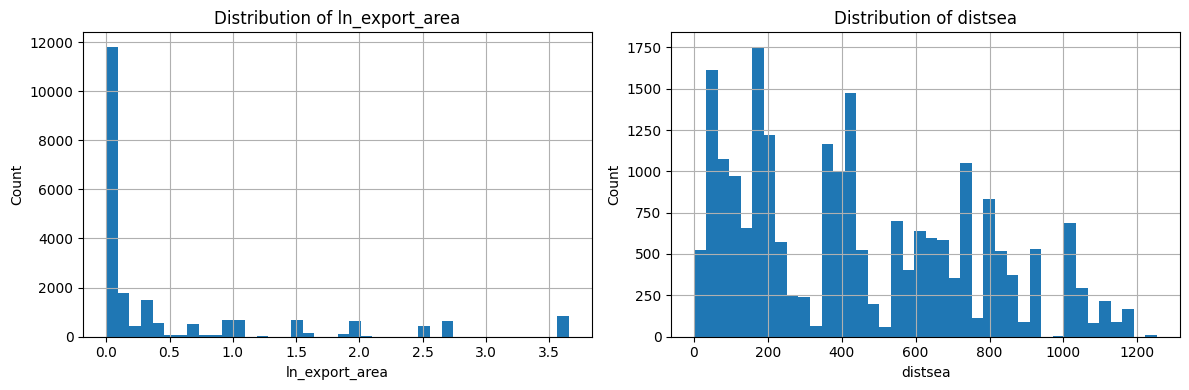

,outcome_label,learner,y_mse,d_mse,z_mse,d_resid_sd,z_resid_sd,DML residualized first-stage F,denominator_cv
26,Intergroup trust,Boosting,0.8442,0.0317,9387.8449,0.1781,96.8938,10.8012,0.0252
29,Intergroup trust,Ensemble,0.8325,0.0353,9730.8141,0.1880,95.7958,18.2569,0.0190
27,Intergroup trust,Forest,0.8235,0.0043,1083.7883,0.0658,32.9218,4.9969,0.0960
24,Intergroup trust,Lasso,0.8577,0.2388,14107.0877,0.4887,118.7767,21.2582,0.0064
28,Intergroup trust,Neural Net,0.8821,0.0210,46845.2071,0.1449,194.3714,7.0690,0.1042
25,Intergroup trust,Tree,0.8826,0.0044,3587.9770,0.0664,59.8991,0.7917,0.6347
20,Intragroup trust,Boosting,0.8252,0.0317,9357.3179,0.1781,96.7361,10.7203,0.0284
23,Intragroup trust,Ensemble,0.8124,0.0351,9663.1789,0.1874,95.6236,18.2151,0.0187
21,Intragroup trust,Forest,0.8041,0.0043,1060.8787,0.0655,32.5718,4.9343,0.0805
18,Intragroup trust,Lasso,0.8444,0.2391,14092.7785,0.4890,118.7165,21.4563,0.0057


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df[treatment].dropna().hist(bins=40, ax=axes[0])
axes[0].set_title("Distribution of ln_export_area")
axes[0].set_xlabel("ln_export_area")
axes[0].set_ylabel("Count")
df[instrument].dropna().hist(bins=40, ax=axes[1])
axes[1].set_title("Distribution of distsea")
axes[1].set_xlabel("distsea")
axes[1].set_ylabel("Count")
plt.tight_layout()
plt.show()

if len(results_long):
    display(
        results_long[
            ["outcome_label", "learner", "y_mse", "d_mse", "z_mse", "d_resid_sd", "z_resid_sd", "first_stage_F", "denominator_cv"]
        ].rename(columns={"first_stage_F": "DML residualized first-stage F"}).sort_values(["outcome_label", "learner"]).round(4)
    )
else:
    print("No DML-IV results loaded yet for nuisance diagnostics.")

This cell plots residualized treatment–instrument relationships and binned first-stage patterns for nuisance-selected specifications.

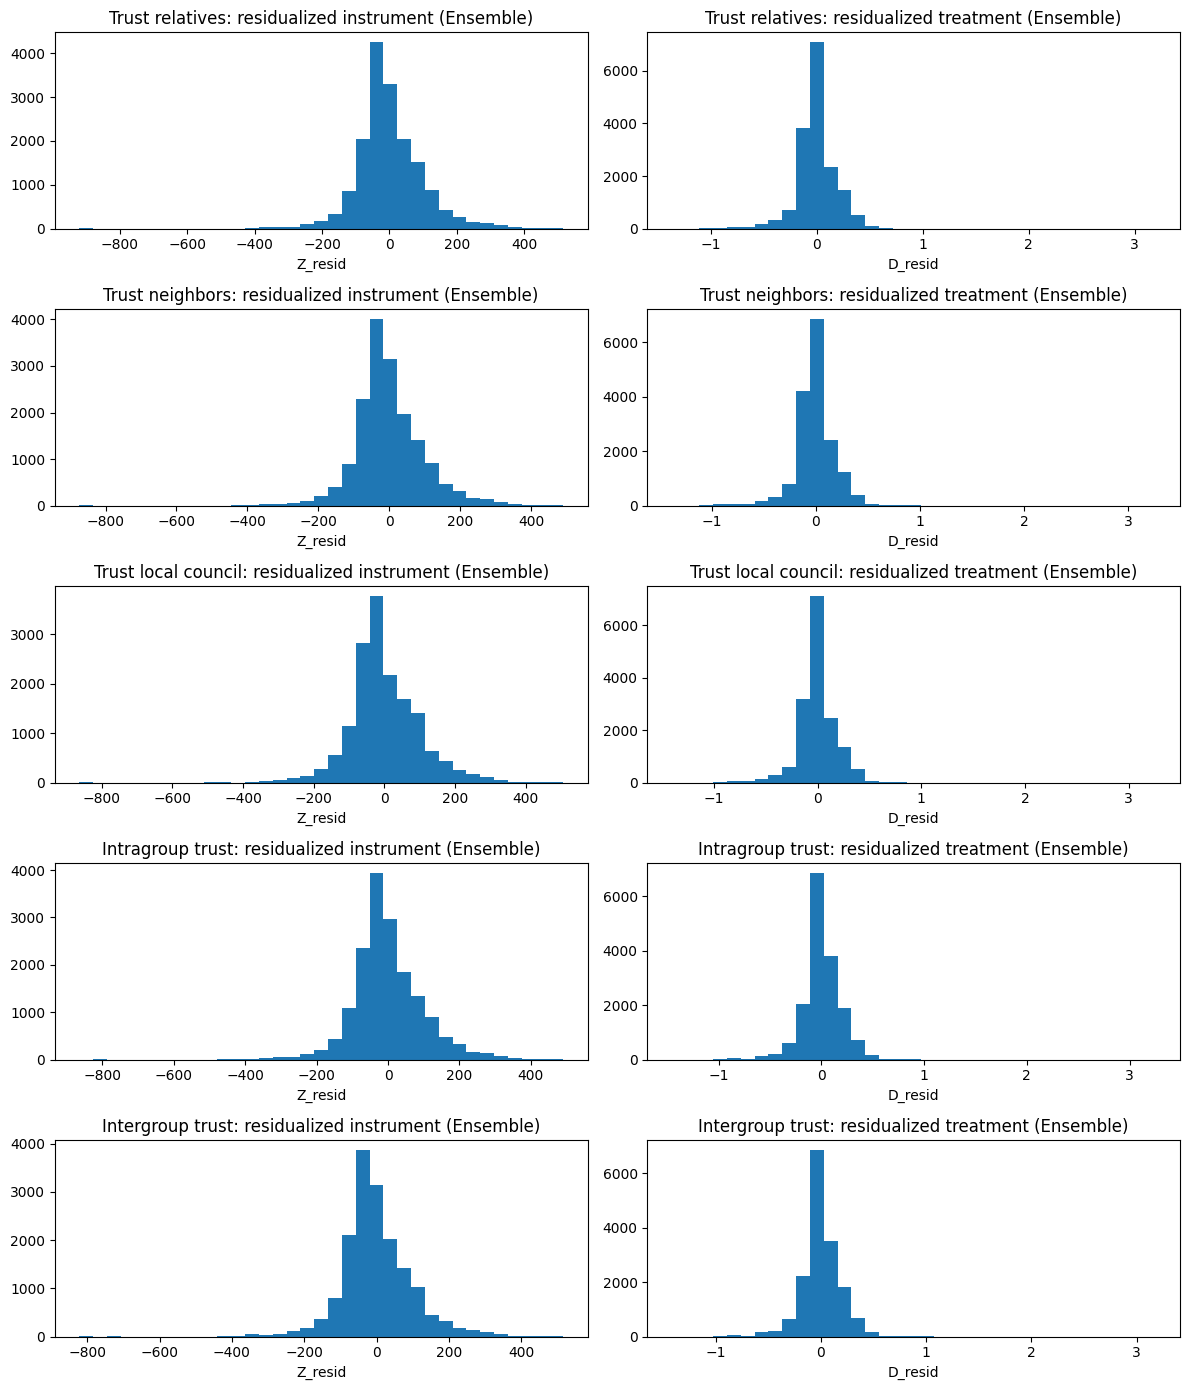

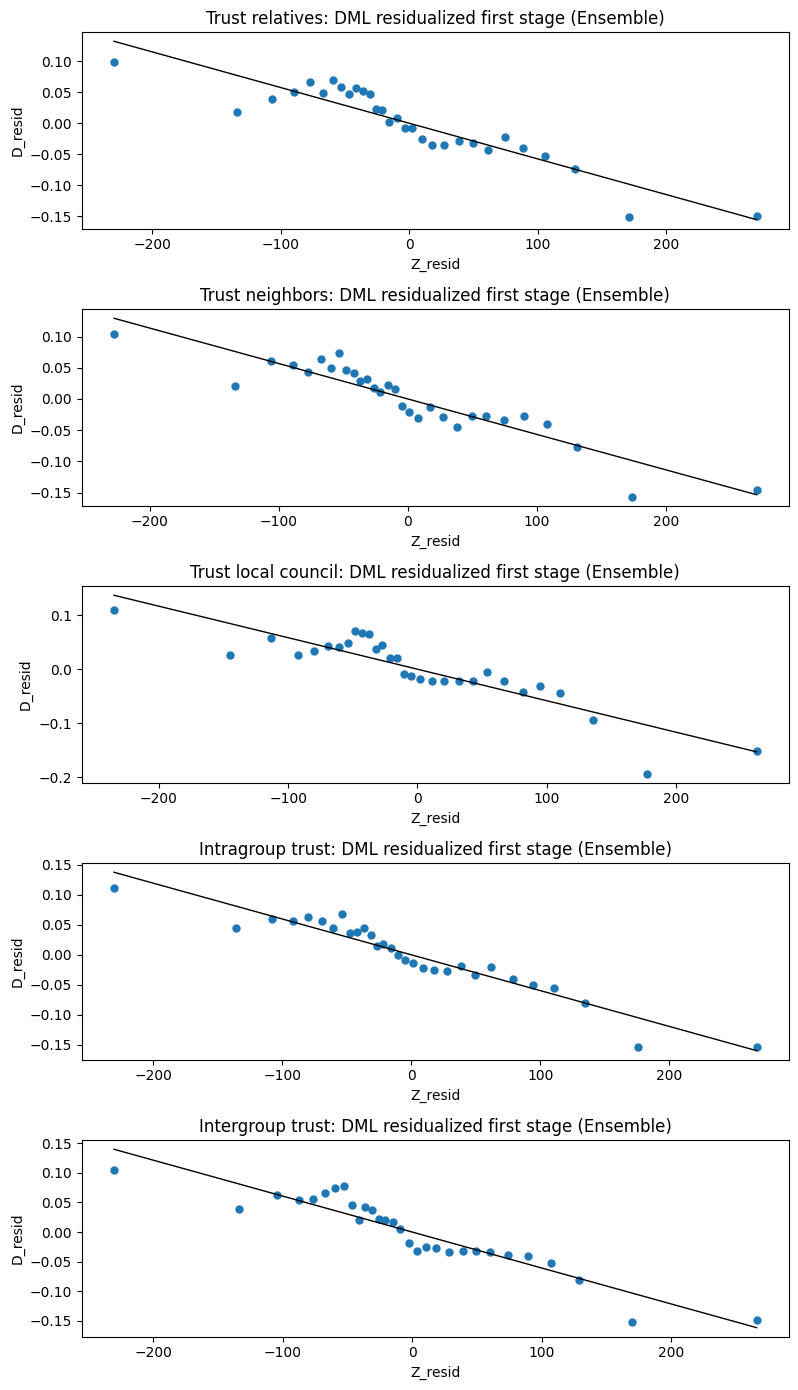

In [20]:
def binned_scatter_data(x, y, bins=30):
    plot_df = pd.DataFrame({"x": x, "y": y}).dropna()
    plot_df["bin"] = pd.qcut(plot_df["x"], q=min(bins, plot_df["x"].nunique()), duplicates="drop")
    return plot_df.groupby("bin", observed=True).agg(x_mean=("x", "mean"), y_mean=("y", "mean")).reset_index(drop=True)


available_iv_outcomes = [outcome for outcome in outcomes if outcome in set(best_by_outcome.get("outcome", []))]

if available_iv_outcomes:
    fig, axes = plt.subplots(len(available_iv_outcomes), 2, figsize=(12, 2.8 * len(available_iv_outcomes)), sharex=False)
    axes = np.atleast_2d(axes)
    for row, outcome in enumerate(available_iv_outcomes):
        best_rows = best_by_outcome.loc[best_by_outcome["outcome"] == outcome, "learner"]
        if best_rows.empty:
            continue
        best_learner = best_rows.iloc[0]
        residuals = all_residuals.get((outcome, best_learner))
        if residuals is None:
            print(f"Skipping residual plots for {outcome}: residuals are not loaded.")
            continue
        axes[row, 0].hist(residuals["z_resid"], bins=35)
        axes[row, 0].set_title(f"{outcome_labels[outcome]}: residualized instrument ({best_learner})")
        axes[row, 0].set_xlabel("Z_resid")
        axes[row, 1].hist(residuals["d_resid"], bins=35)
        axes[row, 1].set_title(f"{outcome_labels[outcome]}: residualized treatment ({best_learner})")
        axes[row, 1].set_xlabel("D_resid")
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(len(available_iv_outcomes), 1, figsize=(8, 2.8 * len(available_iv_outcomes)), sharex=False)
    axes = np.atleast_1d(axes)
    for ax, outcome in zip(axes, available_iv_outcomes):
        best_rows = best_by_outcome.loc[best_by_outcome["outcome"] == outcome, "learner"]
        if best_rows.empty:
            continue
        best_learner = best_rows.iloc[0]
        residuals = all_residuals.get((outcome, best_learner))
        if residuals is None:
            print(f"Skipping first-stage plot for {outcome}: residuals are not loaded.")
            continue
        binned = binned_scatter_data(residuals["z_resid"], residuals["d_resid"])
        ax.scatter(binned["x_mean"], binned["y_mean"], s=25)
        slope = np.sum(residuals["z_resid"] * residuals["d_resid"]) / np.sum(residuals["z_resid"] ** 2)
        x_grid = np.linspace(binned["x_mean"].min(), binned["x_mean"].max(), 100)
        ax.plot(x_grid, slope * x_grid, color="black", linewidth=1)
        ax.set_title(f"{outcome_labels[outcome]}: DML residualized first stage ({best_learner})")
        ax.set_xlabel("Z_resid")
        ax.set_ylabel("D_resid")
    plt.tight_layout()
    plt.show()
else:
    print("Run or load DML-IV results before plotting residual diagnostics.")

This cell plots split-specific DML-IV estimates and reports learner sensitivity by outcome.

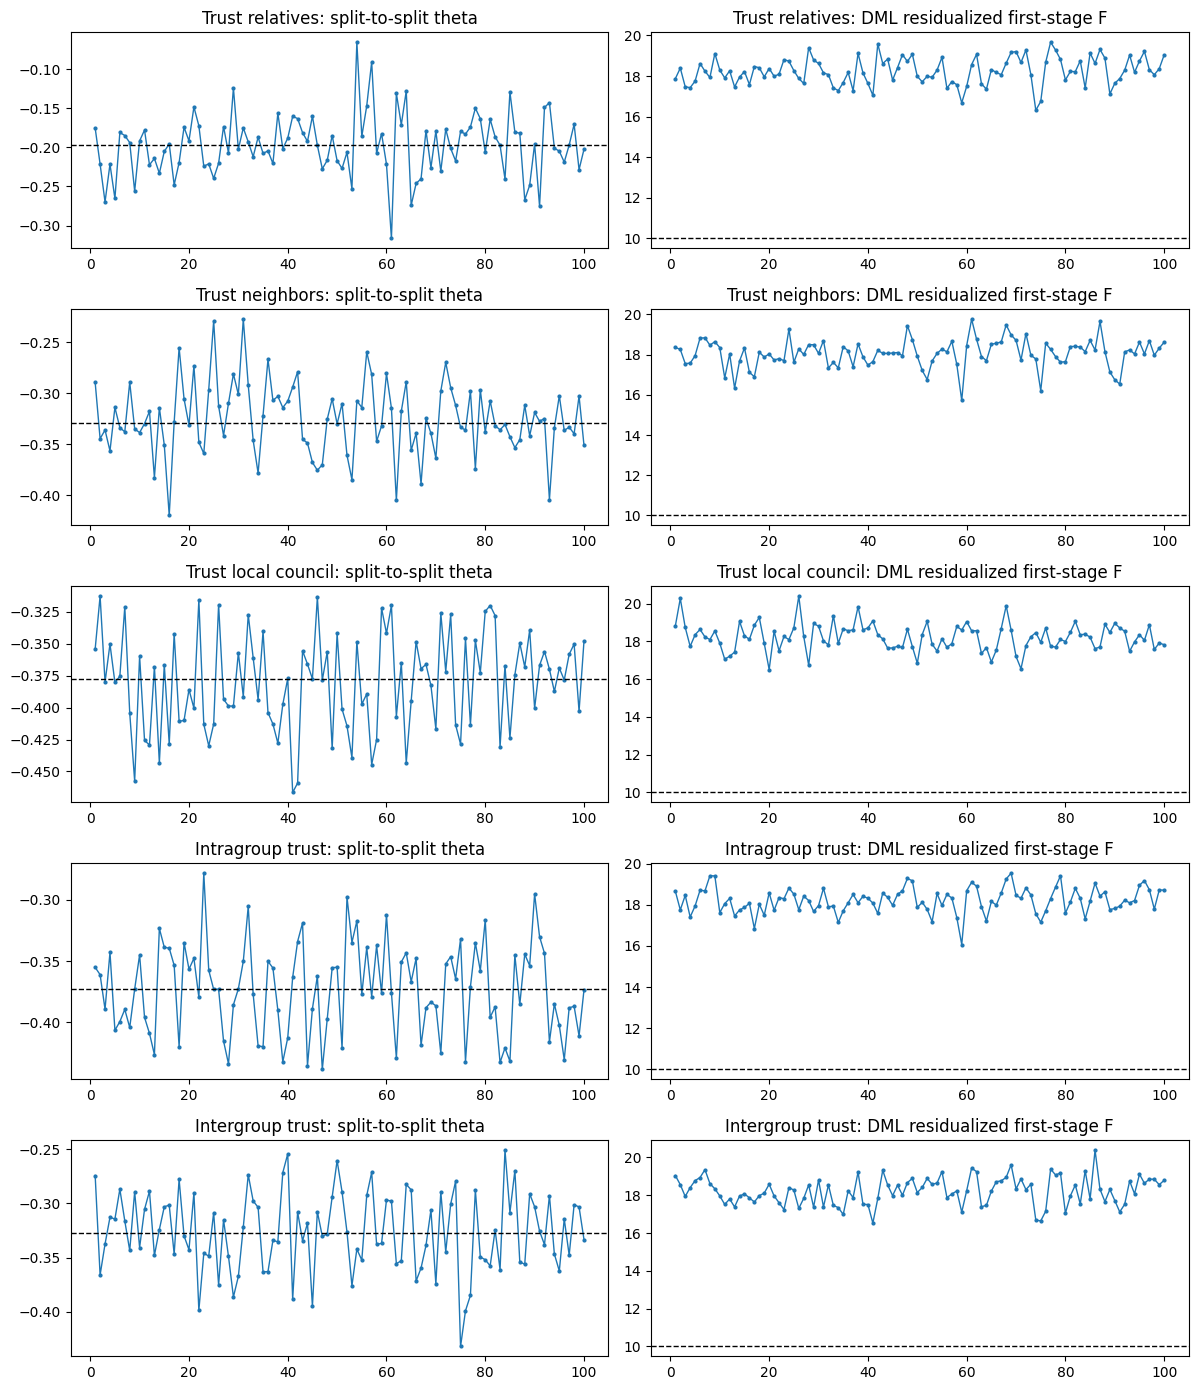

learner,Boosting,Ensemble,Forest,Lasso,Neural Net,Tree
outcome_label,,,,,,
Intergroup trust,-0.413,-0.327,-0.738,-0.187,-0.782,-2.881
Intragroup trust,-0.375,-0.373,-0.705,-0.251,-0.893,-4.904
Trust local council,-0.473,-0.377,-0.948,-0.247,-0.820,-2.017
Trust neighbors,-0.273,-0.329,-0.324,-0.267,-0.723,-2.837
Trust relatives,-0.194,-0.197,-0.031,-0.175,-0.721,-6.255


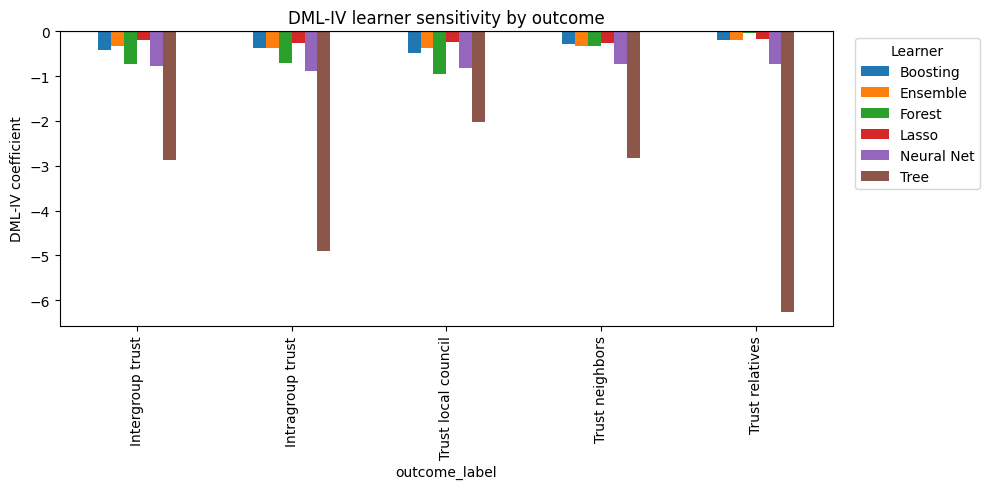

In [21]:
if available_iv_outcomes:
    fig, axes = plt.subplots(len(available_iv_outcomes), 2, figsize=(12, 2.8 * len(available_iv_outcomes)), sharex=False)
    axes = np.atleast_2d(axes)
    for row, outcome in enumerate(available_iv_outcomes):
        best_rows = best_by_outcome.loc[best_by_outcome["outcome"] == outcome, "learner"]
        if best_rows.empty:
            continue
        best_learner = best_rows.iloc[0]
        split_table = all_split_tables.get((outcome, best_learner))
        if split_table is None:
            print(f"Skipping split diagnostics for {outcome}: split table is not loaded.")
            continue
        axes[row, 0].plot(split_table["split"], split_table["theta"], marker="o", linewidth=1, markersize=2)
        axes[row, 0].axhline(split_table["theta"].median(), color="black", linestyle="--", linewidth=1)
        axes[row, 0].set_title(f"{outcome_labels[outcome]}: split-to-split theta")
        axes[row, 1].plot(split_table["split"], split_table["first_stage_F"], marker="o", linewidth=1, markersize=2)
        axes[row, 1].axhline(10, color="black", linestyle="--", linewidth=1)
        axes[row, 1].set_title(f"{outcome_labels[outcome]}: DML residualized first-stage F")
    plt.tight_layout()
    plt.show()

    learner_sensitivity = results_long.pivot_table(index="outcome_label", columns="learner", values="theta", aggfunc="first")
    display(learner_sensitivity.round(3))
    ax = learner_sensitivity.plot(kind="bar", figsize=(10, 5))
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title("DML-IV learner sensitivity by outcome")
    ax.set_ylabel("DML-IV coefficient")
    ax.legend(title="Learner", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
else:
    print("Run or load DML-IV results before plotting split and learner sensitivity diagnostics.")

## 13. Interpretation

The residualized first stage measures instrument relevance after flexible control adjustment; it is distinct from the published linear first stage. DML-IV still requires a valid exclusion restriction for `distsea`, and flexible nuisance estimation cannot establish that assumption. Estimates with weak residualized first stages or unstable denominators require particular caution.

This function produces a concise interpretation of signs, magnitudes, uncertainty, and residualized first-stage strength for the formatted Table 6 results.

In [22]:
def automatic_iv_interpretation(table):
    if table.empty:
        return "Run or load DML-IV results before generating the interpretation."
    lines = []
    for _, row in table.iterrows():
        outcome = row["Outcome"]
        original = row["Original Table 6 IV coefficient"]
        dml = row["DML-IV Best estimate"]
        learner = row["DML-IV Best learner"]
        first_stage_f = row["DML residualized first-stage F"]
        if np.sign(original) == np.sign(dml) and 0.75 * abs(original) <= abs(dml) <= 1.25 * abs(original):
            verdict = "similar in sign and magnitude to the original IV benchmark"
        elif np.sign(original) == np.sign(dml) and abs(dml) < 0.75 * abs(original):
            verdict = "same sign as the original IV benchmark but smaller in magnitude"
        elif np.sign(original) == np.sign(dml) and abs(dml) > 1.25 * abs(original):
            verdict = "same sign as the original IV benchmark and larger in magnitude"
        else:
            verdict = "different in sign from the original IV benchmark"
        strength = "strong" if first_stage_f >= 10 else "weak"
        lines.append(
            f"{outcome}: best learner = {learner}; original IV = {original:.3f}; DML-IV = {dml:.3f}; "
            f"DML residualized first-stage F = {first_stage_f:.2f} ({strength}); {verdict}."
        )
    lines.append("DML-IV addresses flexible observed-control adjustment, but identification still depends on the exclusion restriction for distsea.")
    return "\n".join(lines)


print(automatic_iv_interpretation(table6_dml_iv))

Intergroup trust: best learner = Ensemble; original IV = -0.189; DML-IV = -0.327; DML residualized first-stage F = 18.26 (strong); same sign as the original IV benchmark and larger in magnitude.
Intragroup trust: best learner = Ensemble; original IV = -0.254; DML-IV = -0.373; DML residualized first-stage F = 18.22 (strong); same sign as the original IV benchmark and larger in magnitude.
Trust local council: best learner = Ensemble; original IV = -0.262; DML-IV = -0.377; DML residualized first-stage F = 18.26 (strong); same sign as the original IV benchmark and larger in magnitude.
Trust neighbors: best learner = Ensemble; original IV = -0.271; DML-IV = -0.329; DML residualized first-stage F = 18.09 (strong); similar in sign and magnitude to the original IV benchmark.
Trust relatives: best learner = Ensemble; original IV = -0.172; DML-IV = -0.197; DML residualized first-stage F = 18.23 (strong); similar in sign and magnitude to the original IV benchmark.
DML-IV addresses flexible observ

## 14. Ethnicity-cluster cross-fitting

Random individual folds can share `murdock_name` groups across training and held-out samples. Holding out entire ethnicities creates a stricter prediction exercise for the outcome, endogenous treatment, and instrument while preserving the DML-IV moment and clustered inference.

This helper assigns whole ethnicity groups to folds so held-out `murdock_name` groups do not appear in nuisance-model training data.

In [23]:
def iter_cluster_kfold_indices(clusters, n_folds=2, random_state=1211):
    clusters = pd.Series(clusters).astype(str).reset_index(drop=True)
    unique_clusters = clusters.unique()
    if n_folds < 2:
        raise ValueError("n_folds must be at least 2.")
    if n_folds > len(unique_clusters):
        raise ValueError(f"n_folds={n_folds} exceeds unique clusters={len(unique_clusters)}.")
    rng = np.random.default_rng(random_state)
    shuffled_clusters = rng.permutation(unique_clusters)
    cluster_folds = np.array_split(shuffled_clusters, n_folds)

    for held_out_clusters in cluster_folds:
        held_out = set(held_out_clusters)
        test_mask = clusters.isin(held_out).to_numpy()
        train_idx = np.flatnonzero(~test_mask)
        test_idx = np.flatnonzero(test_mask)
        assert set(clusters.iloc[train_idx]).isdisjoint(set(clusters.iloc[test_idx]))
        assert len(train_idx) > 0 and len(test_idx) > 0
        yield train_idx, test_idx

This estimator applies repeated DML-IV with ethnicity-cluster folds and returns the same score, first-stage, denominator, and prediction diagnostics as the main estimator.

In [24]:
def dml_pliv_repeated_cluster_crossfit(
    Y,
    D,
    Z,
    X,
    clusters,
    learner_name,
    split_cluster="murdock_name",
    n_splits=100,
    n_folds=2,
    random_seed=1211,
):
    '''Repeated DML-IV with cross-fitting folds held out by cluster.'''
    Y = np.asarray(Y, dtype=float)
    D = np.asarray(D, dtype=float)
    Z = np.asarray(Z, dtype=float)
    X = X.copy()
    factories = make_learner_factories()
    split_results = []
    residual_store = {}

    for split in range(n_splits):
        split_seed = random_seed + split
        y_hat = np.zeros_like(Y, dtype=float)
        d_hat = np.zeros_like(D, dtype=float)
        z_hat = np.zeros_like(Z, dtype=float)

        for fold, (train_idx, test_idx) in enumerate(
            iter_cluster_kfold_indices(clusters[split_cluster], n_folds=n_folds, random_state=split_seed),
            start=1,
        ):
            learner_y = factories[learner_name](split_seed + fold)
            learner_d = factories[learner_name](split_seed + 10_000 + fold)
            learner_z = factories[learner_name](split_seed + 20_000 + fold)
            X_train = X.iloc[train_idx]
            X_test = X.iloc[test_idx]

            learner_y.fit(X_train, Y[train_idx])
            y_hat[test_idx] = learner_y.predict(X_test)
            learner_d.fit(X_train, D[train_idx])
            d_hat[test_idx] = learner_d.predict(X_test)
            learner_z.fit(X_train, Z[train_idx])
            z_hat[test_idx] = learner_z.predict(X_test)

            del learner_y, learner_d, learner_z
            cp.get_default_memory_pool().free_all_blocks()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        y_resid, d_resid, z_resid = center_residuals(Y - y_hat, D - d_hat, Z - z_hat)
        final = two_way_cluster_se_iv(y_resid, d_resid, z_resid, clusters)
        first_stage = two_way_cluster_first_stage(d_resid, z_resid, clusters)

        split_results.append(
            {
                "split": split + 1,
                "theta": final["theta"],
                "se": final["se"],
                "t": final["t"],
                "p": final["p"],
                "y_mse": mse(Y, y_hat),
                "d_mse": mse(D, d_hat),
                "z_mse": mse(Z, z_hat),
                "d_resid_sd": first_stage["d_resid_sd"],
                "z_resid_sd": first_stage["z_resid_sd"],
                "denominator": first_stage["denominator"],
                "first_stage_coef": first_stage["first_stage_coef"],
                "first_stage_se": first_stage["first_stage_se"],
                "first_stage_t": first_stage["first_stage_t"],
                "first_stage_F": first_stage["first_stage_F"],
                "raw_variance": final["raw_variance"],
            }
        )
        residual_store[split + 1] = {
            "y_hat": y_hat,
            "d_hat": d_hat,
            "z_hat": z_hat,
            "y_resid": y_resid,
            "d_resid": d_resid,
            "z_resid": z_resid,
        }

    split_table = pd.DataFrame(split_results)
    median_theta = split_table["theta"].median()
    median_split = int((split_table["theta"] - median_theta).abs().idxmin()) + 1
    within_var = np.nanmedian(split_table["se"] ** 2)
    between_var = np.nanvar(split_table["theta"], ddof=1) if n_splits > 1 else 0.0
    split_adjusted_se = float(np.sqrt(within_var + between_var))
    dof = max(min(clusters["murdock_name"].nunique(), clusters["district"].nunique()) - 1, 1)
    t_stat = median_theta / split_adjusted_se if split_adjusted_se > 0 else np.nan
    p_value = 2 * stats.t.sf(np.abs(t_stat), df=dof) if split_adjusted_se > 0 else np.nan
    denominator_abs_median = float(np.nanmedian(np.abs(split_table["denominator"])))
    denominator_cv = float(split_table["denominator"].std(ddof=1) / denominator_abs_median) if n_splits > 1 and denominator_abs_median > 0 else 0.0

    summary = {
        "learner": learner_name,
        "n_splits": n_splits,
        "n_folds": n_folds,
        "split_cluster": split_cluster,
        "theta": median_theta,
        "se": split_adjusted_se,
        "t": t_stat,
        "p": p_value,
        "median_split": median_split,
        "median_split_se": split_table.loc[split_table["split"] == median_split, "se"].iloc[0],
        "split_sd": float(split_table["theta"].std(ddof=1)) if n_splits > 1 else 0.0,
        "y_mse": float(split_table["y_mse"].median()),
        "d_mse": float(split_table["d_mse"].median()),
        "z_mse": float(split_table["z_mse"].median()),
        "d_resid_sd": float(split_table["d_resid_sd"].median()),
        "z_resid_sd": float(split_table["z_resid_sd"].median()),
        "denominator": float(split_table["denominator"].median()),
        "denominator_abs_median": denominator_abs_median,
        "denominator_cv": denominator_cv,
        "first_stage_coef": float(split_table["first_stage_coef"].median()),
        "first_stage_se": float(split_table["first_stage_se"].median()),
        "first_stage_t": float(split_table["first_stage_t"].median()),
        "first_stage_F": float(split_table["first_stage_F"].median()),
    }
    return {"summary": summary, "splits": split_table, "residuals": residual_store[median_split]}

This cell defines cluster-fold settings, versioned checkpoints, result stores, and the cluster DML-IV outcome controller.

In [25]:
CLUSTER_IV_N_SPLITS = 100
CLUSTER_IV_N_FOLDS = 2
CLUSTER_IV_RANDOM_SEED = 1211
CLUSTER_IV_SPLIT_VARIABLE = "murdock_name"
CLUSTER_IV_CHECKPOINT_VERSION = LEARNER_VERSION + "_cluster_murdock"

CLUSTER_IV_CHECKPOINT_DIR = PROJECT_ROOT / "dml_table6_iv_checkpoints_cluster_murdock"
CLUSTER_IV_CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

cluster_iv_summaries = []
cluster_iv_split_tables = {}
cluster_iv_residuals = {}
cluster_iv_results_long = pd.DataFrame()


def cluster_iv_checkpoint_path(outcome):
    return CLUSTER_IV_CHECKPOINT_DIR / f"dml_table6_iv_cluster_{outcome}.pkl"


def refresh_cluster_iv_results_long():
    global cluster_iv_results_long
    cluster_iv_results_long = pd.DataFrame(cluster_iv_summaries)
    return cluster_iv_results_long


def remove_cluster_iv_outcome_from_memory(outcome):
    global cluster_iv_summaries, cluster_iv_split_tables, cluster_iv_residuals
    cluster_iv_summaries = [row for row in cluster_iv_summaries if row["outcome"] != outcome]
    for key in list(cluster_iv_split_tables.keys()):
        if key[0] == outcome:
            del cluster_iv_split_tables[key]
    for key in list(cluster_iv_residuals.keys()):
        if key[0] == outcome:
            del cluster_iv_residuals[key]


def save_cluster_iv_outcome_checkpoint(outcome):
    path = cluster_iv_checkpoint_path(outcome)
    payload = {
        "outcome": outcome,
        "checkpoint_version": CLUSTER_IV_CHECKPOINT_VERSION,
        "split_cluster": CLUSTER_IV_SPLIT_VARIABLE,
        "n_splits": CLUSTER_IV_N_SPLITS,
        "n_folds": CLUSTER_IV_N_FOLDS,
        "random_seed": CLUSTER_IV_RANDOM_SEED,
        "summaries": [row for row in cluster_iv_summaries if row["outcome"] == outcome],
        "split_tables": {key: value for key, value in cluster_iv_split_tables.items() if key[0] == outcome},
        "residuals": {key: value for key, value in cluster_iv_residuals.items() if key[0] == outcome},
    }
    with open(path, "wb") as f:
        pickle.dump(payload, f)
    print(f"Saved cluster IV checkpoint: {path}")


def load_cluster_iv_outcome_checkpoint(outcome):
    path = cluster_iv_checkpoint_path(outcome)
    if not path.exists():
        return False
    with open(path, "rb") as f:
        payload = pickle.load(f)
    if payload.get("checkpoint_version") != CLUSTER_IV_CHECKPOINT_VERSION:
        print(f"Found outdated cluster IV checkpoint for {outcome}; recomputing.")
        return False
    remove_cluster_iv_outcome_from_memory(outcome)
    cluster_iv_summaries.extend(payload["summaries"])
    cluster_iv_split_tables.update(payload["split_tables"])
    cluster_iv_residuals.update(payload["residuals"])
    refresh_cluster_iv_results_long()
    print(f"Loaded cluster IV checkpoint: {path}")
    return True


def run_cluster_dml_iv_for_outcome(outcome, split_cluster=CLUSTER_IV_SPLIT_VARIABLE, force=False):
    global cluster_iv_summaries, cluster_iv_split_tables, cluster_iv_residuals, cluster_iv_results_long
    if split_cluster != CLUSTER_IV_SPLIT_VARIABLE:
        raise ValueError(f"This checkpoint setup is configured for {CLUSTER_IV_SPLIT_VARIABLE!r}; got {split_cluster!r}.")
    if not force and load_cluster_iv_outcome_checkpoint(outcome):
        return cluster_iv_results_long.loc[cluster_iv_results_long["outcome"] == outcome].sort_values("learner")

    remove_cluster_iv_outcome_from_memory(outcome)
    prepared = prepare_table6_iv_sample(df, outcome)
    print(
        f"\nCluster DML-IV outcome: {outcome} | N={prepared['n']:,} | "
        f"X columns={prepared['X'].shape[1]:,} | split cluster={split_cluster}"
    )
    for learner_name in make_learners().keys():
        print(f"  Running {learner_name} with {split_cluster}-cluster folds...")
        result = dml_pliv_repeated_cluster_crossfit(
            Y=prepared["Y"],
            D=prepared["D"],
            Z=prepared["Z"],
            X=prepared["X"],
            clusters=prepared["clusters"],
            learner_name=learner_name,
            split_cluster=split_cluster,
            n_splits=CLUSTER_IV_N_SPLITS,
            n_folds=CLUSTER_IV_N_FOLDS,
            random_seed=CLUSTER_IV_RANDOM_SEED,
        )
        summary = {
            "outcome": outcome,
            "outcome_label": outcome_labels[outcome],
            "crossfit_design": "ethnicity_cluster",
            "learner": learner_name,
            "N": prepared["n"],
            "ethnicity_clusters": prepared["n_ethnicity_clusters"],
            "district_clusters": prepared["n_district_clusters"],
            "original_iv": original_iv[outcome],
            "original_iv_se": original_iv_se[outcome],
            "original_stata_first_stage_F": original_first_stage_f[outcome],
            **result["summary"],
        }
        summary["weak_first_stage_flag"] = summary["first_stage_F"] < 10
        summary["unstable_denominator_flag"] = summary["denominator_cv"] > 0.25
        cluster_iv_summaries.append(summary)
        cluster_iv_split_tables[(outcome, learner_name)] = result["splits"]
        cluster_iv_residuals[(outcome, learner_name)] = result["residuals"]
    refresh_cluster_iv_results_long()
    save_cluster_iv_outcome_checkpoint(outcome)
    return cluster_iv_results_long.loc[cluster_iv_results_long["outcome"] == outcome].sort_values("learner")

### Outcome-specific cluster-fold estimates

This cell runs or loads the cluster-fold DML-IV specification for trust in relatives.

In [26]:
run_cluster_dml_iv_for_outcome("trust_relatives")

,outcome,outcome_label,crossfit_design,learner,N,ethnicity_clusters,district_clusters,original_iv,original_iv_se,original_stata_first_stage_F,n_splits,n_folds,split_cluster,theta,se,t,p,median_split,median_split_se,split_sd,y_mse,d_mse,z_mse,d_resid_sd,z_resid_sd,denominator,denominator_abs_median,denominator_cv,first_stage_coef,first_stage_se,first_stage_t,first_stage_F,weak_first_stage_flag,unstable_denominator_flag
2,trust_relatives,Trust relatives,ethnicity_cluster,Boosting,16709,147,1187,-0.172,0.076,21.7,100,2,murdock_name,0.018172,0.195700,0.092855,0.926146,51,0.122734,0.134075,0.841884,0.940387,51369.691574,0.927341,223.798260,-1.179040e+06,1.179040e+06,0.352934,-0.001401,0.000685,-2.221082,4.933407,True,True
5,trust_relatives,Trust relatives,ethnicity_cluster,Ensemble,16709,147,1187,-0.172,0.076,21.7,100,2,murdock_name,-0.077113,0.127810,-0.603341,0.547218,98,0.079707,0.085718,0.843191,0.900489,44492.938763,0.917684,209.052957,-1.315227e+06,1.315227e+06,0.332892,-0.001799,0.000708,-2.590533,6.710884,True,True
3,trust_relatives,Trust relatives,ethnicity_cluster,Forest,16709,147,1187,-0.172,0.076,21.7,100,2,murdock_name,-0.001750,0.137089,-0.012765,0.989833,25,0.107060,0.071188,0.830063,0.847852,49261.059039,0.872747,217.119426,-1.300248e+06,1.300248e+06,0.265744,-0.001656,0.000630,-2.631449,6.924909,True,True
0,trust_relatives,Trust relatives,ethnicity_cluster,Lasso,16709,147,1187,-0.172,0.076,21.7,100,2,murdock_name,-0.149387,0.147509,-1.012732,0.312863,27,0.089488,0.126676,0.895912,1.272655,60918.359752,1.105769,244.897984,-1.968951e+06,1.968951e+06,1.255095,-0.002034,0.000613,-3.215312,10.339070,False,True
4,trust_relatives,Trust relatives,ethnicity_cluster,Neural Net,16709,147,1187,-0.172,0.076,21.7,100,2,murdock_name,-0.167863,0.360188,-0.466042,0.641880,55,0.120750,0.302604,0.999590,1.045733,90429.173289,0.994339,266.791363,-1.075534e+06,1.075534e+06,0.457338,-0.000937,0.000460,-1.983884,3.936036,True,True
1,trust_relatives,Trust relatives,ethnicity_cluster,Tree,16709,147,1187,-0.172,0.076,21.7,100,2,murdock_name,0.005796,0.772435,0.007504,0.994023,81,0.157344,0.743740,0.939433,1.256893,97005.594740,1.065842,306.708683,-1.244616e+06,1.244616e+06,0.607152,-0.000766,0.000478,-1.520560,2.312187,True,True


This cell runs or loads the cluster-fold DML-IV specification for trust in neighbors.

In [27]:
run_cluster_dml_iv_for_outcome("trust_neighbors")

,outcome,outcome_label,crossfit_design,learner,N,ethnicity_clusters,district_clusters,original_iv,original_iv_se,original_stata_first_stage_F,n_splits,n_folds,split_cluster,theta,se,t,p,median_split,median_split_se,split_sd,y_mse,d_mse,z_mse,d_resid_sd,z_resid_sd,denominator,denominator_abs_median,denominator_cv,first_stage_coef,first_stage_se,first_stage_t,first_stage_F,weak_first_stage_flag,unstable_denominator_flag
8,trust_neighbors,Trust neighbors,ethnicity_cluster,Boosting,16679,147,1187,-0.271,0.088,21.6,100,2,murdock_name,-0.044087,0.162900,-0.270639,0.787051,8,0.056314,0.115185,0.890810,0.949909,51098.848790,0.932424,223.102562,-1.199827e+06,1.199827e+06,0.355684,-0.001400,0.000679,-2.212834,4.896689,True,True
11,trust_neighbors,Trust neighbors,ethnicity_cluster,Ensemble,16679,147,1187,-0.271,0.088,21.6,100,2,murdock_name,-0.148167,0.117566,-1.260286,0.209577,14,0.103588,0.084747,0.899260,0.898297,44568.437810,0.919264,210.307216,-1.273377e+06,1.273377e+06,0.347517,-0.001808,0.000710,-2.608019,6.801863,True,True
9,trust_neighbors,Trust neighbors,ethnicity_cluster,Forest,16679,147,1187,-0.271,0.088,21.6,100,2,murdock_name,-0.073209,0.123485,-0.592854,0.554196,80,0.111690,0.073368,0.887478,0.843090,49010.925257,0.870972,217.074428,-1.308270e+06,1.308270e+06,0.262134,-0.001667,0.000628,-2.627656,6.904584,True,True
6,trust_neighbors,Trust neighbors,ethnicity_cluster,Lasso,16679,147,1187,-0.271,0.088,21.6,100,2,murdock_name,-0.250793,0.164946,-1.520455,0.130559,79,0.053697,0.143149,0.968421,1.272189,61139.766864,1.107859,244.498981,-2.041458e+06,2.041458e+06,1.229659,-0.002032,0.000614,-3.141072,9.866572,True,True
10,trust_neighbors,Trust neighbors,ethnicity_cluster,Neural Net,16679,147,1187,-0.271,0.088,21.6,100,2,murdock_name,-0.230526,0.355393,-0.648652,0.517583,69,0.080086,0.291616,1.031655,1.030940,90460.918693,0.989628,267.231728,-1.054800e+06,1.054800e+06,0.481502,-0.000901,0.000470,-1.977612,3.911009,True,True
7,trust_neighbors,Trust neighbors,ethnicity_cluster,Tree,16679,147,1187,-0.271,0.088,21.6,100,2,murdock_name,-0.017060,1.186648,-0.014377,0.988549,30,0.158710,1.165363,1.026865,1.258831,98770.125492,1.072498,310.242391,-1.197072e+06,1.197072e+06,0.645585,-0.000757,0.000490,-1.451263,2.106338,True,True


This cell runs or loads the cluster-fold DML-IV specification for trust in the local council.

In [28]:
run_cluster_dml_iv_for_outcome("trust_local_council")

,outcome,outcome_label,crossfit_design,learner,N,ethnicity_clusters,district_clusters,original_iv,original_iv_se,original_stata_first_stage_F,n_splits,n_folds,split_cluster,theta,se,t,p,median_split,median_split_se,split_sd,y_mse,d_mse,z_mse,d_resid_sd,z_resid_sd,denominator,denominator_abs_median,denominator_cv,first_stage_coef,first_stage_se,first_stage_t,first_stage_F,weak_first_stage_flag,unstable_denominator_flag
14,trust_local_council,Trust local council,ethnicity_cluster,Boosting,15905,146,1194,-0.262,0.075,22.2,100,2,murdock_name,-0.132813,0.147189,-0.902332,0.368377,60,0.101092,0.109458,1.019213,0.948925,52948.627515,0.923879,227.216449,-1.140871e+06,1.140871e+06,0.355981,-0.001417,0.000654,-2.271710,5.160713,True,True
17,trust_local_council,Trust local council,ethnicity_cluster,Ensemble,15905,146,1194,-0.262,0.075,22.2,100,2,murdock_name,-0.136257,0.120283,-1.132799,0.259168,77,0.070070,0.087924,1.009160,0.904976,47382.610849,0.920586,215.436518,-1.318892e+06,1.318892e+06,0.302494,-0.001774,0.000641,-2.844846,8.093690,True,True
15,trust_local_council,Trust local council,ethnicity_cluster,Forest,15905,146,1194,-0.262,0.075,22.2,100,2,murdock_name,-0.114489,0.114861,-0.996760,0.320542,5,0.093869,0.072244,1.030251,0.834558,48797.925432,0.867795,217.700606,-1.299295e+06,1.299295e+06,0.226760,-0.001641,0.000611,-2.681715,7.191595,True,False
12,trust_local_council,Trust local council,ethnicity_cluster,Lasso,15905,146,1194,-0.262,0.075,22.2,100,2,murdock_name,-0.137043,0.157200,-0.871773,0.384773,31,0.082629,0.133448,1.038788,1.243335,69328.581835,1.106499,262.767999,-2.124587e+06,2.124587e+06,0.747800,-0.001956,0.000517,-3.279599,10.755771,False,True
16,trust_local_council,Trust local council,ethnicity_cluster,Neural Net,15905,146,1194,-0.262,0.075,22.2,100,2,murdock_name,-0.189667,0.243846,-0.777815,0.437946,46,0.131768,0.197066,1.136726,1.057360,97059.028540,1.001567,273.730145,-1.191927e+06,1.191927e+06,0.397757,-0.001031,0.000456,-2.191794,4.804025,True,True
13,trust_local_council,Trust local council,ethnicity_cluster,Tree,15905,146,1194,-0.262,0.075,22.2,100,2,murdock_name,-0.171146,1.039202,-0.164690,0.869417,47,0.122989,1.015952,1.127725,1.243868,99598.397408,1.061163,313.103167,-1.052983e+06,1.052983e+06,0.739723,-0.000667,0.000450,-1.468764,2.157279,True,True


This cell runs or loads the cluster-fold DML-IV specification for intragroup trust.

In [29]:
run_cluster_dml_iv_for_outcome("intra_group_trust")

,outcome,outcome_label,crossfit_design,learner,N,ethnicity_clusters,district_clusters,original_iv,original_iv_se,original_stata_first_stage_F,n_splits,n_folds,split_cluster,theta,se,t,p,median_split,median_split_se,split_sd,y_mse,d_mse,z_mse,d_resid_sd,z_resid_sd,denominator,denominator_abs_median,denominator_cv,first_stage_coef,first_stage_se,first_stage_t,first_stage_F,weak_first_stage_flag,unstable_denominator_flag
20,intra_group_trust,Intragroup trust,ethnicity_cluster,Boosting,16636,147,1186,-0.254,0.109,21.8,100,2,murdock_name,-0.085326,0.152207,-0.560589,0.575937,73,0.065864,0.114503,0.888402,0.952894,51625.114290,0.928414,224.051255,-1.202597e+06,1.202597e+06,0.342125,-0.001415,0.000683,-2.214375,4.903504,True,True
23,intra_group_trust,Intragroup trust,ethnicity_cluster,Ensemble,16636,147,1186,-0.254,0.109,21.8,100,2,murdock_name,-0.149466,0.113128,-1.321207,0.188499,43,0.064427,0.080874,0.888445,0.900089,44388.843448,0.918328,209.391529,-1.293952e+06,1.293952e+06,0.333850,-0.001796,0.000707,-2.592131,6.719219,True,True
21,intra_group_trust,Intragroup trust,ethnicity_cluster,Forest,16636,147,1186,-0.254,0.109,21.8,100,2,murdock_name,-0.065921,0.119620,-0.551087,0.582416,56,0.092484,0.079215,0.885450,0.840645,48628.968098,0.871917,216.443379,-1.283383e+06,1.283383e+06,0.268260,-0.001666,0.000632,-2.633844,6.937315,True,True
18,intra_group_trust,Intragroup trust,ethnicity_cluster,Lasso,16636,147,1186,-0.254,0.109,21.8,100,2,murdock_name,-0.228909,0.146489,-1.562643,0.120302,42,0.111865,0.125153,0.952365,1.275450,60671.032199,1.108128,244.238874,-2.001194e+06,2.001194e+06,1.235411,-0.002044,0.000616,-3.233013,10.453643,False,True
22,intra_group_trust,Intragroup trust,ethnicity_cluster,Neural Net,16636,147,1186,-0.254,0.109,21.8,100,2,murdock_name,-0.194769,0.697588,-0.279204,0.780484,36,0.260047,0.674212,1.010993,1.040717,92165.825501,0.992563,264.739664,-1.060980e+06,1.060980e+06,0.460850,-0.000933,0.000449,-1.989908,3.959743,True,True
19,intra_group_trust,Intragroup trust,ethnicity_cluster,Tree,16636,147,1186,-0.254,0.109,21.8,100,2,murdock_name,-0.040098,2.452370,-0.016351,0.986977,2,0.102225,2.442189,1.022571,1.264147,98599.951687,1.071856,308.302334,-1.281275e+06,1.281275e+06,0.612409,-0.000773,0.000493,-1.483858,2.202344,True,True


This cell runs or loads the cluster-fold DML-IV specification for intergroup trust.

In [30]:
run_cluster_dml_iv_for_outcome("inter_group_trust")

,outcome,outcome_label,crossfit_design,learner,N,ethnicity_clusters,district_clusters,original_iv,original_iv_se,original_stata_first_stage_F,n_splits,n_folds,split_cluster,theta,se,t,p,median_split,median_split_se,split_sd,y_mse,d_mse,z_mse,d_resid_sd,z_resid_sd,denominator,denominator_abs_median,denominator_cv,first_stage_coef,first_stage_se,first_stage_t,first_stage_F,weak_first_stage_flag,unstable_denominator_flag
26,inter_group_trust,Intergroup trust,ethnicity_cluster,Boosting,16473,147,1184,-0.189,0.103,21.6,100,2,murdock_name,-0.052806,0.132761,-0.397752,0.691394,47,0.130738,0.098953,0.886592,0.953043,51489.266230,0.926374,224.162395,-1.124171e+06,1.124171e+06,0.368833,-0.001390,0.000676,-2.232466,4.983905,True,True
29,inter_group_trust,Intergroup trust,ethnicity_cluster,Ensemble,16473,147,1184,-0.189,0.103,21.6,100,2,murdock_name,-0.072466,0.104771,-0.691662,0.490248,40,0.039203,0.073889,0.890646,0.897627,44440.277634,0.919010,209.593785,-1.301366e+06,1.301366e+06,0.333489,-0.001804,0.000705,-2.573382,6.622299,True,True
27,inter_group_trust,Intergroup trust,ethnicity_cluster,Forest,16473,147,1184,-0.189,0.103,21.6,100,2,murdock_name,-0.004748,0.113506,-0.041834,0.966688,64,0.097581,0.072332,0.889259,0.842022,49363.036572,0.871589,217.953109,-1.308040e+06,1.308040e+06,0.261852,-0.001657,0.000641,-2.606668,6.794837,True,True
24,inter_group_trust,Intergroup trust,ethnicity_cluster,Lasso,16473,147,1184,-0.189,0.103,21.6,100,2,murdock_name,-0.098708,0.138274,-0.713860,0.476453,71,0.095652,0.108410,0.933559,1.273742,60532.792713,1.107431,244.420440,-1.974636e+06,1.974636e+06,1.236402,-0.002026,0.000613,-3.206413,10.281945,False,True
28,inter_group_trust,Intergroup trust,ethnicity_cluster,Neural Net,16473,147,1184,-0.189,0.103,21.6,100,2,murdock_name,-0.105449,0.311700,-0.338304,0.735620,7,0.074314,0.264356,1.013607,1.037333,91551.920794,0.997041,266.822856,-1.053674e+06,1.053674e+06,0.479337,-0.000940,0.000458,-2.058996,4.239815,True,True
25,inter_group_trust,Intergroup trust,ethnicity_cluster,Tree,16473,147,1184,-0.189,0.103,21.6,100,2,murdock_name,-0.046562,62.849264,-0.000741,0.999410,16,0.140700,62.848997,1.003408,1.262083,98069.239116,1.073200,308.277210,-1.280180e+06,1.280180e+06,0.601500,-0.000789,0.000504,-1.511202,2.283751,True,True


This cell refreshes the long-form ethnicity-cluster DML-IV result table.

In [31]:
cluster_iv_results_long = refresh_cluster_iv_results_long()
cluster_iv_results_long.sort_values(["outcome", "learner"])

,outcome,outcome_label,crossfit_design,learner,N,ethnicity_clusters,district_clusters,original_iv,original_iv_se,original_stata_first_stage_F,n_splits,n_folds,split_cluster,theta,se,t,p,median_split,median_split_se,split_sd,y_mse,d_mse,z_mse,d_resid_sd,z_resid_sd,denominator,denominator_abs_median,denominator_cv,first_stage_coef,first_stage_se,first_stage_t,first_stage_F,weak_first_stage_flag,unstable_denominator_flag
26,inter_group_trust,Intergroup trust,ethnicity_cluster,Boosting,16473,147,1184,-0.189,0.103,21.6,100,2,murdock_name,-0.052806,0.132761,-0.397752,0.691394,47,0.130738,0.098953,0.886592,0.953043,51489.266230,0.926374,224.162395,-1.124171e+06,1.124171e+06,0.368833,-0.001390,0.000676,-2.232466,4.983905,True,True
29,inter_group_trust,Intergroup trust,ethnicity_cluster,Ensemble,16473,147,1184,-0.189,0.103,21.6,100,2,murdock_name,-0.072466,0.104771,-0.691662,0.490248,40,0.039203,0.073889,0.890646,0.897627,44440.277634,0.919010,209.593785,-1.301366e+06,1.301366e+06,0.333489,-0.001804,0.000705,-2.573382,6.622299,True,True
27,inter_group_trust,Intergroup trust,ethnicity_cluster,Forest,16473,147,1184,-0.189,0.103,21.6,100,2,murdock_name,-0.004748,0.113506,-0.041834,0.966688,64,0.097581,0.072332,0.889259,0.842022,49363.036572,0.871589,217.953109,-1.308040e+06,1.308040e+06,0.261852,-0.001657,0.000641,-2.606668,6.794837,True,True
24,inter_group_trust,Intergroup trust,ethnicity_cluster,Lasso,16473,147,1184,-0.189,0.103,21.6,100,2,murdock_name,-0.098708,0.138274,-0.713860,0.476453,71,0.095652,0.108410,0.933559,1.273742,60532.792713,1.107431,244.420440,-1.974636e+06,1.974636e+06,1.236402,-0.002026,0.000613,-3.206413,10.281945,False,True
28,inter_group_trust,Intergroup trust,ethnicity_cluster,Neural Net,16473,147,1184,-0.189,0.103,21.6,100,2,murdock_name,-0.105449,0.311700,-0.338304,0.735620,7,0.074314,0.264356,1.013607,1.037333,91551.920794,0.997041,266.822856,-1.053674e+06,1.053674e+06,0.479337,-0.000940,0.000458,-2.058996,4.239815,True,True
25,inter_group_trust,Intergroup trust,ethnicity_cluster,Tree,16473,147,1184,-0.189,0.103,21.6,100,2,murdock_name,-0.046562,62.849264,-0.000741,0.999410,16,0.140700,62.848997,1.003408,1.262083,98069.239116,1.073200,308.277210,-1.280180e+06,1.280180e+06,0.601500,-0.000789,0.000504,-1.511202,2.283751,True,True
20,intra_group_trust,Intragroup trust,ethnicity_cluster,Boosting,16636,147,1186,-0.254,0.109,21.8,100,2,murdock_name,-0.085326,0.152207,-0.560589,0.575937,73,0.065864,0.114503,0.888402,0.952894,51625.114290,0.928414,224.051255,-1.202597e+06,1.202597e+06,0.342125,-0.001415,0.000683,-2.214375,4.903504,True,True
23,intra_group_trust,Intragroup trust,ethnicity_cluster,Ensemble,16636,147,1186,-0.254,0.109,21.8,100,2,murdock_name,-0.149466,0.113128,-1.321207,0.188499,43,0.064427,0.080874,0.888445,0.900089,44388.843448,0.918328,209.391529,-1.293952e+06,1.293952e+06,0.333850,-0.001796,0.000707,-2.592131,6.719219,True,True
21,intra_group_trust,Intragroup trust,ethnicity_cluster,Forest,16636,147,1186,-0.254,0.109,21.8,100,2,murdock_name,-0.065921,0.119620,-0.551087,0.582416,56,0.092484,0.079215,0.885450,0.840645,48628.968098,0.871917,216.443379,-1.283383e+06,1.283383e+06,0.268260,-0.001666,0.000632,-2.633844,6.937315,True,True
18,intra_group_trust,Intragroup trust,ethnicity_cluster,Lasso,16636,147,1186,-0.254,0.109,21.8,100,2,murdock_name,-0.228909,0.146489,-1.562643,0.120302,42,0.111865,0.125153,0.952365,1.275450,60671.032199,1.108128,244.238874,-2.001194e+06,2.001194e+06,1.235411,-0.002044,0.000616,-3.233013,10.453643,False,True


### Main and cluster-fold comparison

This cell applies the nuisance-based selection rule to cluster-fold results and compares them with the selected main estimates.

In [32]:
if cluster_iv_results_long.empty:
    raise ValueError("cluster_iv_results_long is empty. Run or load cluster DML-IV outcomes first.")
if results_long.empty:
    raise ValueError("results_long is empty. Run or load main DML-IV outcomes first.")

cluster_iv_ranked, cluster_iv_best_by_outcome = choose_best_learners_iv(cluster_iv_results_long)
results_ranked, best_by_outcome = choose_best_learners_iv(results_long)

main_best = best_by_outcome[
    ["outcome", "learner", "theta", "se", "first_stage_F", "N", "ethnicity_clusters", "district_clusters"]
].rename(
    columns={
        "learner": "Main DML-IV best learner",
        "theta": "Main DML-IV best estimate",
        "se": "Main DML-IV best SE",
        "first_stage_F": "Main DML residualized first-stage F",
    }
)
cluster_best = cluster_iv_best_by_outcome[
    ["outcome", "learner", "theta", "se", "first_stage_F", "N", "ethnicity_clusters", "district_clusters"]
].rename(
    columns={
        "learner": "Cluster DML-IV best learner",
        "theta": "Cluster DML-IV best estimate",
        "se": "Cluster DML-IV best SE",
        "first_stage_F": "Cluster DML residualized first-stage F",
    }
)

iv_cluster_comparison = main_best.merge(
    cluster_best,
    on=["outcome", "N", "ethnicity_clusters", "district_clusters"],
    how="outer",
)
iv_cluster_comparison.insert(0, "Outcome", iv_cluster_comparison["outcome"].map(outcome_labels))
iv_cluster_comparison.insert(1, "Original Table 6 IV coefficient", iv_cluster_comparison["outcome"].map(original_iv))
iv_cluster_comparison.insert(2, "Original Table 6 SE", iv_cluster_comparison["outcome"].map(original_iv_se))
iv_cluster_comparison.insert(3, "Original Stata first-stage F", iv_cluster_comparison["outcome"].map(original_first_stage_f))

comparison_columns = [
    "Outcome",
    "Original Table 6 IV coefficient",
    "Original Table 6 SE",
    "Original Stata first-stage F",
    "Main DML-IV best learner",
    "Main DML-IV best estimate",
    "Main DML-IV best SE",
    "Main DML residualized first-stage F",
    "Cluster DML-IV best learner",
    "Cluster DML-IV best estimate",
    "Cluster DML-IV best SE",
    "Cluster DML residualized first-stage F",
    "N",
    "ethnicity_clusters",
    "district_clusters",
]
iv_cluster_comparison = iv_cluster_comparison[comparison_columns]
formatted_iv_cluster_comparison = iv_cluster_comparison.copy()
for col in [
    "Original Table 6 IV coefficient",
    "Original Table 6 SE",
    "Original Stata first-stage F",
    "Main DML-IV best estimate",
    "Main DML-IV best SE",
    "Main DML residualized first-stage F",
    "Cluster DML-IV best estimate",
    "Cluster DML-IV best SE",
    "Cluster DML residualized first-stage F",
]:
    formatted_iv_cluster_comparison[col] = formatted_iv_cluster_comparison[col].round(3)
display(formatted_iv_cluster_comparison)

,Outcome,Original Table 6 IV coefficient,Original Table 6 SE,Original Stata first-stage F,Main DML-IV best learner,Main DML-IV best estimate,Main DML-IV best SE,Main DML residualized first-stage F,Cluster DML-IV best learner,Cluster DML-IV best estimate,Cluster DML-IV best SE,Cluster DML residualized first-stage F,N,ethnicity_clusters,district_clusters
0,Intergroup trust,-0.189,0.103,21.6,Ensemble,-0.327,0.211,18.257,Lasso,-0.099,0.138,10.282,16473,147,1184
1,Intragroup trust,-0.254,0.109,21.8,Ensemble,-0.373,0.206,18.215,Lasso,-0.229,0.146,10.454,16636,147,1186
2,Trust local council,-0.262,0.075,22.2,Ensemble,-0.377,0.179,18.256,Lasso,-0.137,0.157,10.756,15905,146,1194
3,Trust neighbors,-0.271,0.088,21.6,Ensemble,-0.329,0.179,18.095,Forest,-0.073,0.123,6.905,16679,147,1187
4,Trust relatives,-0.172,0.076,21.7,Ensemble,-0.197,0.165,18.226,Lasso,-0.149,0.148,10.339,16709,147,1187


This cell reports cluster-fold nuisance, first-stage, denominator, and residual diagnostics alongside the corresponding main estimates.

In [33]:
# Cluster DML-IV nuisance diagnostics.
cluster_iv_diagnostics = cluster_iv_results_long[
    ["outcome_label", "learner", "y_mse", "d_mse", "z_mse", "d_resid_sd", "z_resid_sd", "first_stage_F", "denominator_cv"]
].rename(columns={"first_stage_F": "DML residualized first-stage F"})
display(cluster_iv_diagnostics.sort_values(["outcome_label", "learner"]).round(4))

# Main-vs-cluster nuisance and first-stage comparison.
main_diag = results_long[
    ["outcome", "outcome_label", "learner", "d_mse", "z_mse", "d_resid_sd", "z_resid_sd", "first_stage_F", "denominator_cv"]
].rename(
    columns={
        "d_mse": "main_d_mse",
        "z_mse": "main_z_mse",
        "d_resid_sd": "main_d_resid_sd",
        "z_resid_sd": "main_z_resid_sd",
        "first_stage_F": "main_dml_resid_first_stage_F",
        "denominator_cv": "main_denominator_cv",
    }
)
cluster_diag = cluster_iv_results_long[
    ["outcome", "learner", "d_mse", "z_mse", "d_resid_sd", "z_resid_sd", "first_stage_F", "denominator_cv"]
].rename(
    columns={
        "d_mse": "cluster_d_mse",
        "z_mse": "cluster_z_mse",
        "d_resid_sd": "cluster_d_resid_sd",
        "z_resid_sd": "cluster_z_resid_sd",
        "first_stage_F": "cluster_dml_resid_first_stage_F",
        "denominator_cv": "cluster_denominator_cv",
    }
)
main_cluster_diag = main_diag.merge(cluster_diag, on=["outcome", "learner"], how="inner")
display(main_cluster_diag.sort_values(["outcome_label", "learner"]).round(4))

,outcome_label,learner,y_mse,d_mse,z_mse,d_resid_sd,z_resid_sd,DML residualized first-stage F,denominator_cv
26,Intergroup trust,Boosting,0.8866,0.9530,51489.2662,0.9264,224.1624,4.9839,0.3688
29,Intergroup trust,Ensemble,0.8906,0.8976,44440.2776,0.9190,209.5938,6.6223,0.3335
27,Intergroup trust,Forest,0.8893,0.8420,49363.0366,0.8716,217.9531,6.7948,0.2619
24,Intergroup trust,Lasso,0.9336,1.2737,60532.7927,1.1074,244.4204,10.2819,1.2364
28,Intergroup trust,Neural Net,1.0136,1.0373,91551.9208,0.9970,266.8229,4.2398,0.4793
25,Intergroup trust,Tree,1.0034,1.2621,98069.2391,1.0732,308.2772,2.2838,0.6015
20,Intragroup trust,Boosting,0.8884,0.9529,51625.1143,0.9284,224.0513,4.9035,0.3421
23,Intragroup trust,Ensemble,0.8884,0.9001,44388.8434,0.9183,209.3915,6.7192,0.3338
21,Intragroup trust,Forest,0.8855,0.8406,48628.9681,0.8719,216.4434,6.9373,0.2683
18,Intragroup trust,Lasso,0.9524,1.2755,60671.0322,1.1081,244.2389,10.4536,1.2354


,outcome,outcome_label,learner,main_d_mse,main_z_mse,main_d_resid_sd,main_z_resid_sd,main_dml_resid_first_stage_F,main_denominator_cv,cluster_d_mse,cluster_z_mse,cluster_d_resid_sd,cluster_z_resid_sd,cluster_dml_resid_first_stage_F,cluster_denominator_cv
26,inter_group_trust,Intergroup trust,Boosting,0.0317,9387.8449,0.1781,96.8938,10.8012,0.0252,0.9530,51489.2662,0.9264,224.1624,4.9839,0.3688
29,inter_group_trust,Intergroup trust,Ensemble,0.0353,9730.8141,0.1880,95.7958,18.2569,0.0190,0.8976,44440.2776,0.9190,209.5938,6.6223,0.3335
27,inter_group_trust,Intergroup trust,Forest,0.0043,1083.7883,0.0658,32.9218,4.9969,0.0960,0.8420,49363.0366,0.8716,217.9531,6.7948,0.2619
24,inter_group_trust,Intergroup trust,Lasso,0.2388,14107.0877,0.4887,118.7767,21.2582,0.0064,1.2737,60532.7927,1.1074,244.4204,10.2819,1.2364
28,inter_group_trust,Intergroup trust,Neural Net,0.0210,46845.2071,0.1449,194.3714,7.0690,0.1042,1.0373,91551.9208,0.9970,266.8229,4.2398,0.4793
25,inter_group_trust,Intergroup trust,Tree,0.0044,3587.9770,0.0664,59.8991,0.7917,0.6347,1.2621,98069.2391,1.0732,308.2772,2.2838,0.6015
20,intra_group_trust,Intragroup trust,Boosting,0.0317,9357.3179,0.1781,96.7361,10.7203,0.0284,0.9529,51625.1143,0.9284,224.0513,4.9035,0.3421
23,intra_group_trust,Intragroup trust,Ensemble,0.0351,9663.1789,0.1874,95.6236,18.2151,0.0187,0.9001,44388.8434,0.9183,209.3915,6.7192,0.3338
21,intra_group_trust,Intragroup trust,Forest,0.0043,1060.8787,0.0655,32.5718,4.9343,0.0805,0.8406,48628.9681,0.8719,216.4434,6.9373,0.2683
18,intra_group_trust,Intragroup trust,Lasso,0.2391,14092.7785,0.4890,118.7165,21.4563,0.0057,1.2755,60671.0322,1.1081,244.2389,10.4536,1.2354


This cell reports and plots learner-specific estimates under ethnicity-cluster DML-IV.

learner,Boosting,Ensemble,Forest,Lasso,Neural Net,Tree
outcome_label,,,,,,
Intergroup trust,-0.053,-0.072,-0.005,-0.099,-0.105,-0.047
Intragroup trust,-0.085,-0.149,-0.066,-0.229,-0.195,-0.040
Trust local council,-0.133,-0.136,-0.114,-0.137,-0.190,-0.171
Trust neighbors,-0.044,-0.148,-0.073,-0.251,-0.231,-0.017
Trust relatives,0.018,-0.077,-0.002,-0.149,-0.168,0.006


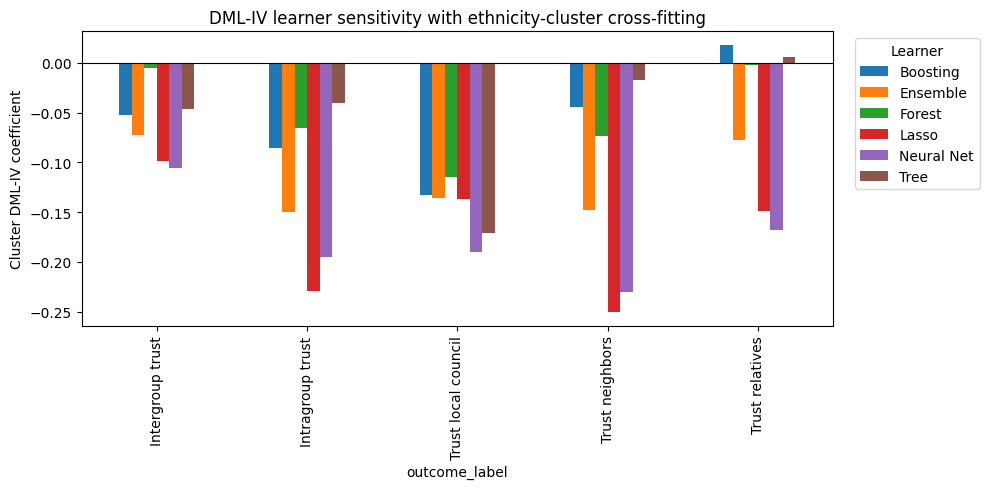

In [34]:
# Learner sensitivity under ethnicity-cluster DML-IV.
cluster_iv_learner_sensitivity = cluster_iv_results_long.pivot_table(
    index="outcome_label",
    columns="learner",
    values="theta",
    aggfunc="first",
)
display(cluster_iv_learner_sensitivity.round(3))

ax = cluster_iv_learner_sensitivity.plot(kind="bar", figsize=(10, 5))
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("DML-IV learner sensitivity with ethnicity-cluster cross-fitting")
ax.set_ylabel("Cluster DML-IV coefficient")
ax.legend(title="Learner", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Reading the cluster-fold diagnostics

The robustness comparison focuses on nuisance error, the residualized first stage, denominator stability, split dispersion, and learner sensitivity. Material changes indicate dependence on the original individual-level fold design; a weak residualized first stage limits interpretation even when the published linear first stage is strong.

## 15. Conservative DML-IV sensitivity analysis

This section combines more regularized nuisance learners with random two-fold and ethnicity-cluster five-fold designs. Sensitivity checkpoints are versioned and stored separately from the main DML-IV results.

This cell defines conservative DML-IV learners, random and ethnicity-cluster fold designs, and supporting fold and memory helpers.

In [35]:
TABLE6_IV_SENSITIVITY_VERSION = "conservative_tree_forest_elasticnet_cluster5_v1"
TABLE6_IV_SENSITIVITY_N_SPLITS = 100
TABLE6_IV_SENSITIVITY_RANDOM_SEED = 1211

TABLE6_IV_SENSITIVITY_CHECKPOINT_DIR = PROJECT_ROOT / "dml_table6_iv_sensitivity_checkpoints"
TABLE6_IV_SENSITIVITY_CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

TABLE6_IV_SENSITIVITY_DESIGNS = {
    "random_folds_conservative": {
        "label": "Random folds, conservative DML-IV learners",
        "cluster_folds": False,
        "split_cluster": None,
        "n_folds": 2,
        "n_splits": TABLE6_IV_SENSITIVITY_N_SPLITS,
    },
    "ethnicity_cluster_5fold_conservative": {
        "label": "Ethnicity-cluster 5-folds, conservative DML-IV learners",
        "cluster_folds": True,
        "split_cluster": "murdock_name",
        "n_folds": 5,
        "n_splits": TABLE6_IV_SENSITIVITY_N_SPLITS,
    },
}


class SensitivityStandardizedElasticNetRegressor:
    """GPU Elastic Net with internal standardization; l1_ratio near zero is ridge-style."""
    def __init__(self, alpha=0.005, l1_ratio=0.5, max_iter=20_000, random_state=1211):
        self.alpha = alpha
        self.l1_ratio = l1_ratio
        self.max_iter = max_iter
        self.random_state = random_state

    def fit(self, X, y):
        X_np = as_float32_numpy(X)
        self.x_mean_ = X_np.mean(axis=0, keepdims=True)
        self.x_std_ = X_np.std(axis=0, keepdims=True)
        self.x_std_[self.x_std_ == 0] = 1.0
        X_gpu = cudf.DataFrame((X_np - self.x_mean_) / self.x_std_)
        y_gpu = cudf.Series(np.asarray(y, dtype=np.float32))
        self.model_ = CuElasticNet(
            alpha=self.alpha,
            l1_ratio=self.l1_ratio,
            max_iter=self.max_iter,
            fit_intercept=True,
        )
        self.model_.fit(X_gpu, y_gpu)
        return self

    def predict(self, X):
        X_np = as_float32_numpy(X)
        X_gpu = cudf.DataFrame((X_np - self.x_mean_) / self.x_std_)
        return to_numpy_1d(self.model_.predict(X_gpu))


def make_table6_iv_sensitivity_learner_factories():
    """Fresh GPU-native conservative learners for DML-IV sensitivity analysis."""
    return {
        "Lasso Strong": lambda seed: SensitivityStandardizedElasticNetRegressor(alpha=0.01, l1_ratio=1.0, random_state=seed),
        "Elastic Net 50": lambda seed: SensitivityStandardizedElasticNetRegressor(alpha=0.005, l1_ratio=0.50, random_state=seed),
        "Elastic Net 25": lambda seed: SensitivityStandardizedElasticNetRegressor(alpha=0.005, l1_ratio=0.25, random_state=seed),
        "Ridge Style": lambda seed: SensitivityStandardizedElasticNetRegressor(alpha=0.005, l1_ratio=0.05, random_state=seed),
        "Tree Shallow": lambda seed: CuMLTreeRegressor(max_depth=3, min_samples_leaf=50, random_state=seed),
        "Tree Medium": lambda seed: CuMLTreeRegressor(max_depth=4, min_samples_leaf=50, random_state=seed),
        "Forest Shallow": lambda seed: CuMLRandomForestWrapper(n_estimators=500, max_depth=6, min_samples_leaf=50, random_state=seed),
        "Forest Medium": lambda seed: CuMLRandomForestWrapper(n_estimators=500, max_depth=8, min_samples_leaf=50, random_state=seed),
        "Boosting": lambda seed: XGBoostGPURegressor(n_estimators=300, learning_rate=0.03, max_depth=2, random_state=seed),
        "Neural Net Conservative": lambda seed: TorchMLPRegressor(
            hidden_units=8,
            max_epochs=150,
            batch_size=1024,
            learning_rate=0.001,
            weight_decay=0.05,
            patience=15,
            random_state=seed,
        ),
        "Ensemble Conservative": lambda seed: AveragingRegressor(
            estimator_factories=[
                lambda s: SensitivityStandardizedElasticNetRegressor(alpha=0.005, l1_ratio=0.50, random_state=s),
                lambda s: XGBoostGPURegressor(n_estimators=300, learning_rate=0.03, max_depth=2, random_state=s),
                lambda s: CuMLRandomForestWrapper(n_estimators=500, max_depth=6, min_samples_leaf=50, random_state=s),
                lambda s: TorchMLPRegressor(
                    hidden_units=8,
                    max_epochs=150,
                    batch_size=1024,
                    learning_rate=0.001,
                    weight_decay=0.05,
                    patience=15,
                    random_state=s,
                ),
            ],
            random_state=seed,
        ),
    }


def make_table6_iv_sensitivity_learners(random_state=1211):
    return {name: factory(random_state) for name, factory in make_table6_iv_sensitivity_learner_factories().items()}


def iter_table6_iv_sensitivity_folds(n_obs, clusters, design, split_seed):
    if design["cluster_folds"]:
        yield from iter_cluster_kfold_indices(
            clusters[design["split_cluster"]],
            n_folds=design["n_folds"],
            random_state=split_seed,
        )
    else:
        yield from iter_kfold_indices(n_obs, n_folds=design["n_folds"], random_state=split_seed)


def clear_gpu_memory_safely():
    try:
        cp.get_default_memory_pool().free_all_blocks()
    except Exception:
        pass
    try:
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    except Exception:
        pass


list(make_table6_iv_sensitivity_learners())

['Lasso Strong',
 'Elastic Net 50',
 'Elastic Net 25',
 'Ridge Style',
 'Tree Shallow',
 'Tree Medium',
 'Forest Shallow',
 'Forest Medium',
 'Boosting',
 'Neural Net Conservative',
 'Ensemble Conservative']

This repeated sensitivity estimator cross-fits three nuisance equations, computes the orthogonal IV moment, and records first-stage and denominator stability for either fold design.

In [36]:
def dml_pliv_repeated_sensitivity_crossfit(
    Y,
    D,
    Z,
    X,
    clusters,
    learner_name,
    design_name,
    random_seed=TABLE6_IV_SENSITIVITY_RANDOM_SEED,
):
    """Repeated cross-fit PLIV DML using the conservative sensitivity learner set."""
    if design_name not in TABLE6_IV_SENSITIVITY_DESIGNS:
        raise ValueError(f"Unknown IV sensitivity design: {design_name}")
    design = TABLE6_IV_SENSITIVITY_DESIGNS[design_name]
    Y = np.asarray(Y, dtype=float)
    D = np.asarray(D, dtype=float)
    Z = np.asarray(Z, dtype=float)
    X = X.copy()
    factories = make_table6_iv_sensitivity_learner_factories()
    if learner_name not in factories:
        raise ValueError(f"Unknown IV sensitivity learner: {learner_name}")

    split_results = []
    residual_store = {}

    for split in range(design["n_splits"]):
        split_seed = random_seed + split
        y_hat = np.zeros_like(Y, dtype=float)
        d_hat = np.zeros_like(D, dtype=float)
        z_hat = np.zeros_like(Z, dtype=float)

        for fold, (train_idx, test_idx) in enumerate(
            iter_table6_iv_sensitivity_folds(len(Y), clusters, design, split_seed),
            start=1,
        ):
            learner_y = factories[learner_name](split_seed + fold)
            learner_d = factories[learner_name](split_seed + 10_000 + fold)
            learner_z = factories[learner_name](split_seed + 20_000 + fold)
            X_train = X.iloc[train_idx]
            X_test = X.iloc[test_idx]

            learner_y.fit(X_train, Y[train_idx])
            y_hat[test_idx] = learner_y.predict(X_test)
            learner_d.fit(X_train, D[train_idx])
            d_hat[test_idx] = learner_d.predict(X_test)
            learner_z.fit(X_train, Z[train_idx])
            z_hat[test_idx] = learner_z.predict(X_test)

            del learner_y, learner_d, learner_z
            clear_gpu_memory_safely()

        y_resid, d_resid, z_resid = center_residuals(Y - y_hat, D - d_hat, Z - z_hat)
        final = two_way_cluster_se_iv(y_resid, d_resid, z_resid, clusters)
        first_stage = two_way_cluster_first_stage(d_resid, z_resid, clusters)

        split_results.append(
            {
                "split": split + 1,
                "theta": final["theta"],
                "se": final["se"],
                "t": final["t"],
                "p": final["p"],
                "y_mse": mse(Y, y_hat),
                "d_mse": mse(D, d_hat),
                "z_mse": mse(Z, z_hat),
                "d_resid_sd": first_stage["d_resid_sd"],
                "z_resid_sd": first_stage["z_resid_sd"],
                "denominator": first_stage["denominator"],
                "first_stage_coef": first_stage["first_stage_coef"],
                "first_stage_se": first_stage["first_stage_se"],
                "first_stage_t": first_stage["first_stage_t"],
                "first_stage_F": first_stage["first_stage_F"],
                "raw_variance": final["raw_variance"],
            }
        )
        residual_store[split + 1] = {
            "y_hat": y_hat,
            "d_hat": d_hat,
            "z_hat": z_hat,
            "y_resid": y_resid,
            "d_resid": d_resid,
            "z_resid": z_resid,
        }

    split_table = pd.DataFrame(split_results)
    median_theta = split_table["theta"].median()
    median_split = int((split_table["theta"] - median_theta).abs().idxmin()) + 1
    within_var = np.nanmedian(split_table["se"] ** 2)
    between_var = np.nanvar(split_table["theta"], ddof=1) if design["n_splits"] > 1 else 0.0
    split_adjusted_se = float(np.sqrt(within_var + between_var))
    dof = max(min(clusters["murdock_name"].nunique(), clusters["district"].nunique()) - 1, 1)
    t_stat = median_theta / split_adjusted_se if split_adjusted_se > 0 else np.nan
    p_value = 2 * stats.t.sf(np.abs(t_stat), df=dof) if split_adjusted_se > 0 else np.nan
    denominator_abs_median = float(np.nanmedian(np.abs(split_table["denominator"])))
    denominator_cv = (
        float(split_table["denominator"].std(ddof=1) / denominator_abs_median)
        if design["n_splits"] > 1 and denominator_abs_median > 0
        else 0.0
    )

    summary = {
        "learner": learner_name,
        "sensitivity_version": TABLE6_IV_SENSITIVITY_VERSION,
        "crossfit_design": design_name,
        "cluster_folds": design["cluster_folds"],
        "split_cluster": design["split_cluster"],
        "n_splits": design["n_splits"],
        "n_folds": design["n_folds"],
        "theta": float(median_theta),
        "se": split_adjusted_se,
        "t": float(t_stat) if np.isfinite(t_stat) else np.nan,
        "p": float(p_value) if np.isfinite(p_value) else np.nan,
        "median_split": median_split,
        "median_split_se": float(split_table.loc[split_table["split"] == median_split, "se"].iloc[0]),
        "split_sd": float(split_table["theta"].std(ddof=1)) if design["n_splits"] > 1 else 0.0,
        "y_mse": float(split_table["y_mse"].median()),
        "d_mse": float(split_table["d_mse"].median()),
        "z_mse": float(split_table["z_mse"].median()),
        "d_resid_sd": float(split_table["d_resid_sd"].median()),
        "z_resid_sd": float(split_table["z_resid_sd"].median()),
        "denominator": float(split_table["denominator"].median()),
        "denominator_abs_median": denominator_abs_median,
        "denominator_cv": denominator_cv,
        "first_stage_coef": float(split_table["first_stage_coef"].median()),
        "first_stage_se": float(split_table["first_stage_se"].median()),
        "first_stage_t": float(split_table["first_stage_t"].median()),
        "first_stage_F": float(split_table["first_stage_F"].median()),
    }
    summary["weak_first_stage_flag"] = summary["first_stage_F"] < 10
    summary["unstable_denominator_flag"] = summary["denominator_cv"] > 0.25
    summary["high_split_variability_flag"] = (
        abs(summary["split_sd"]) > 0.50 * max(abs(summary["theta"]), 1e-8)
    )
    return {"summary": summary, "splits": split_table, "residuals": residual_store[median_split]}

This cell defines sensitivity result stores, versioned checkpoints, and the outcome-by-design DML-IV run controller.

In [37]:
table6_iv_sensitivity_summaries = []
table6_iv_sensitivity_split_tables = {}
table6_iv_sensitivity_residuals = {}
table6_iv_sensitivity_results_long = pd.DataFrame()


def table6_iv_sensitivity_checkpoint_path(outcome, design_name):
    safe_design = design_name.replace("/", "_").replace(" ", "_")
    return TABLE6_IV_SENSITIVITY_CHECKPOINT_DIR / f"dml_table6_iv_sensitivity_{safe_design}_{outcome}.pkl"


def refresh_table6_iv_sensitivity_results_long():
    global table6_iv_sensitivity_results_long
    table6_iv_sensitivity_results_long = pd.DataFrame(table6_iv_sensitivity_summaries)
    return table6_iv_sensitivity_results_long


def remove_table6_iv_sensitivity_from_memory(outcome, design_name):
    global table6_iv_sensitivity_summaries, table6_iv_sensitivity_split_tables, table6_iv_sensitivity_residuals
    table6_iv_sensitivity_summaries = [
        row for row in table6_iv_sensitivity_summaries
        if not (row["outcome"] == outcome and row["crossfit_design"] == design_name)
    ]
    for key in list(table6_iv_sensitivity_split_tables.keys()):
        if key[0] == design_name and key[1] == outcome:
            del table6_iv_sensitivity_split_tables[key]
    for key in list(table6_iv_sensitivity_residuals.keys()):
        if key[0] == design_name and key[1] == outcome:
            del table6_iv_sensitivity_residuals[key]


def save_table6_iv_sensitivity_checkpoint(outcome, design_name):
    path = table6_iv_sensitivity_checkpoint_path(outcome, design_name)
    design = TABLE6_IV_SENSITIVITY_DESIGNS[design_name]
    payload = {
        "outcome": outcome,
        "design_name": design_name,
        "sensitivity_version": TABLE6_IV_SENSITIVITY_VERSION,
        "design": design,
        "random_seed": TABLE6_IV_SENSITIVITY_RANDOM_SEED,
        "summaries": [
            row for row in table6_iv_sensitivity_summaries
            if row["outcome"] == outcome and row["crossfit_design"] == design_name
        ],
        "split_tables": {
            key: value for key, value in table6_iv_sensitivity_split_tables.items()
            if key[0] == design_name and key[1] == outcome
        },
        "residuals": {
            key: value for key, value in table6_iv_sensitivity_residuals.items()
            if key[0] == design_name and key[1] == outcome
        },
    }
    with open(path, "wb") as f:
        pickle.dump(payload, f)
    print(f"Saved Table 6 IV sensitivity checkpoint: {path}")


def load_table6_iv_sensitivity_checkpoint(outcome, design_name):
    path = table6_iv_sensitivity_checkpoint_path(outcome, design_name)
    if not path.exists():
        return False
    with open(path, "rb") as f:
        payload = pickle.load(f)
    if payload.get("sensitivity_version") != TABLE6_IV_SENSITIVITY_VERSION:
        print(f"Found outdated IV sensitivity checkpoint for {outcome}, {design_name}; recomputing.")
        return False
    if payload.get("design_name") != design_name:
        return False
    remove_table6_iv_sensitivity_from_memory(outcome, design_name)
    table6_iv_sensitivity_summaries.extend(payload["summaries"])
    table6_iv_sensitivity_split_tables.update(payload["split_tables"])
    table6_iv_sensitivity_residuals.update(payload["residuals"])
    refresh_table6_iv_sensitivity_results_long()
    print(f"Loaded Table 6 IV sensitivity checkpoint: {path}")
    return True


def run_table6_iv_sensitivity_for_outcome(outcome, design_name, force=False):
    global table6_iv_sensitivity_summaries, table6_iv_sensitivity_split_tables, table6_iv_sensitivity_residuals
    if design_name not in TABLE6_IV_SENSITIVITY_DESIGNS:
        raise ValueError(f"Unknown IV sensitivity design: {design_name}")
    if not force and load_table6_iv_sensitivity_checkpoint(outcome, design_name):
        return table6_iv_sensitivity_results_long.loc[
            (table6_iv_sensitivity_results_long["outcome"] == outcome)
            & (table6_iv_sensitivity_results_long["crossfit_design"] == design_name)
        ].sort_values("learner")

    remove_table6_iv_sensitivity_from_memory(outcome, design_name)
    prepared = prepare_table6_iv_sample(df, outcome)
    design = TABLE6_IV_SENSITIVITY_DESIGNS[design_name]
    print(
        f"\nTable 6 IV sensitivity: {outcome} | design={design_name} | "
        f"N={prepared['n']:,} | X columns={prepared['X'].shape[1]:,}"
    )
    for learner_name in make_table6_iv_sensitivity_learner_factories().keys():
        print(f"  Running {learner_name}...")
        result = dml_pliv_repeated_sensitivity_crossfit(
            Y=prepared["Y"],
            D=prepared["D"],
            Z=prepared["Z"],
            X=prepared["X"],
            clusters=prepared["clusters"],
            learner_name=learner_name,
            design_name=design_name,
            random_seed=TABLE6_IV_SENSITIVITY_RANDOM_SEED,
        )
        summary = {
            "outcome": outcome,
            "outcome_label": outcome_labels[outcome],
            "design_label": design["label"],
            "N": prepared["n"],
            "ethnicity_clusters": prepared["n_ethnicity_clusters"],
            "district_clusters": prepared["n_district_clusters"],
            "original_iv": original_iv[outcome],
            "original_iv_se": original_iv_se[outcome],
            "original_stata_first_stage_F": original_first_stage_f[outcome],
            **result["summary"],
        }
        table6_iv_sensitivity_summaries.append(summary)
        table6_iv_sensitivity_split_tables[(design_name, outcome, learner_name)] = result["splits"]
        table6_iv_sensitivity_residuals[(design_name, outcome, learner_name)] = result["residuals"]

    refresh_table6_iv_sensitivity_results_long()
    save_table6_iv_sensitivity_checkpoint(outcome, design_name)
    return table6_iv_sensitivity_results_long.loc[
        (table6_iv_sensitivity_results_long["outcome"] == outcome)
        & (table6_iv_sensitivity_results_long["crossfit_design"] == design_name)
    ].sort_values("learner")


print(
    "Table 6 IV sensitivity setup ready. Results save under "
    f"{TABLE6_IV_SENSITIVITY_CHECKPOINT_DIR} and do not overwrite main or cluster IV checkpoints."
)

### Random-fold conservative estimates

This cell runs or loads the random-fold conservative DML-IV specification for trust in relatives.

In [38]:
run_table6_iv_sensitivity_for_outcome("trust_relatives", "random_folds_conservative")

,outcome,outcome_label,design_label,N,ethnicity_clusters,district_clusters,original_iv,original_iv_se,original_stata_first_stage_F,learner,sensitivity_version,crossfit_design,cluster_folds,split_cluster,n_splits,n_folds,theta,se,t,p,median_split,median_split_se,split_sd,y_mse,d_mse,z_mse,d_resid_sd,z_resid_sd,denominator,denominator_abs_median,denominator_cv,first_stage_coef,first_stage_se,first_stage_t,first_stage_F,weak_first_stage_flag,unstable_denominator_flag,high_split_variability_flag
8,trust_relatives,Trust relatives,"Random folds, conservative DML-IV learners",16709,147,1187,-0.172,0.076,21.7,Boosting,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.194419,0.318948,-0.609562,0.543099,85,0.310420,0.041530,0.782656,0.031755,9362.023389,0.178203,96.760353,-66432.695594,66432.695594,0.022252,-0.000424,0.000131,-3.247166,10.544090,False,False,False
2,trust_relatives,Trust relatives,"Random folds, conservative DML-IV learners",16709,147,1187,-0.172,0.076,21.7,Elastic Net 25,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.178558,0.069685,-2.562355,0.011409,72,0.070347,0.007515,0.797553,0.246938,15185.509579,0.496944,123.233173,-401379.327172,401379.327172,0.005162,-0.001583,0.000328,-4.817465,23.207970,False,False,False
1,trust_relatives,Trust relatives,"Random folds, conservative DML-IV learners",16709,147,1187,-0.172,0.076,21.7,Elastic Net 50,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.177908,0.070771,-2.513852,0.013027,48,0.070173,0.007336,0.797855,0.250511,14783.729547,0.500526,121.591999,-392953.322264,392953.322264,0.005146,-0.001592,0.000336,-4.736822,22.437486,False,False,False
10,trust_relatives,Trust relatives,"Random folds, conservative DML-IV learners",16709,147,1187,-0.172,0.076,21.7,Ensemble Conservative,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.186168,0.138369,-1.345450,0.180566,31,0.132050,0.018821,0.784116,0.078041,26181.705544,0.279357,137.781384,-203103.898060,203103.898060,0.016662,-0.000639,0.000181,-3.531632,12.472426,False,False,False
7,trust_relatives,Trust relatives,"Random folds, conservative DML-IV learners",16709,147,1187,-0.172,0.076,21.7,Forest Medium,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.039540,0.236912,-0.166897,0.867682,30,0.237426,0.020890,0.784869,0.048946,12157.308306,0.221243,110.263481,-94589.553390,94589.553390,0.031991,-0.000466,0.000152,-3.067239,9.407957,True,False,True
6,trust_relatives,Trust relatives,"Random folds, conservative DML-IV learners",16709,147,1187,-0.172,0.076,21.7,Forest Shallow,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.072275,0.180966,-0.399383,0.690195,24,0.180839,0.012108,0.794360,0.080188,19273.075166,0.283183,138.831607,-197540.225731,197540.225731,0.026552,-0.000612,0.000198,-3.105842,9.646257,True,False,False
0,trust_relatives,Trust relatives,"Random folds, conservative DML-IV learners",16709,147,1187,-0.172,0.076,21.7,Lasso Strong,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.171170,0.080777,-2.119042,0.035779,66,0.080665,0.006971,0.800901,0.275878,14097.984747,0.525256,118.738482,-362220.257368,362220.257368,0.005043,-0.001537,0.000359,-4.275351,18.278624,False,False,False
9,trust_relatives,Trust relatives,"Random folds, conservative DML-IV learners",16709,147,1187,-0.172,0.076,21.7,Neural Net Conservative,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.275249,0.250646,-1.098158,0.273943,21,0.224656,0.072556,0.804571,0.078940,184136.764022,0.280886,263.884407,-218332.324453,218332.324453,0.077264,-0.000188,0.000088,-2.165166,4.687947,True,False,False
3,trust_relatives,Trust relatives,"Random folds, conservative DML-IV learners",16709,147,1187,-0.172,0.076,21.7,Ridge Style

This cell runs or loads the random-fold conservative DML-IV specification for trust in neighbors.

In [39]:
run_table6_iv_sensitivity_for_outcome("trust_neighbors", "random_folds_conservative")

,outcome,outcome_label,design_label,N,ethnicity_clusters,district_clusters,original_iv,original_iv_se,original_stata_first_stage_F,learner,sensitivity_version,crossfit_design,cluster_folds,split_cluster,n_splits,n_folds,theta,se,t,p,median_split,median_split_se,split_sd,y_mse,d_mse,z_mse,d_resid_sd,z_resid_sd,denominator,denominator_abs_median,denominator_cv,first_stage_coef,first_stage_se,first_stage_t,first_stage_F,weak_first_stage_flag,unstable_denominator_flag,high_split_variability_flag
19,trust_neighbors,Trust neighbors,"Random folds, conservative DML-IV learners",16679,147,1187,-0.271,0.088,21.6,Boosting,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.273044,0.337628,-0.808712,0.419997,3,0.331082,0.037414,0.832157,0.031700,9372.236087,0.178049,96.813173,-66972.986626,66972.986626,0.025870,-0.000427,0.000130,-3.279361,10.754216,False,False,False
13,trust_neighbors,Trust neighbors,"Random folds, conservative DML-IV learners",16679,147,1187,-0.271,0.088,21.6,Elastic Net 25,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.256740,0.076678,-3.348283,0.001035,11,0.076044,0.008320,0.848203,0.246767,15185.312652,0.496771,123.232362,-399859.892933,399859.892933,0.006192,-0.001580,0.000329,-4.805547,23.093282,False,False,False
12,trust_neighbors,Trust neighbors,"Random folds, conservative DML-IV learners",16679,147,1187,-0.271,0.088,21.6,Elastic Net 50,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.258455,0.078954,-3.273485,0.001326,56,0.077599,0.007960,0.848462,0.250393,14786.575034,0.500408,121.603699,-391700.386671,391700.386671,0.006367,-0.001588,0.000336,-4.724511,22.321003,False,False,False
21,trust_neighbors,Trust neighbors,"Random folds, conservative DML-IV learners",16679,147,1187,-0.271,0.088,21.6,Ensemble Conservative,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.285988,0.147514,-1.938721,0.054464,11,0.144834,0.016745,0.831119,0.078009,26211.860653,0.279301,137.979818,-202425.403008,202425.403008,0.016751,-0.000640,0.000181,-3.541025,12.538859,False,False,False
18,trust_neighbors,Trust neighbors,"Random folds, conservative DML-IV learners",16679,147,1187,-0.271,0.088,21.6,Forest Medium,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.234679,0.254662,-0.921530,0.358294,15,0.263796,0.024779,0.839027,0.048920,12185.089681,0.221185,110.389135,-95133.511218,95133.511218,0.027325,-0.000467,0.000152,-3.061596,9.373370,True,False,False
17,trust_neighbors,Trust neighbors,"Random folds, conservative DML-IV learners",16679,147,1187,-0.271,0.088,21.6,Forest Shallow,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.209001,0.187684,-1.113580,0.267290,2,0.193047,0.015308,0.852636,0.080587,19319.284326,0.283887,138.997969,-197838.753072,197838.753072,0.023009,-0.000612,0.000199,-3.102710,9.626810,True,False,False
11,trust_neighbors,Trust neighbors,"Random folds, conservative DML-IV learners",16679,147,1187,-0.271,0.088,21.6,Lasso Strong,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.260005,0.092843,-2.800470,0.005794,71,0.093189,0.007466,0.851906,0.275755,14099.600201,0.525139,118.745252,-360720.337413,360720.337413,0.006597,-0.001534,0.000360,-4.266003,18.198785,False,False,False
20,trust_neighbors,Trust neighbors,"Random folds, conservative DML-IV learners",16679,147,1187,-0.271,0.088,21.6,Neural Net Conservative,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.357392,0.276015,-1.294826,0.197424,67,0.231884,0.090920,0.840877,0.078430,184437.983140,0.279965,263.376466,-216036.944471,216036.944471,0.084744,-0.000187,0.000088,-2.144722,4.599834,True,False,False
14,trust_neighbors,Trust neighbors,"Random folds, conservative DML-IV learners",16679,147,1187,-0.271,0.088,21.6,Ridg

This cell runs or loads the random-fold conservative DML-IV specification for intragroup trust.

In [40]:
run_table6_iv_sensitivity_for_outcome("intra_group_trust", "random_folds_conservative")

,outcome,outcome_label,design_label,N,ethnicity_clusters,district_clusters,original_iv,original_iv_se,original_stata_first_stage_F,learner,sensitivity_version,crossfit_design,cluster_folds,split_cluster,n_splits,n_folds,theta,se,t,p,median_split,median_split_se,split_sd,y_mse,d_mse,z_mse,d_resid_sd,z_resid_sd,denominator,denominator_abs_median,denominator_cv,first_stage_coef,first_stage_se,first_stage_t,first_stage_F,weak_first_stage_flag,unstable_denominator_flag,high_split_variability_flag
30,intra_group_trust,Intragroup trust,"Random folds, conservative DML-IV learners",16636,147,1186,-0.254,0.109,21.8,Boosting,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.375050,0.400269,-0.936994,0.350309,40,0.407278,0.040388,0.825216,0.031706,9357.317915,0.178068,96.736136,-66460.419811,66460.419811,0.028421,-0.000426,0.000130,-3.274187,10.720303,False,False,False
24,intra_group_trust,Intragroup trust,"Random folds, conservative DML-IV learners",16636,147,1186,-0.254,0.109,21.8,Elastic Net 25,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.254705,0.095613,-2.663913,0.008592,17,0.094658,0.009069,0.844381,0.247453,15181.232078,0.497461,123.215554,-401104.469352,401104.469352,0.004979,-0.001589,0.000329,-4.836003,23.386930,False,False,False
23,intra_group_trust,Intragroup trust,"Random folds, conservative DML-IV learners",16636,147,1186,-0.254,0.109,21.8,Elastic Net 50,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.251614,0.097318,-2.585483,0.010703,42,0.096811,0.008752,0.844054,0.251043,14779.930012,0.501056,121.576282,-392923.812365,392923.812365,0.005292,-0.001598,0.000336,-4.752715,22.588300,False,False,False
32,intra_group_trust,Intragroup trust,"Random folds, conservative DML-IV learners",16636,147,1186,-0.254,0.109,21.8,Ensemble Conservative,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.311007,0.160612,-1.936392,0.054751,50,0.160496,0.017148,0.825464,0.078176,26160.614530,0.279600,138.004752,-202125.544056,202125.544056,0.016324,-0.000639,0.000181,-3.524632,12.423030,False,False,False
29,intra_group_trust,Intragroup trust,"Random folds, conservative DML-IV learners",16636,147,1186,-0.254,0.109,21.8,Forest Medium,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.292686,0.265981,-1.100401,0.272968,8,0.272142,0.024868,0.831744,0.048831,12187.637389,0.220984,110.400941,-94267.543454,94267.543454,0.030139,-0.000463,0.000152,-3.058090,9.351916,True,False,False
28,intra_group_trust,Intragroup trust,"Random folds, conservative DML-IV learners",16636,147,1186,-0.254,0.109,21.8,Forest Shallow,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.237375,0.194561,-1.220058,0.224410,96,0.192212,0.015575,0.845573,0.080278,19274.551218,0.283341,138.836843,-196685.599329,196685.599329,0.025321,-0.000613,0.000198,-3.083017,9.504993,True,False,False
22,intra_group_trust,Intragroup trust,"Random folds, conservative DML-IV learners",16636,147,1186,-0.254,0.109,21.8,Lasso Strong,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.246298,0.110899,-2.220922,0.027896,21,0.109348,0.007748,0.845656,0.276451,14100.990777,0.525802,118.751074,-362472.320420,362472.320420,0.005006,-0.001546,0.000360,-4.289017,18.395668,False,False,False
31,intra_group_trust,Intragroup trust,"Random folds, conservative DML-IV learners",16636,147,1186,-0.254,0.109,21.8,Neural Net Conservative,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.400795,0.281597,-1.423295,0.156784,3,0.261962,0.093151,0.834873,0.079241,183808.812800,0.281228,263.428877,-216159.095603,216159.095603,0.073715,-0.000188,0.000088,-2.146624,4.607995,True,False,False
25,intra_group_trust,Intragroup trust,"Random folds, conservative DML-IV learners",16636,147,

This cell runs or loads the random-fold conservative DML-IV specification for trust in the local council.

In [41]:
run_table6_iv_sensitivity_for_outcome("trust_local_council", "random_folds_conservative")

,outcome,outcome_label,design_label,N,ethnicity_clusters,district_clusters,original_iv,original_iv_se,original_stata_first_stage_F,learner,sensitivity_version,crossfit_design,cluster_folds,split_cluster,n_splits,n_folds,theta,se,t,p,median_split,median_split_se,split_sd,y_mse,d_mse,z_mse,d_resid_sd,z_resid_sd,denominator,denominator_abs_median,denominator_cv,first_stage_coef,first_stage_se,first_stage_t,first_stage_F,weak_first_stage_flag,unstable_denominator_flag,high_split_variability_flag
41,trust_local_council,Trust local council,"Random folds, conservative DML-IV learners",15905,146,1194,-0.262,0.075,22.2,Boosting,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.473123,0.339375,-1.394100,0.165420,87,0.341920,0.041468,0.970178,0.031803,9636.058528,0.178339,98.166481,-67899.710359,67899.710359,0.024576,-0.000443,0.000128,-3.464684,12.004034,False,False,False
35,trust_local_council,Trust local council,"Random folds, conservative DML-IV learners",15905,146,1194,-0.262,0.075,22.2,Elastic Net 25,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.215514,0.063915,-3.371869,0.000957,70,0.063907,0.008973,0.969708,0.245317,15160.243057,0.495310,123.130720,-380345.997955,380345.997955,0.005834,-0.001577,0.000324,-4.872670,23.742914,False,False,False
34,trust_local_council,Trust local council,"Random folds, conservative DML-IV learners",15905,146,1194,-0.262,0.075,22.2,Elastic Net 50,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.220352,0.066033,-3.337016,0.001076,56,0.065757,0.008789,0.969383,0.249121,14740.930091,0.499135,121.416006,-371899.988656,371899.988656,0.005393,-0.001586,0.000332,-4.781072,22.858647,False,False,False
43,trust_local_council,Trust local council,"Random folds, conservative DML-IV learners",15905,146,1194,-0.262,0.075,22.2,Ensemble Conservative,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.321095,0.161333,-1.990254,0.048443,3,0.161968,0.018841,0.966321,0.079097,28109.075859,0.281245,140.688306,-198340.861342,198340.861342,0.014726,-0.000632,0.000179,-3.511544,12.330940,False,False,False
40,trust_local_council,Trust local council,"Random folds, conservative DML-IV learners",15905,146,1194,-0.262,0.075,22.2,Forest Medium,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.206006,0.334831,-0.615254,0.539351,99,0.327997,0.027059,0.986853,0.051653,12830.515758,0.227279,113.275264,-97021.183375,97021.183375,0.024186,-0.000476,0.000156,-3.057930,9.350938,True,False,False
39,trust_local_council,Trust local council,"Random folds, conservative DML-IV learners",15905,146,1194,-0.262,0.075,22.2,Forest Shallow,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.227241,0.251302,-0.904254,0.367360,29,0.258140,0.018983,1.005441,0.083058,19967.317002,0.288206,141.310175,-196661.907260,196661.907260,0.020712,-0.000618,0.000199,-3.103202,9.629863,True,False,False
33,trust_local_council,Trust local council,"Random folds, conservative DML-IV learners",15905,146,1194,-0.262,0.075,22.2,Lasso Strong,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.239731,0.079954,-2.998366,0.003195,30,0.078596,0.007806,0.972202,0.275095,14033.250976,0.524511,118.465732,-341099.226005,341099.226005,0.005518,-0.001528,0.000358,-4.273460,18.262465,False,False,False
42,trust_local_council,Trust local council,"Random folds, conservative DML-IV learners",15905,146,1194,-0.262,0.075,22.2,Neural Net Conservative,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.352479,0.297143,-1.186228,0.237472,49,0.256043,0.168553,0.979476,0.080701,207741.523072,0.283981,271.954062,-210072.186590,210072.186590,0.060423,-0.000177,0.000086,-2.063031,4.256118,True,False,False
36,trust_local_council,Trust local council,"Random f

This cell runs or loads the random-fold conservative DML-IV specification for intergroup trust.

In [42]:
run_table6_iv_sensitivity_for_outcome("inter_group_trust", "random_folds_conservative")

,outcome,outcome_label,design_label,N,ethnicity_clusters,district_clusters,original_iv,original_iv_se,original_stata_first_stage_F,learner,sensitivity_version,crossfit_design,cluster_folds,split_cluster,n_splits,n_folds,theta,se,t,p,median_split,median_split_se,split_sd,y_mse,d_mse,z_mse,d_resid_sd,z_resid_sd,denominator,denominator_abs_median,denominator_cv,first_stage_coef,first_stage_se,first_stage_t,first_stage_F,weak_first_stage_flag,unstable_denominator_flag,high_split_variability_flag
52,inter_group_trust,Intergroup trust,"Random folds, conservative DML-IV learners",16473,147,1184,-0.189,0.103,21.6,Boosting,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.413116,0.408631,-1.010976,0.313701,32,0.420981,0.042218,0.844175,0.031707,9387.844883,0.178069,96.893788,-66318.567173,66318.567173,0.025239,-0.000429,0.000130,-3.286513,10.801171,False,False,False
46,inter_group_trust,Intergroup trust,"Random folds, conservative DML-IV learners",16473,147,1184,-0.189,0.103,21.6,Elastic Net 25,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.181379,0.091136,-1.990199,0.048436,10,0.090121,0.009053,0.857727,0.247050,15195.884319,0.497057,123.275307,-395109.673216,395109.673216,0.005777,-0.001580,0.000328,-4.817454,23.207864,False,False,False
45,inter_group_trust,Intergroup trust,"Random folds, conservative DML-IV learners",16473,147,1184,-0.189,0.103,21.6,Elastic Net 50,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.181921,0.093274,-1.950387,0.053046,4,0.092043,0.008653,0.857972,0.250749,14798.505019,0.500764,121.652789,-386829.484850,386829.484850,0.005764,-0.001590,0.000336,-4.733623,22.407187,False,False,False
54,inter_group_trust,Intergroup trust,"Random folds, conservative DML-IV learners",16473,147,1184,-0.189,0.103,21.6,Ensemble Conservative,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.230072,0.157795,-1.458046,0.146976,8,0.156535,0.018026,0.844637,0.078472,26416.174782,0.280131,138.149174,-200475.671132,200475.671132,0.016037,-0.000640,0.000181,-3.511587,12.331245,False,False,False
51,inter_group_trust,Intergroup trust,"Random folds, conservative DML-IV learners",16473,147,1184,-0.189,0.103,21.6,Forest Medium,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.144924,0.261107,-0.555037,0.579719,19,0.261563,0.023328,0.849193,0.049515,12217.976364,0.222525,110.538261,-93814.465988,93814.465988,0.030291,-0.000467,0.000153,-3.055013,9.333106,True,False,False
50,inter_group_trust,Intergroup trust,"Random folds, conservative DML-IV learners",16473,147,1184,-0.189,0.103,21.6,Forest Shallow,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.099946,0.185282,-0.539426,0.590414,93,0.182079,0.013170,0.859689,0.080906,19320.366214,0.284448,139.001932,-195269.130749,195269.130749,0.025639,-0.000614,0.000198,-3.091741,9.558861,True,False,False
44,inter_group_trust,Intergroup trust,"Random folds, conservative DML-IV learners",16473,147,1184,-0.189,0.103,21.6,Lasso Strong,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.184501,0.105361,-1.751124,0.082025,13,0.104901,0.007542,0.860281,0.276229,14116.270074,0.525590,118.815311,-356698.584151,356698.584151,0.005465,-0.001535,0.000360,-4.265814,18.197173,False,False,False
53,inter_group_trust,Intergroup trust,"Random folds, conservative DML-IV learners",16473,147,1184,-0.189,0.103,21.6,Neural Net Conservative,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.285101,0.286172,-0.996259,0.320773,62,0.273549,0.107175,0.855508,0.080030,188644.713645,0.282824,264.374659,-216714.166443,216714.166443,0.079401,-0.000188,0.000088,-2.137352,4.568291,True,False,False
47,inter_group_trust,Intergroup trust,"Random folds, conservative DML-IV learners",16473,147,

### Five-fold ethnicity-cluster conservative estimates

This cell runs or loads the five-fold ethnicity-cluster conservative DML-IV specification for trust in relatives.

In [43]:
run_table6_iv_sensitivity_for_outcome("trust_relatives", "ethnicity_cluster_5fold_conservative")

,outcome,outcome_label,design_label,N,ethnicity_clusters,district_clusters,original_iv,original_iv_se,original_stata_first_stage_F,learner,sensitivity_version,crossfit_design,cluster_folds,split_cluster,n_splits,n_folds,theta,se,t,p,median_split,median_split_se,split_sd,y_mse,d_mse,z_mse,d_resid_sd,z_resid_sd,denominator,denominator_abs_median,denominator_cv,first_stage_coef,first_stage_se,first_stage_t,first_stage_F,weak_first_stage_flag,unstable_denominator_flag,high_split_variability_flag
63,trust_relatives,Trust relatives,"Ethnicity-cluster 5-folds, conservative DML-IV...",16709,147,1187,-0.172,0.076,21.7,Boosting,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,0.019123,0.162078,0.117989,0.906239,17,0.174500,0.059380,0.830387,0.831763,45819.671501,0.878154,210.908857,-1.032705e+06,1.032705e+06,0.194176,-0.001405,0.000689,-2.053079,4.215240,True,False,True
57,trust_relatives,Trust relatives,"Ethnicity-cluster 5-folds, conservative DML-IV...",16709,147,1187,-0.172,0.076,21.7,Elastic Net 25,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.215805,0.096388,-2.238918,0.026674,26,0.047863,0.061161,0.877076,0.925612,39755.337024,0.955476,198.739012,-1.526282e+06,1.526282e+06,0.386920,-0.002364,0.000634,-3.703314,13.714577,False,True,False
56,trust_relatives,Trust relatives,"Ethnicity-cluster 5-folds, conservative DML-IV...",16709,147,1187,-0.172,0.076,21.7,Elastic Net 50,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.193489,0.091611,-2.112074,0.036383,48,0.058212,0.059857,0.869713,0.933643,38998.913279,0.961861,196.954421,-1.494797e+06,1.494797e+06,0.402537,-0.002362,0.000636,-3.659230,13.389976,False,True,False
65,trust_relatives,Trust relatives,"Ethnicity-cluster 5-folds, conservative DML-IV...",16709,147,1187,-0.172,0.076,21.7,Ensemble Conservative,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.077040,0.101817,-0.756655,0.450476,93,0.081171,0.043328,0.828794,0.703954,43323.489715,0.821854,202.877920,-1.193776e+06,1.193776e+06,0.184969,-0.001751,0.000622,-2.741117,7.513722,True,False,True
62,trust_relatives,Trust relatives,"Ethnicity-cluster 5-folds, conservative DML-IV...",16709,147,1187,-0.172,0.076,21.7,Forest Medium,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,0.023575,0.140476,0.167822,0.866956,20,0.136130,0.039876,0.835035,0.657368,46300.733606,0.786632,214.267225,-1.167096e+06,1.167096e+06,0.147778,-0.001514,0.000531,-2.821017,7.958175,True,False,True
61,trust_relatives,Trust relatives,"Ethnicity-cluster 5-folds, conservative DML-IV...",16709,147,1187,-0.172,0.076,21.7,Forest Shallow,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,0.003655,0.133482,0.027379,0.978195,2,0.095895,0.035980,0.842574,0.646245,51152.374508,0.785664,225.318654,-1.277775e+06,1.277775e+06,0.138917,-0.001506,0.000511,-2.963835,8.784335,True,False,True
55,trust_relatives,Trust relatives,"Ethnicity-cluster 5-folds, conservative DML-IV...",16709,147,1187,-0.172,0.076,21.7,Lasso Strong,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.106963,0.097568,-1.096289,0.274757,81,0.054372,0.073110,0.844203,0.959485,37638.279645,0.974625,193.838281,-1.397396e+06,1.397396e+06,0.361406,-0.002281,0.000626,-3.472395,12.057553,False,True,True
64,trust_relatives,Trust relatives,"Ethnicity-cluster 5-folds, conservative DML-IV...",16709,147,1187,-0.172,0.076,21.7,Neural Net Conservative,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.070756,0.212661,-0.332715,0.739827,35,0.199967,0.143678,0.905990,0.731767,136469.672854,0.844684,270.710769,-1.074246e+06,1.074246e+06,0.282708

This cell runs or loads the five-fold ethnicity-cluster conservative DML-IV specification for trust in neighbors.

In [44]:
run_table6_iv_sensitivity_for_outcome("trust_neighbors", "ethnicity_cluster_5fold_conservative")

,outcome,outcome_label,design_label,N,ethnicity_clusters,district_clusters,original_iv,original_iv_se,original_stata_first_stage_F,learner,sensitivity_version,crossfit_design,cluster_folds,split_cluster,n_splits,n_folds,theta,se,t,p,median_split,median_split_se,split_sd,y_mse,d_mse,z_mse,d_resid_sd,z_resid_sd,denominator,denominator_abs_median,denominator_cv,first_stage_coef,first_stage_se,first_stage_t,first_stage_F,weak_first_stage_flag,unstable_denominator_flag,high_split_variability_flag
74,trust_neighbors,Trust neighbors,"Ethnicity-cluster 5-folds, conservative DML-IV...",16679,147,1187,-0.271,0.088,21.6,Boosting,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.031147,0.118943,-0.261864,0.793795,17,0.133300,0.053968,0.883103,0.835811,45719.911240,0.879033,211.512874,-1.033589e+06,1.033589e+06,0.193854,-0.001423,0.000686,-2.059227,4.240415,True,False,True
68,trust_neighbors,Trust neighbors,"Ethnicity-cluster 5-folds, conservative DML-IV...",16679,147,1187,-0.271,0.088,21.6,Elastic Net 25,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.289148,0.106960,-2.703334,0.007680,17,0.084232,0.068461,0.933114,0.927501,39966.487651,0.955700,199.018589,-1.523598e+06,1.523598e+06,0.386754,-0.002369,0.000634,-3.690673,13.621073,False,True,False
67,trust_neighbors,Trust neighbors,"Ethnicity-cluster 5-folds, conservative DML-IV...",16679,147,1187,-0.271,0.088,21.6,Elastic Net 50,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.271194,0.099519,-2.725047,0.007215,51,0.065790,0.065315,0.923831,0.934518,39187.101231,0.961204,197.240976,-1.492198e+06,1.492198e+06,0.402072,-0.002363,0.000635,-3.652509,13.340944,False,True,False
76,trust_neighbors,Trust neighbors,"Ethnicity-cluster 5-folds, conservative DML-IV...",16679,147,1187,-0.271,0.088,21.6,Ensemble Conservative,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.139318,0.082080,-1.697339,0.091763,91,0.077231,0.039424,0.881641,0.699310,43576.852283,0.822012,203.144640,-1.207450e+06,1.207450e+06,0.183426,-0.001755,0.000624,-2.751146,7.568806,True,False,False
73,trust_neighbors,Trust neighbors,"Ethnicity-cluster 5-folds, conservative DML-IV...",16679,147,1187,-0.271,0.088,21.6,Forest Medium,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.037750,0.123724,-0.305115,0.760713,81,0.118357,0.037776,0.897781,0.655177,46455.106262,0.783742,214.721821,-1.147519e+06,1.147519e+06,0.152517,-0.001512,0.000534,-2.833721,8.029978,True,False,True
72,trust_neighbors,Trust neighbors,"Ethnicity-cluster 5-folds, conservative DML-IV...",16679,147,1187,-0.271,0.088,21.6,Forest Shallow,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.054010,0.119773,-0.450932,0.652707,78,0.093498,0.034428,0.908350,0.648152,51088.088847,0.784848,225.713297,-1.255494e+06,1.255494e+06,0.143059,-0.001509,0.000513,-2.943296,8.662993,True,False,True
66,trust_neighbors,Trust neighbors,"Ethnicity-cluster 5-folds, conservative DML-IV...",16679,147,1187,-0.271,0.088,21.6,Lasso Strong,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.174213,0.081664,-2.133289,0.034573,84,0.075477,0.056340,0.898883,0.957833,37783.575098,0.974284,193.678999,-1.403266e+06,1.403266e+06,0.359315,-0.002283,0.000629,-3.481891,12.123642,False,True,False
75,trust_neighbors,Trust neighbors,"Ethnicity-cluster 5-folds, conservative DML-IV...",16679,147,1187,-0.271,0.088,21.6,Neural Net Conservative,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.160789,0.187699,-0.856628,0.393054,11,0.239618,0.118849,0.928281,0.730769,136514.001682,0.839729,271.516821,-1.061278e+06,1.061278e+06

This cell runs or loads the five-fold ethnicity-cluster conservative DML-IV specification for intragroup trust.

In [45]:
run_table6_iv_sensitivity_for_outcome("intra_group_trust", "ethnicity_cluster_5fold_conservative")

,outcome,outcome_label,design_label,N,ethnicity_clusters,district_clusters,original_iv,original_iv_se,original_stata_first_stage_F,learner,sensitivity_version,crossfit_design,cluster_folds,split_cluster,n_splits,n_folds,theta,se,t,p,median_split,median_split_se,split_sd,y_mse,d_mse,z_mse,d_resid_sd,z_resid_sd,denominator,denominator_abs_median,denominator_cv,first_stage_coef,first_stage_se,first_stage_t,first_stage_F,weak_first_stage_flag,unstable_denominator_flag,high_split_variability_flag
85,intra_group_trust,Intragroup trust,"Ethnicity-cluster 5-folds, conservative DML-IV...",16636,147,1186,-0.254,0.109,21.8,Boosting,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.083667,0.106000,-0.789317,0.431207,100,0.078663,0.051656,0.875915,0.831398,45235.614713,0.877292,210.729061,-1.019524e+06,1.019524e+06,0.197299,-0.001422,0.000684,-2.101127,4.414937,True,False,True
79,intra_group_trust,Intragroup trust,"Ethnicity-cluster 5-folds, conservative DML-IV...",16636,147,1186,-0.254,0.109,21.8,Elastic Net 25,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.226866,0.084177,-2.695105,0.007862,52,0.084367,0.049266,0.912428,0.929800,39913.613100,0.957757,198.953519,-1.530643e+06,1.530643e+06,0.385939,-0.002376,0.000638,-3.713325,13.788835,False,True,False
78,intra_group_trust,Intragroup trust,"Ethnicity-cluster 5-folds, conservative DML-IV...",16636,147,1186,-0.254,0.109,21.8,Elastic Net 50,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.213835,0.079225,-2.699084,0.007774,27,0.062613,0.047127,0.904513,0.938113,39119.915114,0.964087,197.258686,-1.499272e+06,1.499272e+06,0.401501,-0.002375,0.000638,-3.667769,13.452535,False,True,False
87,intra_group_trust,Intragroup trust,"Ethnicity-cluster 5-folds, conservative DML-IV...",16636,147,1186,-0.254,0.109,21.8,Ensemble Conservative,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.139281,0.078282,-1.779224,0.077284,100,0.055076,0.038447,0.871633,0.701186,43744.321380,0.822081,203.582629,-1.197174e+06,1.197174e+06,0.182945,-0.001771,0.000624,-2.724803,7.424558,True,False,False
84,intra_group_trust,Intragroup trust,"Ethnicity-cluster 5-folds, conservative DML-IV...",16636,147,1186,-0.254,0.109,21.8,Forest Medium,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.055382,0.104489,-0.530028,0.596898,91,0.090572,0.044087,0.891349,0.661525,46411.276834,0.788237,214.528531,-1.161853e+06,1.161853e+06,0.151545,-0.001508,0.000533,-2.847738,8.109611,True,False,True
83,intra_group_trust,Intragroup trust,"Ethnicity-cluster 5-folds, conservative DML-IV...",16636,147,1186,-0.254,0.109,21.8,Forest Shallow,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.073094,0.102946,-0.710021,0.478824,12,0.074861,0.040230,0.901165,0.650169,51338.773002,0.788558,225.544636,-1.264967e+06,1.264967e+06,0.141375,-0.001508,0.000510,-2.949791,8.701320,True,False,True
77,intra_group_trust,Intragroup trust,"Ethnicity-cluster 5-folds, conservative DML-IV...",16636,147,1186,-0.254,0.109,21.8,Lasso Strong,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.183168,0.076758,-2.386313,0.018300,34,0.072287,0.041513,0.889409,0.962343,37706.429319,0.976305,193.905766,-1.403807e+06,1.403807e+06,0.359196,-0.002292,0.000628,-3.487484,12.162550,False,True,False
86,intra_group_trust,Intragroup trust,"Ethnicity-cluster 5-folds, conservative DML-IV...",16636,147,1186,-0.254,0.109,21.8,Neural Net Conservative,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.147519,0.171695,-0.859191,0.391644,6,0.077987,0.101168,0.898700,0.732122,136982.719626,0.844767,271.112892,-

This cell runs or loads the five-fold ethnicity-cluster conservative DML-IV specification for trust in the local council.

In [46]:
run_table6_iv_sensitivity_for_outcome("trust_local_council", "ethnicity_cluster_5fold_conservative")

,outcome,outcome_label,design_label,N,ethnicity_clusters,district_clusters,original_iv,original_iv_se,original_stata_first_stage_F,learner,sensitivity_version,crossfit_design,cluster_folds,split_cluster,n_splits,n_folds,theta,se,t,p,median_split,median_split_se,split_sd,y_mse,d_mse,z_mse,d_resid_sd,z_resid_sd,denominator,denominator_abs_median,denominator_cv,first_stage_coef,first_stage_se,first_stage_t,first_stage_F,weak_first_stage_flag,unstable_denominator_flag,high_split_variability_flag
96,trust_local_council,Trust local council,"Ethnicity-cluster 5-folds, conservative DML-IV...",15905,146,1194,-0.262,0.075,22.2,Boosting,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.143243,0.127138,-1.126677,0.261740,100,0.089995,0.061552,1.007655,0.813543,44392.218861,0.870721,209.130016,-9.241999e+05,9.241999e+05,0.240689,-0.001326,0.000686,-1.956056,3.826161,True,False,False
90,trust_local_council,Trust local council,"Ethnicity-cluster 5-folds, conservative DML-IV...",15905,146,1194,-0.262,0.075,22.2,Elastic Net 25,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.189913,0.085756,-2.214564,0.028351,57,0.065489,0.055716,1.012096,0.933616,40462.926434,0.960864,200.638047,-1.607129e+06,1.607129e+06,0.326053,-0.002410,0.000600,-3.937879,15.506900,False,True,False
89,trust_local_council,Trust local council,"Ethnicity-cluster 5-folds, conservative DML-IV...",15905,146,1194,-0.262,0.075,22.2,Elastic Net 50,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.182090,0.087824,-2.073347,0.039909,56,0.078602,0.056637,1.006759,0.940294,39595.125242,0.963108,198.235978,-1.574392e+06,1.574392e+06,0.334630,-0.002330,0.000611,-3.833557,14.696163,False,True,False
98,trust_local_council,Trust local council,"Ethnicity-cluster 5-folds, conservative DML-IV...",15905,146,1194,-0.262,0.075,22.2,Ensemble Conservative,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.132206,0.081435,-1.623446,0.106666,67,0.068158,0.041198,0.996850,0.684721,44458.733770,0.812830,203.710965,-1.136501e+06,1.136501e+06,0.187410,-0.001719,0.000623,-2.769300,7.669121,True,False,False
95,trust_local_council,Trust local council,"Ethnicity-cluster 5-folds, conservative DML-IV...",15905,146,1194,-0.262,0.075,22.2,Forest Medium,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.073793,0.103470,-0.713185,0.476878,7,0.103319,0.042470,1.039288,0.642205,46662.887367,0.780659,215.152541,-1.103446e+06,1.103446e+06,0.145154,-0.001536,0.000533,-2.828226,7.998864,True,False,True
94,trust_local_council,Trust local council,"Ethnicity-cluster 5-folds, conservative DML-IV...",15905,146,1194,-0.262,0.075,22.2,Forest Shallow,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.099265,0.108084,-0.918399,0.359935,7,0.104137,0.039488,1.054824,0.638241,51466.639886,0.783068,226.287267,-1.227061e+06,1.227061e+06,0.133127,-0.001519,0.000507,-2.929041,8.579284,True,False,False
88,trust_local_council,Trust local council,"Ethnicity-cluster 5-folds, conservative DML-IV...",15905,146,1194,-0.262,0.075,22.2,Lasso Strong,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.165370,0.089006,-1.857955,0.065203,1,0.049394,0.066221,0.998345,0.941166,38057.675064,0.965606,194.270655,-1.418538e+06,1.418538e+06,0.320772,-0.002097,0.000610,-3.401797,11.572388,False,True,False
97,trust_local_council,Trust local council,"Ethnicity-cluster 5-folds, conservative DML-IV...",15905,146,1194,-0.262,0.075,22.2,Neural Net Conservative,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.108211,0.137458,-0.787234,0.432430,42,0.094869,0.098378,1.025390,0.739

This cell runs or loads the five-fold ethnicity-cluster conservative DML-IV specification for intergroup trust.

In [47]:
run_table6_iv_sensitivity_for_outcome("inter_group_trust", "ethnicity_cluster_5fold_conservative")

,outcome,outcome_label,design_label,N,ethnicity_clusters,district_clusters,original_iv,original_iv_se,original_stata_first_stage_F,learner,sensitivity_version,crossfit_design,cluster_folds,split_cluster,n_splits,n_folds,theta,se,t,p,median_split,median_split_se,split_sd,y_mse,d_mse,z_mse,d_resid_sd,z_resid_sd,denominator,denominator_abs_median,denominator_cv,first_stage_coef,first_stage_se,first_stage_t,first_stage_F,weak_first_stage_flag,unstable_denominator_flag,high_split_variability_flag
107,inter_group_trust,Intergroup trust,"Ethnicity-cluster 5-folds, conservative DML-IV...",16473,147,1184,-0.189,0.103,21.6,Boosting,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.070155,0.093872,-0.747346,0.456057,20,0.121746,0.042565,0.877585,0.838268,45640.333136,0.882294,211.126964,-1.023226e+06,1.023226e+06,0.194843,-0.001444,0.000686,-2.065678,4.267028,True,False,True
101,inter_group_trust,Intergroup trust,"Ethnicity-cluster 5-folds, conservative DML-IV...",16473,147,1184,-0.189,0.103,21.6,Elastic Net 25,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.110683,0.088549,-1.249966,0.213312,78,0.058491,0.057904,0.902619,0.928283,39887.968433,0.956519,198.991901,-1.499515e+06,1.499515e+06,0.391631,-0.002355,0.000636,-3.686346,13.589194,False,True,True
100,inter_group_trust,Intergroup trust,"Ethnicity-cluster 5-folds, conservative DML-IV...",16473,147,1184,-0.189,0.103,21.6,Elastic Net 50,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.110682,0.081756,-1.353799,0.177892,46,0.036413,0.052043,0.896432,0.935790,39155.257189,0.962085,197.314869,-1.468659e+06,1.468659e+06,0.407201,-0.002357,0.000636,-3.638438,13.238231,False,True,False
109,inter_group_trust,Intergroup trust,"Ethnicity-cluster 5-folds, conservative DML-IV...",16473,147,1184,-0.189,0.103,21.6,Ensemble Conservative,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.065378,0.071694,-0.911913,0.363318,45,0.057582,0.034683,0.876233,0.701420,43713.582186,0.822633,203.453724,-1.186347e+06,1.186347e+06,0.183641,-0.001760,0.000626,-2.707904,7.332819,True,False,True
106,inter_group_trust,Intergroup trust,"Ethnicity-cluster 5-folds, conservative DML-IV...",16473,147,1184,-0.189,0.103,21.6,Forest Medium,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,0.009511,0.103958,0.091485,0.927232,1,0.078481,0.043162,0.892201,0.658765,46527.920285,0.787074,214.896130,-1.150786e+06,1.150786e+06,0.149254,-0.001509,0.000535,-2.845195,8.095207,True,False,True
105,inter_group_trust,Intergroup trust,"Ethnicity-cluster 5-folds, conservative DML-IV...",16473,147,1184,-0.189,0.103,21.6,Forest Shallow,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.003121,0.101623,-0.030716,0.975538,64,0.087820,0.039074,0.898382,0.649509,51304.134549,0.788420,225.774613,-1.261167e+06,1.261167e+06,0.140321,-0.001503,0.000515,-2.941530,8.652599,True,False,True
99,inter_group_trust,Intergroup trust,"Ethnicity-cluster 5-folds, conservative DML-IV...",16473,147,1184,-0.189,0.103,21.6,Lasso Strong,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.107593,0.064087,-1.678864,0.095318,61,0.057865,0.032579,0.885974,0.960747,37798.506702,0.975487,194.255440,-1.383905e+06,1.383905e+06,0.361256,-0.002279,0.000624,-3.494093,12.208689,False,True,False
108,inter_group_trust,Intergroup trust,"Ethnicity-cluster 5-folds, conservative DML-IV...",16473,147,1184,-0.189,0.103,21.6,Neural Net Conservative,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.090292,0.150236,-0.601003,0.548770,97,0.128013,0.092212,0.903747,0.736166,137692.077456,0.842654,271.758311,

### Sensitivity results and diagnostics

This cell refreshes and displays the complete long-form DML-IV sensitivity result table.

In [48]:
table6_iv_sensitivity_results_long = refresh_table6_iv_sensitivity_results_long()
if table6_iv_sensitivity_results_long.empty:
    raise ValueError("No Table 6 IV sensitivity results are loaded. Run at least one sensitivity outcome cell first.")

table6_iv_sensitivity_results_long.sort_values(["crossfit_design", "outcome", "learner"])

,outcome,outcome_label,design_label,N,ethnicity_clusters,district_clusters,original_iv,original_iv_se,original_stata_first_stage_F,learner,sensitivity_version,crossfit_design,cluster_folds,split_cluster,n_splits,n_folds,theta,se,t,p,median_split,median_split_se,split_sd,y_mse,d_mse,z_mse,d_resid_sd,z_resid_sd,denominator,denominator_abs_median,denominator_cv,first_stage_coef,first_stage_se,first_stage_t,first_stage_F,weak_first_stage_flag,unstable_denominator_flag,high_split_variability_flag
107,inter_group_trust,Intergroup trust,"Ethnicity-cluster 5-folds, conservative DML-IV...",16473,147,1184,-0.189,0.103,21.6,Boosting,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.070155,0.093872,-0.747346,0.456057,20,0.121746,0.042565,0.877585,0.838268,45640.333136,0.882294,211.126964,-1.023226e+06,1.023226e+06,0.194843,-0.001444,0.000686,-2.065678,4.267028,True,False,True
101,inter_group_trust,Intergroup trust,"Ethnicity-cluster 5-folds, conservative DML-IV...",16473,147,1184,-0.189,0.103,21.6,Elastic Net 25,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.110683,0.088549,-1.249966,0.213312,78,0.058491,0.057904,0.902619,0.928283,39887.968433,0.956519,198.991901,-1.499515e+06,1.499515e+06,0.391631,-0.002355,0.000636,-3.686346,13.589194,False,True,True
100,inter_group_trust,Intergroup trust,"Ethnicity-cluster 5-folds, conservative DML-IV...",16473,147,1184,-0.189,0.103,21.6,Elastic Net 50,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.110682,0.081756,-1.353799,0.177892,46,0.036413,0.052043,0.896432,0.935790,39155.257189,0.962085,197.314869,-1.468659e+06,1.468659e+06,0.407201,-0.002357,0.000636,-3.638438,13.238231,False,True,False
109,inter_group_trust,Intergroup trust,"Ethnicity-cluster 5-folds, conservative DML-IV...",16473,147,1184,-0.189,0.103,21.6,Ensemble Conservative,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.065378,0.071694,-0.911913,0.363318,45,0.057582,0.034683,0.876233,0.701420,43713.582186,0.822633,203.453724,-1.186347e+06,1.186347e+06,0.183641,-0.001760,0.000626,-2.707904,7.332819,True,False,True
106,inter_group_trust,Intergroup trust,"Ethnicity-cluster 5-folds, conservative DML-IV...",16473,147,1184,-0.189,0.103,21.6,Forest Medium,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,0.009511,0.103958,0.091485,0.927232,1,0.078481,0.043162,0.892201,0.658765,46527.920285,0.787074,214.896130,-1.150786e+06,1.150786e+06,0.149254,-0.001509,0.000535,-2.845195,8.095207,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,trust_relatives,Trust relatives,"Random folds, conservative DML-IV learners",16709,147,1187,-0.172,0.076,21.7,Lasso Strong,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.171170,0.080777,-2.119042,0.035779,66,0.080665,0.006971,0.800901,0.275878,14097.984747,0.525256,118.738482,-3.622203e+05,3.622203e+05,0.005043,-0.001537,0.000359,-4.275351,18.278624,False,False,False
9,trust_relatives,Trust relatives,"Random folds, conservative DML-IV learners",16709,147,1187,-0.172,0.076,21.7,Neural Net Conservative,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.275249,0.250646,-1.098158,0.273943,21,0.224656,0.072556,0.804571,0.078940,184136.764022,0.280886,263.884407,-2.183323e+05,2.183323e+05,0.077264,-0.000188,0.000088,-2.165166,4.687947,True,False,False
3,trust_relatives,Trust relatives,"Random folds, conservative DML-IV learners",16709,147,1187,-0.172,0.076,21.7,Ridge Style,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.175260,0.070380,-2.490185,0.013889,95,0.0

The sensitivity selection rule ranks learners within each outcome and fold design using all three nuisance losses and residualized first-stage stability.

In [49]:
def choose_best_table6_iv_sensitivity(results):
    if results.empty:
        return results.copy(), results.copy()
    ranked = results.copy()
    ranked["weak_penalty"] = ranked["weak_first_stage_flag"].astype(int) * 100
    ranked["denominator_penalty"] = ranked["unstable_denominator_flag"].astype(int) * 100
    ranked["y_mse_rank"] = ranked.groupby(["crossfit_design", "outcome"])["y_mse"].rank(method="min")
    ranked["d_mse_rank"] = ranked.groupby(["crossfit_design", "outcome"])["d_mse"].rank(method="min")
    ranked["z_mse_rank"] = ranked.groupby(["crossfit_design", "outcome"])["z_mse"].rank(method="min")
    ranked["first_stage_rank"] = ranked.groupby(["crossfit_design", "outcome"])["first_stage_F"].rank(
        method="min",
        ascending=False,
    )
    ranked["nuisance_rank"] = (
        ranked["y_mse_rank"]
        + ranked["d_mse_rank"]
        + ranked["z_mse_rank"]
        + ranked["first_stage_rank"]
        + ranked["weak_penalty"]
        + ranked["denominator_penalty"]
    )
    ranked = ranked.sort_values(["crossfit_design", "outcome", "nuisance_rank", "learner"])
    best = ranked.groupby(["crossfit_design", "outcome"], as_index=False).first()
    return ranked, best


table6_iv_sensitivity_ranked, table6_iv_sensitivity_best_by_outcome = choose_best_table6_iv_sensitivity(
    table6_iv_sensitivity_results_long
)

table6_iv_sensitivity_best_by_outcome[
    [
        "crossfit_design",
        "outcome",
        "learner",
        "original_iv",
        "original_iv_se",
        "theta",
        "se",
        "p",
        "first_stage_F",
        "denominator_cv",
        "weak_first_stage_flag",
        "unstable_denominator_flag",
        "N",
        "ethnicity_clusters",
        "district_clusters",
    ]
].sort_values(["crossfit_design", "outcome"])

,crossfit_design,outcome,learner,original_iv,original_iv_se,theta,se,p,first_stage_F,denominator_cv,weak_first_stage_flag,unstable_denominator_flag,N,ethnicity_clusters,district_clusters
0,ethnicity_cluster_5fold_conservative,inter_group_trust,Ensemble Conservative,-0.189,0.103,-0.065378,0.071694,0.363318,7.332819,0.183641,True,False,16473,147,1184
1,ethnicity_cluster_5fold_conservative,intra_group_trust,Ensemble Conservative,-0.254,0.109,-0.139281,0.078282,0.077284,7.424558,0.182945,True,False,16636,147,1186
2,ethnicity_cluster_5fold_conservative,trust_local_council,Elastic Net 50,-0.262,0.075,-0.182090,0.087824,0.039909,14.696163,0.334630,False,True,15905,146,1194
3,ethnicity_cluster_5fold_conservative,trust_neighbors,Ensemble Conservative,-0.271,0.088,-0.139318,0.082080,0.091763,7.568806,0.183426,True,False,16679,147,1187
4,ethnicity_cluster_5fold_conservative,trust_relatives,Ensemble Conservative,-0.172,0.076,-0.077040,0.101817,0.450476,7.513722,0.184969,True,False,16709,147,1187
5,random_folds_conservative,inter_group_trust,Boosting,-0.189,0.103,-0.413116,0.408631,0.313701,10.801171,0.025239,False,False,16473,147,1184
6,random_folds_conservative,intra_group_trust,Boosting,-0.254,0.109,-0.375050,0.400269,0.350309,10.720303,0.028421,False,False,16636,147,1186
7,random_folds_conservative,trust_local_council,Boosting,-0.262,0.075,-0.473123,0.339375,0.165420,12.004034,0.024576,False,False,15905,146,1194
8,random_folds_conservative,trust_neighbors,Boosting,-0.271,0.088,-0.273044,0.337628,0.419997,10.754216,0.025870,False,False,16679,147,1187
9,random_folds_conservative,trust_relatives,Boosting,-0.172,0.076,-0.194419,0.318948,0.543099,10.544090,0.022252,False,False,16709,147,1187


This cell compares the selected main DML-IV estimate with selected estimates from both conservative sensitivity designs.

In [50]:
comparison_frames = []

if "results_long" in globals() and not results_long.empty:
    main_ranked, main_best = choose_best_learners_iv(results_long)
    comparison_frames.append(
        main_best.assign(crossfit_design="main_random_2fold", sensitivity_version="main_specification")
    )

if "cluster_iv_results_long" in globals() and not cluster_iv_results_long.empty:
    cluster_ranked, cluster_best = choose_best_learners_iv(cluster_iv_results_long)
    comparison_frames.append(
        cluster_best.assign(crossfit_design="main_ethnicity_cluster_2fold", sensitivity_version="cluster_robustness")
    )

comparison_frames.append(table6_iv_sensitivity_best_by_outcome)
table6_iv_sensitivity_best_comparison = pd.concat(comparison_frames, ignore_index=True, sort=False)

table6_iv_sensitivity_best_comparison[
    [
        "crossfit_design",
        "outcome",
        "learner",
        "original_iv",
        "theta",
        "se",
        "p",
        "first_stage_F",
        "denominator_cv",
        "weak_first_stage_flag",
        "unstable_denominator_flag",
        "N",
        "ethnicity_clusters",
        "district_clusters",
    ]
].sort_values(["outcome", "crossfit_design"])

,crossfit_design,outcome,learner,original_iv,theta,se,p,first_stage_F,denominator_cv,weak_first_stage_flag,unstable_denominator_flag,N,ethnicity_clusters,district_clusters
10,ethnicity_cluster_5fold_conservative,inter_group_trust,Ensemble Conservative,-0.189,-0.065378,0.071694,0.363318,7.332819,0.183641,True,False,16473,147,1184
5,main_ethnicity_cluster_2fold,inter_group_trust,Lasso,-0.189,-0.098708,0.138274,0.476453,10.281945,1.236402,False,True,16473,147,1184
0,main_random_2fold,inter_group_trust,Ensemble,-0.189,-0.327284,0.211156,0.123316,18.256879,0.018994,False,False,16473,147,1184
15,random_folds_conservative,inter_group_trust,Boosting,-0.189,-0.413116,0.408631,0.313701,10.801171,0.025239,False,False,16473,147,1184
11,ethnicity_cluster_5fold_conservative,intra_group_trust,Ensemble Conservative,-0.254,-0.139281,0.078282,0.077284,7.424558,0.182945,True,False,16636,147,1186
6,main_ethnicity_cluster_2fold,intra_group_trust,Lasso,-0.254,-0.228909,0.146489,0.120302,10.453643,1.235411,False,True,16636,147,1186
1,main_random_2fold,intra_group_trust,Ensemble,-0.254,-0.372956,0.206329,0.072730,18.215059,0.018738,False,False,16636,147,1186
16,random_folds_conservative,intra_group_trust,Boosting,-0.254,-0.375050,0.400269,0.350309,10.720303,0.028421,False,False,16636,147,1186
12,ethnicity_cluster_5fold_conservative,trust_local_council,Elastic Net 50,-0.262,-0.182090,0.087824,0.039909,14.696163,0.334630,False,True,15905,146,1194
7,main_ethnicity_cluster_2fold,trust_local_council,Lasso,-0.262,-0.137043,0.157200,0.384773,10.755771,0.747800,False,True,15905,146,1194


This cell constructs a compact diagnostic table for nuisance prediction, residualized first-stage strength, denominator stability, and split variation.

In [51]:
table6_iv_sensitivity_diagnostics = table6_iv_sensitivity_results_long.copy()
table6_iv_sensitivity_diagnostics["abs_theta_minus_original"] = (
    table6_iv_sensitivity_diagnostics["theta"] - table6_iv_sensitivity_diagnostics["original_iv"]
).abs()
table6_iv_sensitivity_diagnostics["opposite_original_sign"] = (
    np.sign(table6_iv_sensitivity_diagnostics["theta"]) != np.sign(table6_iv_sensitivity_diagnostics["original_iv"])
)

table6_iv_sensitivity_diagnostics[
    [
        "crossfit_design",
        "outcome",
        "learner",
        "theta",
        "se",
        "p",
        "split_sd",
        "high_split_variability_flag",
        "first_stage_F",
        "denominator",
        "denominator_cv",
        "weak_first_stage_flag",
        "unstable_denominator_flag",
        "y_mse",
        "d_mse",
        "z_mse",
        "abs_theta_minus_original",
        "opposite_original_sign",
    ]
].sort_values(["crossfit_design", "outcome", "learner"])

,crossfit_design,outcome,learner,theta,se,p,split_sd,high_split_variability_flag,first_stage_F,denominator,denominator_cv,weak_first_stage_flag,unstable_denominator_flag,y_mse,d_mse,z_mse,abs_theta_minus_original,opposite_original_sign
107,ethnicity_cluster_5fold_conservative,inter_group_trust,Boosting,-0.070155,0.093872,0.456057,0.042565,True,4.267028,-1.023226e+06,0.194843,True,False,0.877585,0.838268,45640.333136,0.118845,False
101,ethnicity_cluster_5fold_conservative,inter_group_trust,Elastic Net 25,-0.110683,0.088549,0.213312,0.057904,True,13.589194,-1.499515e+06,0.391631,False,True,0.902619,0.928283,39887.968433,0.078317,False
100,ethnicity_cluster_5fold_conservative,inter_group_trust,Elastic Net 50,-0.110682,0.081756,0.177892,0.052043,False,13.238231,-1.468659e+06,0.407201,False,True,0.896432,0.935790,39155.257189,0.078318,False
109,ethnicity_cluster_5fold_conservative,inter_group_trust,Ensemble Conservative,-0.065378,0.071694,0.363318,0.034683,True,7.332819,-1.186347e+06,0.183641,True,False,0.876233,0.701420,43713.582186,0.123622,False
106,ethnicity_cluster_5fold_conservative,inter_group_trust,Forest Medium,0.009511,0.103958,0.927232,0.043162,True,8.095207,-1.150786e+06,0.149254,True,False,0.892201,0.658765,46527.920285,0.198511,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,random_folds_conservative,trust_relatives,Lasso Strong,-0.171170,0.080777,0.035779,0.006971,False,18.278624,-3.622203e+05,0.005043,False,False,0.800901,0.275878,14097.984747,0.000830,False
9,random_folds_conservative,trust_relatives,Neural Net Conservative,-0.275249,0.250646,0.273943,0.072556,False,4.687947,-2.183323e+05,0.077264,True,False,0.804571,0.078940,184136.764022,0.103249,False
3,random_folds_conservative,trust_relatives,Ridge Style,-0.175260,0.070380,0.013889,0.008000,False,23.170297,-3.996138e+05,0.005140,False,False,0.797447,0.243356,15477.445379,0.003260,False
5,random_folds_conservative,trust_relatives,Tree Medium,1.236239,9.943733,0.901230,9.732587,True,0.892330,-3.413386e+04,0.406587,True,True,0.804170,0.046830,27821.538944,1.408239,True


This cell plots sensitivity estimates and confidence intervals across learners, outcomes, and fold designs.

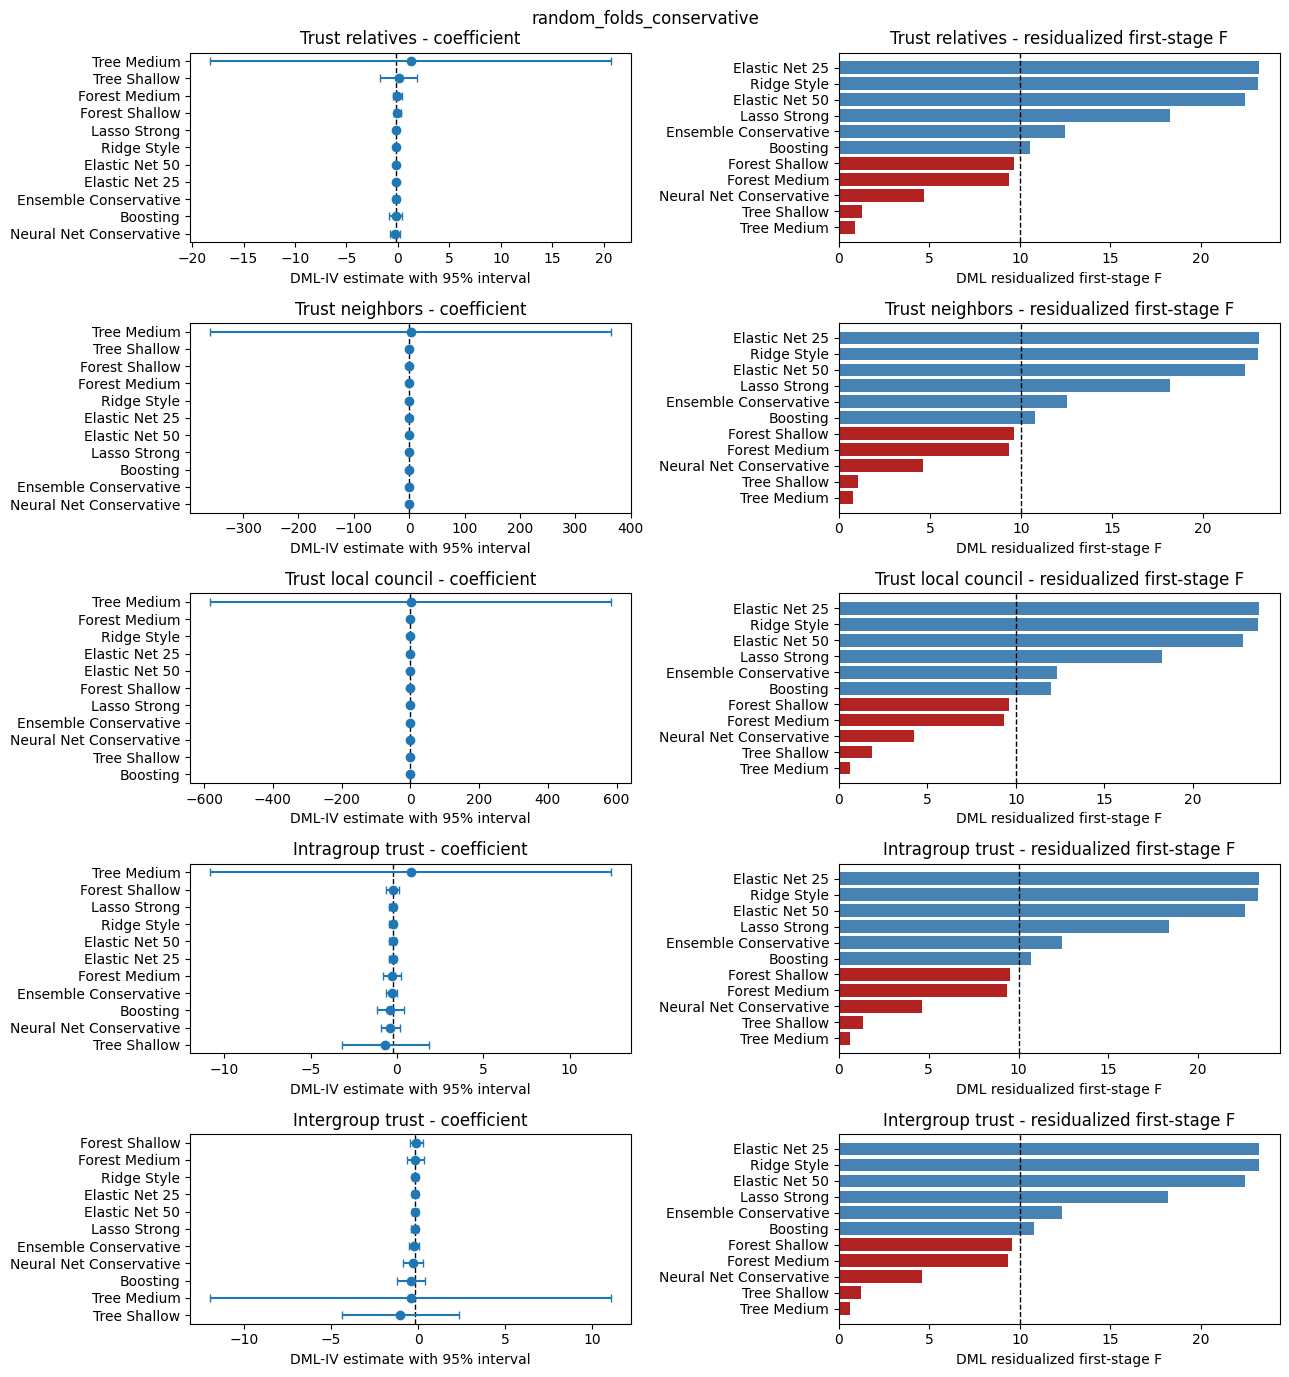

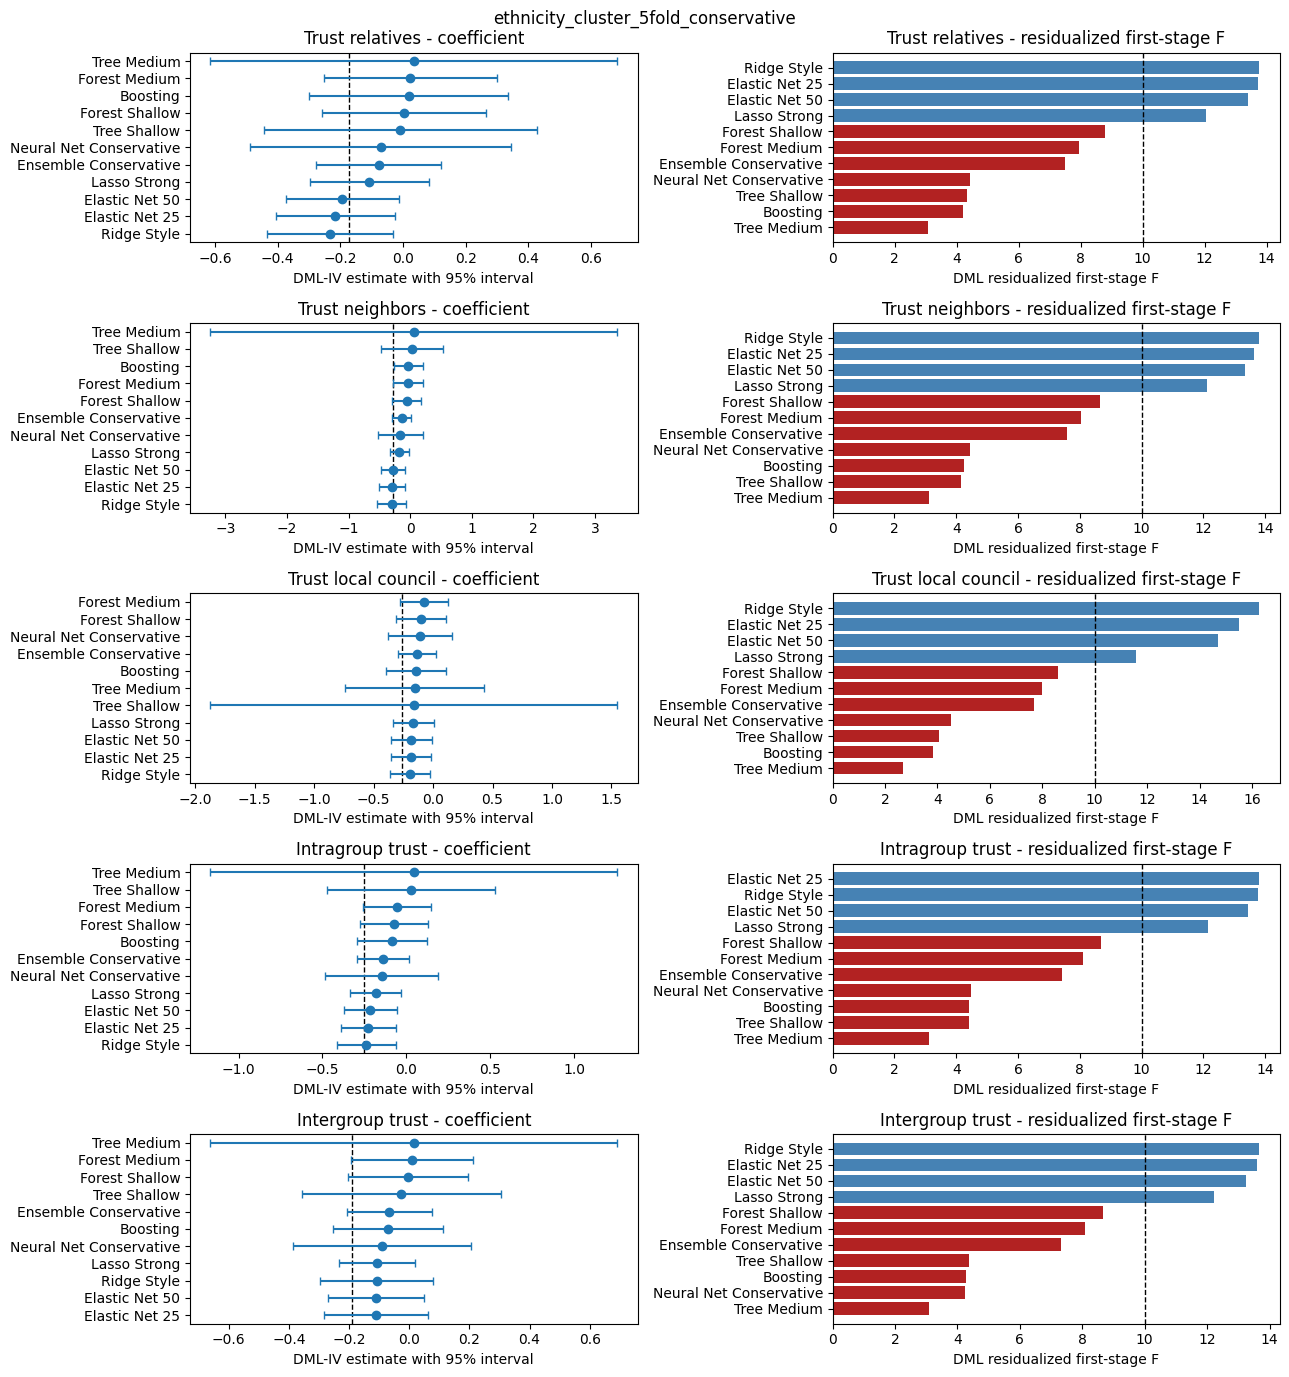

In [52]:
plot_data = table6_iv_sensitivity_results_long.copy()
if plot_data.empty:
    raise ValueError("Run or load Table 6 IV sensitivity results before plotting.")

for design_name in plot_data["crossfit_design"].unique():
    design_data = plot_data.loc[plot_data["crossfit_design"] == design_name].copy()
    fig, axes = plt.subplots(len(outcomes), 2, figsize=(13, 2.8 * len(outcomes)), sharex=False)
    if len(outcomes) == 1:
        axes = np.array([axes])
    for row, outcome in enumerate(outcomes):
        sub = design_data.loc[design_data["outcome"] == outcome].sort_values("theta")
        axes[row, 0].axvline(original_iv[outcome], color="black", linestyle="--", linewidth=1, label="Original IV")
        axes[row, 0].errorbar(sub["theta"], sub["learner"], xerr=1.96 * sub["se"], fmt="o", capsize=3)
        axes[row, 0].set_title(f"{outcome_labels[outcome]} - coefficient")
        axes[row, 0].set_xlabel("DML-IV estimate with 95% interval")
        fs = sub.sort_values("first_stage_F")
        colors = np.where(fs["first_stage_F"] < 10, "firebrick", "steelblue")
        axes[row, 1].barh(fs["learner"], fs["first_stage_F"], color=colors)
        axes[row, 1].axvline(10, color="black", linestyle="--", linewidth=1)
        axes[row, 1].set_title(f"{outcome_labels[outcome]} - residualized first-stage F")
        axes[row, 1].set_xlabel("DML residualized first-stage F")
    fig.suptitle(design_name)
    plt.tight_layout()
    plt.show()